In [1]:
from astropy.io import fits
import astropy.table as table
from astropy.table import vstack, hstack
from astropy.table import QTable, Column, MaskedColumn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap

import astropy.units as u
import astropy.constants as c
import ternary
from matplotlib.lines import Line2D

import glob
# from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
from astropy.coordinates import Angle
from astropy.coordinates import search_around_sky
import astropy.coordinates as coord


import concurrent.futures
import time
import random
import os

# import seaborn as sns
import umap
from sklearn.model_selection import train_test_split,GridSearchCV
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
import sklearn.cluster as cluster
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

from umap import UMAP
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import umap
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

from sklearn.cluster import KMeans, HDBSCAN
from sklearn.mixture import GaussianMixture


## Setup

In [2]:
catalog_home_dir = '/lustre/aoc/observers/nm-16041/antonio/USSCataloging/catalogs/'
catalog_reduced_dir = '/lustre/aoc/observers/nm-16041/antonio/USSCataloging/reduced_catalogs/'
catalog_fermi_nway = '/lustre/aoc/observers/nm-16041/antonio/USSCataloging/reduced_catalogs/mag_prior_all_nway_matches/'

In [3]:
from astropy.table import Table
t = Table.read(catalog_fermi_nway+'14/'+'all_top_tables_stacked_probabilites.fits')
missing = (t['FERMI_Source_Name'] == '') | (t['FERMI_Source_Name'].mask if hasattr(t['FERMI_Source_Name'], 'mask') else False)
print(f'{missing.sum()} / {len(t)} rows missing a Fermi source name')

0 / 4170 rows missing a Fermi source name


In [4]:
names = t['FERMI_Source_Name']
print(f'{len(set(names))} unique source names vs {len(t)//2} expected (rows/2)')

2042 unique source names vs 2085 expected (rows/2)


In [5]:
# import psrqpy
query = psrqpy.QueryATNF(loadfromdb='/lustre/aoc/observers/nm-16041/antonio/USSCataloging/catalogs/psrcat_tar/psrcat.db')
# query.derived_flux()
# pulsar_table = query.table

# pulsar_table.write("local_atnf.fits", format="fits")



NameError: name 'psrqpy' is not defined

In [ ]:
pulsar_table = query.table

# Loop over the columns in your table using psrqpy's actual fields mapping
for col_name in pulsar_table.colnames:
    col = pulsar_table[col_name]
    
    # query.fields maps the short parameter name to its structural metadata
    if col_name in query.fields:
        # Extracts short description text from the field configuration
        desc_text = query.fields[col_name].get('doc', 'No description available')
    else:
        desc_text = "Derived or metadata column"
        
    print(f"{col_name:15} | Type: {str(col.dtype):8} | {desc_text}")


In [5]:
# all associated sources no probability stack
# all unassociated sources stacked as is
# all associated sources with the probabilites of xgbosst 
# the top matches from nway for the unassociated sources
# the worst matches from nway for the unassociated sources

# full catalogs just split not reduced (with their additional sources appeneded to them (atleast for the unassociated version)
# full_unassociated_sources = 

# reduced catalogs
antf_psrcat_path              =catalog_home_dir + 'local_atnf.fits'
associated_source_path        =catalog_reduced_dir+ '14yr_associated_ellipses_all_srcs_gaia_wise.fits'
unassociated_source_path      =catalog_reduced_dir+ 'mag_prior_all_nway_matches/14/all_top_tables_stacked_probabilites.fits'
associated_source_sample_test_path_3_labels =catalog_reduced_dir+'pulsar_sample_14yr_associated_ellipses_all_srcs_gaia_wise' + '_3_labels' + 'xgmodeled.fits'
associated_source_sample_test_path_4_labels =catalog_reduced_dir+'pulsar_sample_14yr_associated_ellipses_all_srcs_gaia_wise' + '_4_labels' + 'xgmodeled.fits'
top_matches_unassociated_path =catalog_reduced_dir+ 'mag_prior_all_nway_matches/'+ '14/'+'top_stacked_matches_xgmodeled.fits'
worst_match_unassociated_path =catalog_reduced_dir+ 'mag_prior_all_nway_matches/'+ '14/'+'worst_stacked_matches_xgmodeled.fits'


antf_psrcat_table                = QTable.read(antf_psrcat_path)
associated_source_table          = QTable.read(associated_source_path, format='fits')
unassociated_source_table        = QTable.read(unassociated_source_path, format='fits')

associated_source_test_table_3     = QTable.read(associated_source_sample_test_path_3_labels, format='fits')
associated_source_test_table_4     = QTable.read(associated_source_sample_test_path_4_labels, format='fits')

top_match_unassociated_sources   = QTable.read(top_matches_unassociated_path, format='fits')
worst_match_unassociated_sources = QTable.read(worst_match_unassociated_path, format='fits')



In [ ]:
len(unassociated_source_table)/2

In [ ]:
len(list(set(unassociated_source_table['prob_has_match'])))

In [ ]:
unassociated_source_table[unassociated_source_table['ncat'] ==1]

In [14]:
len(antf_psrcat_table)

4393

In [15]:
print(antf_psrcat_table.colnames)

['PSRJ', 'PSRJ_REF', 'RAJ', 'RAJ_ERR', 'RAJ_REF', 'DECJ', 'DECJ_ERR', 'DECJ_REF', 'POSEPOCH', 'POSEPOCH_REF', 'PMRA', 'PMRA_ERR', 'PMRA_REF', 'PMDEC', 'PMDEC_ERR', 'PMDEC_REF', 'DM', 'DM_ERR', 'DM_REF', 'F0', 'F0_ERR', 'F0_REF', 'PEPOCH', 'PEPOCH_REF', 'F1', 'F1_ERR', 'F1_REF', 'PX', 'PX_ERR', 'PX_REF', 'S1400', 'S1400_REF', 'DIST_DM', 'DIST_DM_REF', 'DIST_DM1', 'DIST_DM1_REF', 'TYPE', 'ASSOC', 'SURVEY', 'JNAME', 'JNAME_REF', 'NAME', 'NAME_REF', 'RAJD', 'DECJD', 'RAJD_ERR', 'DECJD_ERR', 'POSEPOCH_REF_YEAR', 'DMEPOCH', 'DMEPOCH_REF', 'P0', 'P0_ERR', 'P0_REF', 'P1', 'P1_ERR', 'P1_REF', 'RM', 'RM_ERR', 'RM_REF', 'S400', 'S400_REF', 'S150', 'S150_ERR', 'S150_REF', 'S327', 'S327_ERR', 'S327_REF', 'W50', 'W50_REF', 'W10', 'W10_REF', 'W50_ERR', 'SPINDX', 'SPINDX_ERR', 'SPINDX_REF', 'FRACL', 'FRACL_ERR', 'FRACL_REF', 'FRACV', 'FRACV_ERR', 'FRACV_REF', 'FRACAV', 'FRACAV_ERR', 'FRACAV_REF', 'MAGINC', 'MAGINC_REF', 'IMPANG', 'IMPANG_REF', 'PASWING', 'PASWING_REF', 'F2', 'F2_ERR', 'F2_REF', 'F3', 

In [ ]:
fermi_lat_surveys = glob.glob(catalog_home_dir + 'gll**.fit')
fermi_lat_surveys.sort(reverse=False)
fermi_lat_catalogs = []
for cat in fermi_lat_surveys:
    cat = QTable.read(cat, format='fits')
    fermi_lat_catalogs.append(cat)

In [17]:
_14_year = fermi_lat_catalogs[3][fermi_lat_catalogs[3]['GLAT'] <= 10*u.deg]
_14_year = _14_year[_14_year['GLAT'] >= -10*u.deg]

In [18]:
fermi_lat_catalogs[3]['GLAT']

<Quantity [-42.729538, -53.029457, -35.959175, ..., -64.472755, -74.919624,
           -29.84801 ] deg>

In [19]:
x = np.isin(_14_year['CLASS1'], (b'', b'unk'))
len(_14_year[x])



1277

In [20]:
860 unassoc source outside galatic plane of range of 20 deg
3047 outside gal plane


SyntaxError: invalid syntax (3552049010.py, line 1)

In [6]:
# rename the source labels to overlapping fermi sources 
new_labels = ['Signif_Avg', 'Pivot_Energy', 'Flux1000', 'Energy_Flux100', 'Npred',
'Variability_Index', 'Frac_Variability', 'Signif_Peak', 'Flux_Peak',
'Time_Peak', 'Peak_Interval', 'closest_flux_ratio',
'closest_spx_idx', 'spx_idx_ratio', 'Photon_Index',
'Fermi_Flux_Density', 'WISE_w1mpro', 'WISE_w1snr', 'WISE_w2mpro',
'WISE_w2snr', 'WISE_w3mpro', 'WISE_w3snr', 'WISE_w4mpro', 'WISE_w4snr',
'WISE_W1_W2_color', 'WISE_W2_W3_color', 'WISE_W1_W4_color',
'WISE_W2_W4_color', 'WISE_W3_W4_color', 'FIRST_src1_FINT',
'FIRST_src1_FPEAK', 'VLASS_src1_Ftot', 'VLASS_src1_Fpeak',
'NVSS_src1_S1.4', 'SUMSS_src1_St', 'TGSS_src1_Total_flux',
'TGSS_src1_Peak_flux', 'RACS_low_src1_total_flux',
'SpectrumType']

old_labels = []
# if old label is N/A make a new column and add it to the table other rename the table 


# get the closest matching wise from a wise query and add it 



# apply it to the model 

In [ ]:
x = np.isin(fermi_lat_catalogs[3]['CLASS1'], (b'', b'unk'))
len(fermi_lat_catalogs[3][x])

In [23]:
# for all the unassociated_ellipses PRENWAY MATCH
fermi_list_combined = glob.glob(catalog_reduced_dir + '14_yr/' + 'unassociated_spws_merged_radio_fermi_tables.fits')
hdu_table = fits.open(fermi_list_combined[0],  memmap=False)
# source_name = '4FGL J0041.3-0048'
source_names = [hdu.name for hdu in hdu_table]
source_names = source_names[1:]
ellipses = []
for i in range(len(source_names)):
    ellipse = QTable(hdu_table[source_names[i]].data)
    ellipses.append(ellipse)


KeyboardInterrupt: 

In [ ]:
associated_source_sample_test_path_3_labels =catalog_reduced_dir+'pulsar_sample_14yr_associated_ellipses_all_srcs_gaia_wise' + '_3_labels' + 'xgmodeled.fits'
associated_source_sample_test_path_4_labels =catalog_reduced_dir+'pulsar_sample_14yr_associated_ellipses_all_srcs_gaia_wise' + '_4_labels' + 'xgmodeled.fits'
associated_source_test_table_3     = QTable.read(associated_source_sample_test_path_3_labels, format='fits')
associated_source_test_table_4     = QTable.read(associated_source_sample_test_path_4_labels, format='fits')

In [21]:
associated_source_test_table_3

Signif_Avg,Pivot_Energy,Flux1000,Energy_Flux100,Npred,Variability_Index,Frac_Variability,Signif_Peak,Flux_Peak,Time_Peak,Peak_Interval,closest_flux_ratio,closest_spx_idx,spx_idx_ratio,Photon_Index,Fermi_Flux_Density,WISE_w1mpro,WISE_w1snr,WISE_w2mpro,WISE_w2snr,WISE_w3mpro,WISE_w3snr,WISE_w4mpro,WISE_w4snr,WISE_W1_W2_color,WISE_W2_W3_color,WISE_W1_W4_color,WISE_W2_W4_color,WISE_W3_W4_color,FIRST_src1_FINT,FIRST_src1_FPEAK,VLASS_src1_Ftot,VLASS_src1_Fpeak,NVSS_src1_S1.4,SUMSS_src1_St,TGSS_src1_Total_flux,TGSS_src1_Peak_flux,RACS_low_src1_total_flux,converted_SpectrumType,_3_labels_top_class_pred_idx,_3_labels_top_class_pred,_3_labels_blazar_prob,_3_labels_other_prob,_3_labels_pulsar_prob,Real_Class1_Rebinned
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,bytes6,float32,float32,float32,bytes6
7.549068450927736,7955.568359375,8.203803608664018e-11,1.2797841128855974e-12,47.8927116394043,13.394347190856934,0.0,11.263680458068848,2.451889624666137e-08,444470016.0,31560000.0,0.9332159275438556,-0.4762121585720956,1.0,0.3925318717956542,3.292651482345618e-15,14.54,34.3,14.606,16.5,12.306,-0.9000000000000004,8.609,-0.30000000000000004,-0.06600000000000072,2.3000000000000007,5.930999999999999,5.997,3.696999999999999,62.85400390625,59.52000045776367,43.723,40.803,72.9,88.5,693.0,672.9000244140625,10.506499999999999,0.0,1,other,0.43958098,0.5269448,0.03347423,blazar
6.353090763092041,2652.781005859375,1.6051489026835952e-09,1.0890573165500683e-11,1182.01904296875,15.043244361877413,0.2207566350698471,11.263680458068848,2.451889624666137e-08,444470016.0,31560000.0,0.9299634457715003,-0.2009382608089497,1.0,1.7260982990264893,2.2583845871951974e-13,10.845,30.9,10.484,30.5,7.365,7.7,5.28,11.3,0.36100000000000065,3.1189999999999998,5.565,5.204,2.085,36.58919143676758,30.659999847412113,25.923,20.995,72.9,88.5,693.0,672.9000244140625,10.506499999999999,0.0,1,other,0.06552892,0.76708066,0.16739042,other
12.473578453063965,646.4051513671875,2.1375670677947767e-10,3.0071266657327733e-12,873.6074218749999,25.235515594482422,0.362684428691864,11.263680458068848,2.451889624666137e-08,444470016.0,31560000.0,0.9800400137901306,-0.015723113730581384,1.0,1.511413812637329,1.1637010799425695e-12,17.541,5.699999999999999,17.057,0.1999999999999993,12.498,-0.6000000000000001,8.925,-0.19999999999999996,0.48400000000000176,4.558999999999999,8.616,8.131999999999998,3.5729999999999986,1228.715087890625,1204.18994140625,1214.079,951.634,72.9,88.5,693.0,672.9000244140625,10.506499999999999,0.0,0,blazar,0.82344615,0.16805644,0.008497447,blazar
4.0369648933410645,1639.2293701171875,1.341971256341168e-10,8.349741796413734e-13,180.27215576171875,10.969000816345215,0.0,11.263680458068848,2.451889624666137e-08,444470016.0,31560000.0,0.9299634457715003,-0.2009382608089497,1.0,1.2417795658111572,6.401711707395771e-14,17.314,8.4,16.727,2.0,12.348,1.2,9.001,2.8,0.5869999999999997,4.379,8.313,7.726000000000001,3.3470000000000013,36.58919143676758,30.659999847412113,25.923,20.995,72.9,88.5,693.0,672.9000244140625,10.506499999999999,0.0,1,other,0.17463116,0.70573294,0.11963591,other
25.196992874145508,1028.3458251953125,6.006620201226553e-10,4.269118912547665e-12,1108.88134765625,6.121606349945068,0.0,11.263680458068848,2.451889624666137e-08,444470016.0,31560000.0,1.2122011749243429,0.011083515075140299,1.0,0.9296914339065552,7.132153483253856e-13,15.52,28.9,15.128,17.0,12.146,3.5,8.443,1.0,0.39199999999999946,2.9819999999999993,7.077,6.6850000000000005,3.703000000000001,36.58919143676758,30.659999847412113,25.923,20.995,72.9,88.5,693.0,672.9000244140625,10.506499999999999,1.0,2,pulsar,0.013604432,0.007170143,0.9792254,pulsar
11.064468383789062,1121.1376953125,2.1602861166591936e-10,3.2649215362529088e-12,869

In [22]:
associated_source_table['

SyntaxError: unterminated string literal (detected at line 1) (1192486015.py, line 1)

In [23]:
top_match_unassociated_sources

WISE,Separation_FERMI_WISE,Separation_max,ncat,dist_bayesfactor_uncorrected,dist_bayesfactor,dist_post,p_single,match_flag,prob_has_match,prob_this_match,Source_Name,DataRelease,RA,DEC,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FHL,TEVCAT_FLAG,CLASS1,ASSOC1,ASSOC_PROB_BAY,ASSOC_PROB_LR,Flags,Indexes,catalog_names,pos_err,ID,WISE_DataRelease,WISE_Conf_95_SemiMajor,WISE_Conf_95_SemiMinor,WISE_Conf_95_PosAng,WISE_ROI_num,WISE_Flags,WISE_Indexes,WISE_catalog_names,WISE_designation,WISE_RA,WISE_DEC,WISE_sigra,WISE_sigdec,WISE_sigradec,WISE_glon,WISE_glat,WISE_elon,WISE_elat,WISE_wx,WISE_wy,WISE_cntr,WISE_source_id,WISE_coadd_id,WISE_src,WISE_w1mpro,WISE_w1sigmpro,WISE_w1snr,WISE_w1rchi2,WISE_w2mpro,WISE_w2sigmpro,WISE_w2snr,WISE_w2rchi2,WISE_w3mpro,WISE_w3sigmpro,WISE_w3snr,WISE_w3rchi2,WISE_w4mpro,WISE_w4snr,WISE_w4rchi2,WISE_rchi2,WISE_nb,WISE_na,WISE_w1sat,WISE_w2sat,WISE_w3sat,WISE_w4sat,WISE_satnum,WISE_ra_pm,WISE_dec_pm,WISE_sigra_pm,WISE_sigdec_pm,WISE_sigradec_pm,WISE_pmra,WISE_sigpmra,WISE_pmdec,WISE_sigpmdec,WISE_w1rchi2_pm,WISE_w2rchi2_pm,WISE_w3rchi2_pm,WISE_w4rchi2_pm,WISE_rchi2_pm,WISE_pmcode,WISE_cc_flags,WISE_rel,WISE_ext_flg,WISE_ph_qual,WISE_det_bit,WISE_moon_lev,WISE_w1nm,WISE_w1m,WISE_w2nm,WISE_w2m,WISE_w3nm,WISE_w3m,WISE_w4nm,WISE_w4m,WISE_w1cov,WISE_w2cov,WISE_w3cov,WISE_w4cov,WISE_w1cc_map,WISE_w1cc_map_str,WISE_w2cc_map,WISE_w3cc_map,WISE_w4cc_map,WISE_use_src,WISE_best_use_cntr,WISE_ngrp,WISE_w1flux,WISE_w1sigflux,WISE_w1sky,WISE_w1sigsk,WISE_w1conf,WISE_w2flux,WISE_w2sigflux,WISE_w2sky,WISE_w2sigsk,WISE_w2conf,WISE_w3flux,WISE_w3sigflux,WISE_w3sky,WISE_w3sigsk,WISE_w3conf,WISE_w4flux,WISE_w4sigflux,WISE_w4sky,WISE_w4sigsk,WISE_w4conf,WISE_w1magp,WISE_w1sigp1,WISE_w1sigp2,WISE_w1k,WISE_w1ndf,WISE_w1mlq,WISE_w1mjdmin,WISE_w1mjdmax,WISE_w1mjdmean,WISE_w2magp,WISE_w2sigp1,WISE_w2sigp2,WISE_w2k,WISE_w2ndf,WISE_w2mlq,WISE_w2mjdmin,WISE_w2mjdmax,WISE_w2mjdmean,WISE_w3magp,WISE_w3sigp1,WISE_w3sigp2,WISE_w3k,WISE_w3ndf,WISE_w3mlq,WISE_w3mjdmin,WISE_w3mjdmax,WISE_w3mjdmean,WISE_w4magp,WISE_w4sigp1,WISE_w4sigp2,WISE_w4k,WISE_w4ndf,WISE_w4mlq,WISE_w4mjdmin,WISE_w4mjdmax,WISE_w4mjdmean,WISE_rho12,WISE_rho23,WISE_rho34,WISE_q12,WISE_q23,WISE_w4gflg,WISE_tmass_key,WISE_r_2mass,WISE_pa_2mass,WISE_n_2mass,WISE_j_m_2mass,WISE_j_msig_2mass,WISE_h_m_2mass,WISE_h_msig_2mass,WISE_k_m_2mass,WISE_k_msig_2mass,WISE_x,WISE_y,WISE_z,WISE_spt_ind,WISE_wise_ang_sep,WISE_WISE_flux,WISE_WISE_maj,WISE_radio_flux_name,WISE__catalog_base_name,WISE__ra_key,WISE__dec_key,WISE__maj_key,WISE__flux_key,WISE_pos_err,WISE_w4sigmpro,ASSOC_FGL,WISE_var_flg,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,RACS_low,VLASS,Separation_FERMI_RACS_low,Separation_FERMI_VLASS,Separation_RACS_low_WISE,Separation_RACS_low_VLASS,Separation_WISE_VLASS,bias_RACS_low_spectral_index,bias_RACS_low_FluxRatio,bias_RACS_low_total_flux,bias_VLASS_spectral_index,bias_VLASS_Ftot,bias_VLASS_FluxRatio,SBID,n_gauss,s_code,CompId,IslId,DupFlag,QualFlag,MainSample,RACS_low_src1_DataRelease,RACS_low_src1_RA,RACS_low_src1_DEC,RACS_low_src1_Conf_95_SemiMajor,RACS_low_src1_Conf_95_SemiMinor,RACS_low_src1_Conf_95_PosAng,RACS_low_src1_ROI_num,RACS_low_src1_Flags,RACS_low_src1_Indexes,RACS_low_src1_catalog_names,RACS_low_src1_source_name,RACS_low_src1_Source_ID,RACS_lo

In [24]:
# top_match_unassociated_sources
# associated_source_table['closest_spx_idx']
# associated_source_table['closest_spx_idx']
# # 

In [7]:
grouped_dict_list_4 = {
                     'pulsar': ['psr', 'PSR',  'msp', 'MSP'],
                     'blazar': ['bll', 'BLL',
                               'fsrq', 'FSRQ',
                               ],
                     'non_blazar_galaxy': [
                         'agn', 'AGN',
                         'css', 'CSS',
                         'nlsy1', 'NLSY1', 'rdg', 'RDG',
                         'sey', 'SEY', 'ssrq', 'SSRQ', 'gal', 
                         'GAL', 'sbg', 'SBG',
                         'bcu', 'BCU',
                     ],
                     'other' : ['snr', 'SNR',
                                'spp', 'SPP',
                                'gc', 'GC', 'glc', 'GLC',
                                'mc', 'MC', 'sfr', 'SFR',
                                'pwn', 'PWN',
                                'UNK',
                                'lmb', 'LMB', 'bin', 'BIN', 
                                'hmb', 'HMB', 'nov', 'NOV'
                               ]}
# preshanths version
grouped_dict_list_3 = {
                     'pulsar': ['psr', 'PSR',  'msp', 'MSP'],
                     'blazar': ['bll', 'BLL',
                               'fsrq', 'FSRQ',
                               ],
                     'other' : ['snr', 'SNR',
                                'spp', 'SPP',
                                'gc', 'GC', 'glc', 'GLC',
                                'mc', 'MC', 'sfr', 'SFR',
                                'pwn', 'PWN',
                                'UNK',
                                'lmb', 'LMB', 'bin', 'BIN', 
                                'hmb', 'HMB', 'nov', 'NOV',

                                 'agn', 'AGN',
                                 'css', 'CSS',
                                 'nlsy1', 'NLSY1', 'rdg',
                                 'RDG',
                                 'sey', 'SEY', 'ssrq',
                                'SSRQ', 'gal', 
                                 'GAL', 'sbg', 'SBG',
                                 'bcu', 'BCU',
                               ]}


associated_source_table['CLASS1_rebinned_3_labels'] = [
        next((rebin for rebin, target_cls in grouped_dict_list_3.items() if actual_cls in target_cls), actual_cls)
        for actual_cls in associated_source_table['CLASS1']
    ]

associated_source_table['CLASS1_rebinned_4_labels'] =[
        next((rebin for rebin, target_cls in grouped_dict_list_4.items() if actual_cls in target_cls), actual_cls)
        for actual_cls in associated_source_table['CLASS1']
    ]
valid_values = associated_source_table.copy()
print(f'valid sources spx idx empty reduction: {len(valid_values)}')   
valid_values = valid_values[valid_values['closest_spx_idx'] != np.inf]
valid_values = valid_values[valid_values['closest_flux_ratio'] != np.inf]


valid sources spx idx empty reduction: 4635


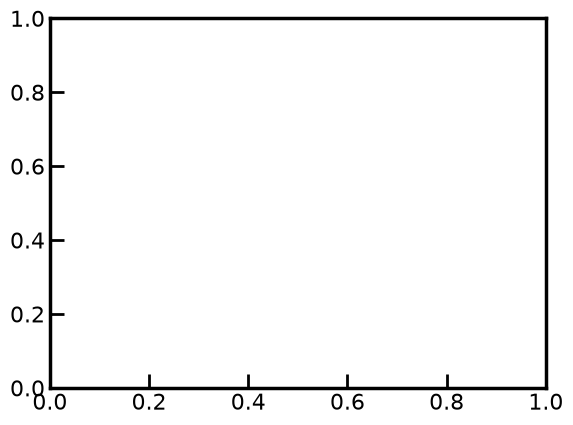

In [8]:
# 1. Setup global presentation parameters
plt.rcParams.update({
    # Text and Font Sizes (Crucial for large screens)
    'font.size': 18,               # Base font size
    'axes.labelsize': 22,          # X and Y label size
    'axes.titlesize': 24,          # Title size
    'xtick.labelsize': 16,         # X tick numbers size
    'ytick.labelsize': 16,         # Y tick numbers size
    'legend.fontsize': 16,         # Legend text size
    
    # Line and Border Thickness
    'axes.linewidth': 2.5,         # Thicker frame box
    'lines.linewidth': 3.0,        # Thicker plot lines
    'lines.markersize': 8,         # Larger data markers
    
    # Tick Configurations (Inward, thick, and mirrored)
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 10,        # Long major ticks
    'xtick.minor.size': 5,         # Visible minor ticks
    'xtick.major.width': 2.0,      # Thick tick marks
    'xtick.minor.width': 1.5,
    'ytick.major.size': 10,
    'ytick.minor.size': 5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
})

# 2. Define a clean, high-contrast palette
# Avoid default matplotlib colors. Use bold, distinct hex codes.
ASTRO_COLORS = [
    '#005AB5',  # Deep Space Blue
    '#DC3220',  # Nebula Red / Orange
    '#009E73',  # Supernova Green
    '#785EF0',  # Ultraviolet Purple
    '#FFB000'   # Solar Yellow
]
plt.gca().set_prop_cycle(color=ASTRO_COLORS)


## Methodology

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import ternary

def ternary_cluster(unassociated_data, second_table=None, figname=None, prob_cert_limit=0.5):
    # Setup plotting environments and tables to process
    my_colors = ['red', 'green', 'blue', 'gray']
    custom_cmap = ListedColormap(my_colors)
    
    # Check if we are doing a single plot or side-by-side subplots
    if second_table is not None:
        fig, axs = plt.subplots(1, 2, figsize=(16, 6)) 
        tables_to_process = [
            {"data": unassociated_data, "ax": axs[0], "title_suffix": f"{figname[0]}"},
            {"data": second_table, "ax": axs[1], "title_suffix": f"{figname[1]}"}
        ]
    else:
        fig, ax = plt.subplots(1, 1, figsize=(9, 8))
        tables_to_process = [
            {"data": unassociated_data, "ax": ax, "title_suffix": ""}
        ]

    # Process each table using a loop to eliminate redundant code
    for idx, item in enumerate(tables_to_process):
        data = item["data"]
        ax_obj = item["ax"]
        
        # Extract and convert probabilities
        try:
            blazar_prob = np.asarray(data['labels_3_blazar_prob'], dtype=float)
            other_prob = np.asarray(data['labels_3_other_prob'], dtype=float)
            pulsar_prob = np.asarray(data['labels_3_pulsar_prob'], dtype=float)
        except:
            blazar_prob = np.asarray(data['_3_labels_blazar_prob'], dtype=float)
            other_prob = np.asarray(data['_3_labels_other_prob'], dtype=float)
            pulsar_prob = np.asarray(data['_3_labels_pulsar_prob'], dtype=float)
            
        points = np.column_stack((blazar_prob, other_prob, pulsar_prob))
        
        # Initialize ternary axis wrapping the specific matplotlib axis
        tax = ternary.TernaryAxesSubplot(ax=ax_obj, scale=1.0)
        
        # Classify points and collect counts
        color_idx = []
        blazar_size = 0
        pulsar_size = 0
        other_size = 0
        no_match_size = 0
        
        for point in points:
            if point[0] >= prob_cert_limit:
                color_idx.append(0)
                blazar_size += 1
            elif point[1] >= prob_cert_limit:
                color_idx.append(0.25)
                other_size += 1
            elif point[2] >= prob_cert_limit:
                color_idx.append(0.5)
                pulsar_size += 1
            else:
                color_idx.append(0.75)
                no_match_size += 1
        
        # Configure ternary appearance
        tax.boundary(linewidth=2.0)
        tax.gridlines(multiple=0.1, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
        tax.scatter(points, marker="o", c=color_idx, cmap=custom_cmap, alpha=0.5, s=25)
        
        # Labels and corners
        tax.left_corner_label("Pulsar", fontsize=14, offset=0.10)
        tax.right_corner_label("Blazar", fontsize=14, offset=0.10)
        tax.top_corner_label("Other", fontsize=14, offset=0.17)
        
        tax.ticks(axis="lbr", multiple=0.1, linewidth=1, tick_formats="%.1f")
        tax.clear_matplotlib_ticks()
        tax.get_axes().axis("off")
        
        # Titles
        # tax.set_title(
        #     # rf"XGBoost 3-Class Probabilities{item['title_suffix']}{'\n'}"
        #     # rf"Sources $\geq$ {prob_cert_limit} colorized; otherwise grayed-out",
        #     # fontsize=13, pad=40
        # )
        
        # Custom legends per subplot
        legend_handles = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_cmap(0), label=f'Blazars {blazar_size}', alpha=0.5, markersize=12),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_cmap(1), label=f'Other {other_size}', alpha=0.5, markersize=12),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_cmap(2), label=f'Pulsars {pulsar_size}', alpha=0.5, markersize=12),
            Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_cmap(3), label=f'No Match {no_match_size}', alpha=0.5, markersize=12)
        ]
        tax.legend(handles=legend_handles, loc="upper right", fontsize=9)

    # FIX: Explicitly add massive spacing buffer between the subplots if doing side-by-side
    if second_table is not None:
        fig.subplots_adjust(wspace=0.25)
    else:
        fig.subplots_adjust(wspace=0.0)

    # FIX: Shifted completely outside loop and reintroduced bbox_inches="tight" 
    if figname is not None:
        figname = 'terany_plot' + figname[0]
        fig.savefig(figname, dpi=300, bbox_inches="tight")
    else:
        plt.show()
        
    return fig


In [18]:
# def ternary_cluster(unassociated_data, second_table = None, figname=None, prob_cert_limit=0.5):
    
#     blazar_prob = np.asarray(unassociated_data['labels_3_blazar_prob'], dtype=float)
#     other_prob = np.asarray(unassociated_data['labels_3_other_prob'], dtype=float)
#     pulsar_prob = np.asarray(unassociated_data['labels_3_pulsar_prob'], dtype=float)

#     my_colors = ['red', 'green', 'blue', 'gray']
#     custom_cmap = ListedColormap(my_colors)
#     color_idx = []
#     if second_table not None:
#         blazar_prob_2 = np.asarray(second_table['labels_3_blazar_prob'], dtype=float)
#         other_prob_2 = np.asarray(second_table['labels_3_other_prob'], dtype=float)
#         pulsar_prob_2 = np.asarray(second_table['labels_3_pulsar_prob'], dtype=float)
#         fig, axs =  plt.subplots(1, 2, figsize =(9,8))

#         tax1 = ternary.TernaryAxesSubplot(ax=axs[0], scale=1.0)

#     else:
#         probability_sum = blazar_prob + other_prob + pulsar_prob
#         points = np.column_stack((blazar_prob, other_prob, pulsar_prob))
#         fig, tax = ternary.figure(scale=1.0, permutation="012")
#         fig.set_size_inches(9, 8)
    
#         blazar_size = 0
#         pulsar_size = 0
#         other_size = 0
#         no_match_size = 0
        
#         for point in points:
#             if point[0] >= prob_cert_limit:
#                 color_idx.append(0)
#                 blazar_size+=1
#             elif point[1] >=prob_cert_limit:
#                 color_idx.append(0.25)
#                 other_size+=1
#             elif point[2] >=prob_cert_limit:
#                 color_idx.append(0.5)
#                 pulsar_size+=1
#             else:
#                 color_idx.append(0.75)
#                 no_match_size+=1
    
#         tax.boundary(linewidth=2.0)
#         tax.gridlines(multiple=0.1,color="gray",linestyle="--",alpha=0.5,linewidth=0.8)
#         tax.scatter(points, marker="o", c=color_idx, cmap = custom_cmap, alpha=0.5, s=25, label="Unassociated sources")
#         tax.left_corner_label("Pulsar", fontsize=16, offset=0.10)
#         tax.right_corner_label("Blazar", fontsize=16, offset=0.10)
#         tax.top_corner_label("Other", fontsize=16, offset=0.17)
    
#         tax.ticks(axis="lbr", multiple=0.1, linewidth=1, tick_formats="%.1f")
#         tax.clear_matplotlib_ticks()
#         tax.get_axes().axis("off")
    
#         tax.set_title(
#             rf"XGBoost 3-Class Probabilities{'\n'}Unassociated Sources that have a XGBoost Probability $\geq$ {prob_cert_limit}{'\n'}otherwise grayed-out",
#             fontsize=16, pad =40)
#         plt.tight_layout()
    
        
#         legend_handles = [
#             Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_cmap(0), label=f'Blazars {blazar_size}', alpha =0.5, markersize=15),
#             Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_cmap(1), label=f'Other {other_size}',  alpha =0.5, markersize=15),
#             Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_cmap(2), label=f'Pulsars {pulsar_size}', alpha =0.5, markersize=15),
#             Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_cmap(3), label=f'No Match {no_match_size}', alpha =0.5, markersize=15)
    
#         ]
#         tax.legend(handles=legend_handles,  loc="upper right", fontsize=11)
    
#         # tax._redraw_labels()
    
#         if figname is not None:
#             fig.savefig(figname, dpi=300, bbox_inches="tight")
#         else:
#             plt.show()
    
#         return fig, tax

# # generate the triangle cluster plot 
# ternary_cluster(
# top_match_unassociated_sources,
# )


In [25]:
top_match_unassociated_sources[top_match_unassociated_sources['ncat'] > 2]

WISE,Separation_FERMI_WISE,Separation_max,ncat,dist_bayesfactor_uncorrected,dist_bayesfactor,dist_post,p_single,match_flag,prob_has_match,prob_this_match,Source_Name,DataRelease,RA,DEC,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FHL,TEVCAT_FLAG,CLASS1,ASSOC1,ASSOC_PROB_BAY,ASSOC_PROB_LR,Flags,Indexes,catalog_names,pos_err,ID,WISE_DataRelease,WISE_Conf_95_SemiMajor,WISE_Conf_95_SemiMinor,WISE_Conf_95_PosAng,WISE_ROI_num,WISE_Flags,WISE_Indexes,WISE_catalog_names,WISE_designation,WISE_RA,WISE_DEC,WISE_sigra,WISE_sigdec,WISE_sigradec,WISE_glon,WISE_glat,WISE_elon,WISE_elat,WISE_wx,WISE_wy,WISE_cntr,WISE_source_id,WISE_coadd_id,WISE_src,WISE_w1mpro,WISE_w1sigmpro,WISE_w1snr,WISE_w1rchi2,WISE_w2mpro,WISE_w2sigmpro,WISE_w2snr,WISE_w2rchi2,WISE_w3mpro,WISE_w3sigmpro,WISE_w3snr,WISE_w3rchi2,WISE_w4mpro,WISE_w4snr,WISE_w4rchi2,WISE_rchi2,WISE_nb,WISE_na,WISE_w1sat,WISE_w2sat,WISE_w3sat,WISE_w4sat,WISE_satnum,WISE_ra_pm,WISE_dec_pm,WISE_sigra_pm,WISE_sigdec_pm,WISE_sigradec_pm,WISE_pmra,WISE_sigpmra,WISE_pmdec,WISE_sigpmdec,WISE_w1rchi2_pm,WISE_w2rchi2_pm,WISE_w3rchi2_pm,WISE_w4rchi2_pm,WISE_rchi2_pm,WISE_pmcode,WISE_cc_flags,WISE_rel,WISE_ext_flg,WISE_ph_qual,WISE_det_bit,WISE_moon_lev,WISE_w1nm,WISE_w1m,WISE_w2nm,WISE_w2m,WISE_w3nm,WISE_w3m,WISE_w4nm,WISE_w4m,WISE_w1cov,WISE_w2cov,WISE_w3cov,WISE_w4cov,WISE_w1cc_map,WISE_w1cc_map_str,WISE_w2cc_map,WISE_w3cc_map,WISE_w4cc_map,WISE_use_src,WISE_best_use_cntr,WISE_ngrp,WISE_w1flux,WISE_w1sigflux,WISE_w1sky,WISE_w1sigsk,WISE_w1conf,WISE_w2flux,WISE_w2sigflux,WISE_w2sky,WISE_w2sigsk,WISE_w2conf,WISE_w3flux,WISE_w3sigflux,WISE_w3sky,WISE_w3sigsk,WISE_w3conf,WISE_w4flux,WISE_w4sigflux,WISE_w4sky,WISE_w4sigsk,WISE_w4conf,WISE_w1magp,WISE_w1sigp1,WISE_w1sigp2,WISE_w1k,WISE_w1ndf,WISE_w1mlq,WISE_w1mjdmin,WISE_w1mjdmax,WISE_w1mjdmean,WISE_w2magp,WISE_w2sigp1,WISE_w2sigp2,WISE_w2k,WISE_w2ndf,WISE_w2mlq,WISE_w2mjdmin,WISE_w2mjdmax,WISE_w2mjdmean,WISE_w3magp,WISE_w3sigp1,WISE_w3sigp2,WISE_w3k,WISE_w3ndf,WISE_w3mlq,WISE_w3mjdmin,WISE_w3mjdmax,WISE_w3mjdmean,WISE_w4magp,WISE_w4sigp1,WISE_w4sigp2,WISE_w4k,WISE_w4ndf,WISE_w4mlq,WISE_w4mjdmin,WISE_w4mjdmax,WISE_w4mjdmean,WISE_rho12,WISE_rho23,WISE_rho34,WISE_q12,WISE_q23,WISE_w4gflg,WISE_tmass_key,WISE_r_2mass,WISE_pa_2mass,WISE_n_2mass,WISE_j_m_2mass,WISE_j_msig_2mass,WISE_h_m_2mass,WISE_h_msig_2mass,WISE_k_m_2mass,WISE_k_msig_2mass,WISE_x,WISE_y,WISE_z,WISE_spt_ind,WISE_wise_ang_sep,WISE_WISE_flux,WISE_WISE_maj,WISE_radio_flux_name,WISE__catalog_base_name,WISE__ra_key,WISE__dec_key,WISE__maj_key,WISE__flux_key,WISE_pos_err,WISE_w4sigmpro,ASSOC_FGL,WISE_var_flg,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,RACS_low,VLASS,Separation_FERMI_RACS_low,Separation_FERMI_VLASS,Separation_RACS_low_WISE,Separation_RACS_low_VLASS,Separation_WISE_VLASS,bias_RACS_low_spectral_index,bias_RACS_low_FluxRatio,bias_RACS_low_total_flux,bias_VLASS_spectral_index,bias_VLASS_Ftot,bias_VLASS_FluxRatio,SBID,n_gauss,s_code,CompId,IslId,DupFlag,QualFlag,MainSample,RACS_low_src1_DataRelease,RACS_low_src1_RA,RACS_low_src1_DEC,RACS_low_src1_Conf_95_SemiMajor,RACS_low_src1_Conf_95_SemiMinor,RACS_low_src1_Conf_95_PosAng,RACS_low_src1_ROI_num,RACS_low_src1_Flags,RACS_low_src1_Indexes,RACS_low_src1_catalog_names,RACS_low_src1_source_name,RACS_low_src1_Source_ID,RACS_lo

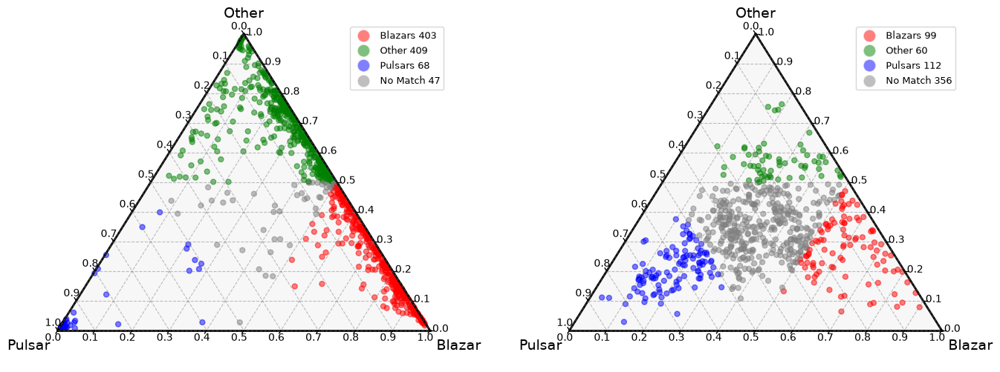

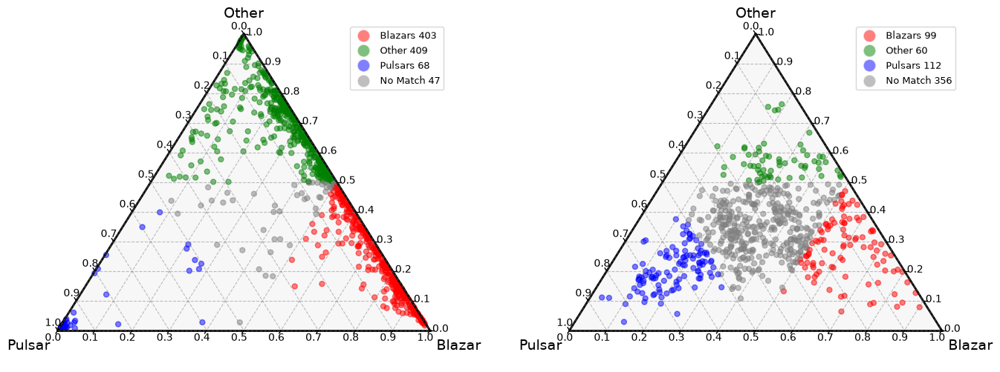

In [26]:
# generate the triangle cluster plot 
# ternary_cluster(
#   associated_source_test_table_3, top_match_unassociated_sources, prob_cert_limit=0.5, figname=['associated', 'unassociated']
# )

ternary_cluster(associated_source_test_table_3, top_match_unassociated_sources[top_match_unassociated_sources['ncat'] > 2],  figname=['associated', 'unassociated'] , prob_cert_limit=0.5)

['agn', 'bcu', 'bin', 'bll', 'css', 'fsrq', 'gal', 'gc', 'glc', 'hmb', 'lmb', 'msp', 'nlsy1', 'nov', 'psr', 'pwn', 'rdg', 'sbg', 'sey', 'sfr', 'snr', 'spp', 'ssrq', 'unk']
1623
1623
1489
1490
820
820
179
179
141
141
132
132
53
53
44
44
41
41
22
22
11
11
10
10
9
9
8
8
8
8
8
8
8
8
6
6
6
6
6
6
4
4
3
3
2
2
1
1


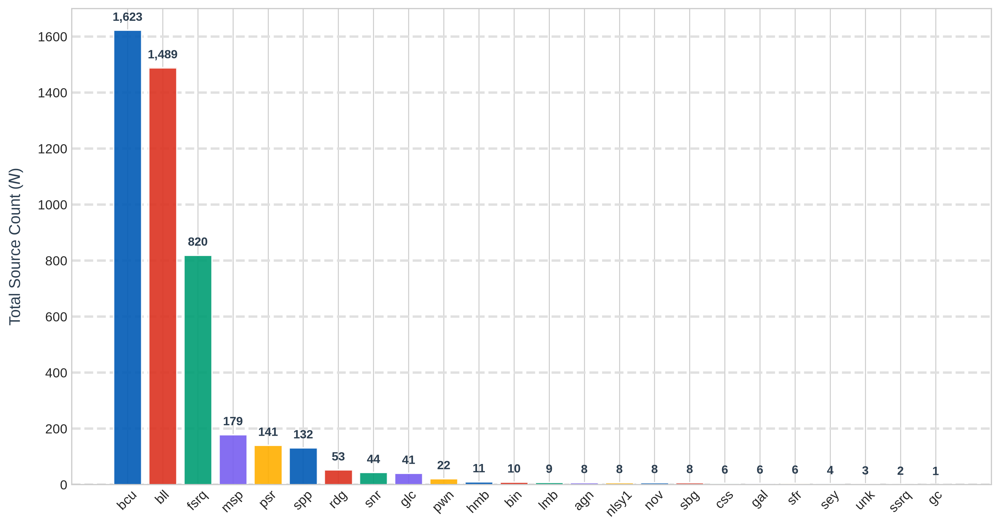

In [19]:
# % how we classify associated and unassociated in the rebin bar chart - PLT ASSOC
# # 1. Access the column data safely

# # 2. Extract valid strings only, ignoring masked/null rows and stripping whitespaces
# # We check if 'c' is a string and strip whitespace because Fermi catalogs often have trailing spaces (e.g., 'bll  ')
class_column  = [label.lower() for label in list(set(associated_source_table['CLASS1']))]

valid_values['Class1_lowered'] =  [label.lower() for label in valid_values['CLASS1']]
associated_source_table['Class1_lowered'] =  [label.lower() for label in associated_source_table['CLASS1']]

valid_classes = [
    str(c).strip() for c in class_column 
    if c is not np.ma.masked and str(c).strip() != '' and str(c).strip() != 'None'
]
unique_classes = sorted(list(set(valid_classes)))
bar_labels = unique_classes
print(bar_labels)
# # Initialize historical tracking structures
# temp_prev_counts = {label: 0 for label in bar_labels}
# hist_totals = {label: 0 for label in bar_labels}
# ==============================================================================
# 1. COMPUTE SINGLE SNAPSHOT COUNTS FOR YEAR 14 (INDEX 4)
# ==============================================================================

# Step A: Clean and extract string representation of classes
raw_classes = [str(c).strip() for c in valid_values['Class1_lowered'] if c is not np.ma.masked]
raw_classes_total = [str(c).strip() for c in associated_source_table['Class1_lowered'] if c is not np.ma.masked]

# Step B: Compute counts for each specific subclass
class_counts = {}
class_counts_full_table = {}
for label in bar_labels:
    class_counts[label] = raw_classes.count(label)
    class_counts_full_table[label] = raw_classes_total.count(label)


# reorder to be the highest first and lower
sorted_pairs = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
bar_labels = [label[0] for label in sorted_pairs]

# ==============================================================================
# 2. PLOT THE RESULTS (ENHANCED ASTRO DESIGN)
# ==============================================================================
# Use a clean, modern aesthetic baseline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=300)
for idx, label in enumerate(bar_labels):
    # Loop smoothly over  ASTRO_COLORS array using modulo math
    ''' REMOVE THE FIRST BAR AND SET THE BOTTOME OF THE SEOCND TO ZERO IF I JUST WANT FULL VALUES LABELS!'''
    bar_height = class_counts[label]
    bar_height_full = class_counts_full_table[label]
    bar_color = ASTRO_COLORS[idx % len(ASTRO_COLORS)]
    hist_cutoff = bar_height_full - bar_height

    print(bar_height)
    print(bar_height_full)


    
    rect = ax.bar(label, height=bar_height, bottom=0, 
                  color=bar_color, edgecolor='white', linewidth=1.2, alpha=0.9)
    
    rect = ax.bar(label, height=hist_cutoff, bottom=bar_height, 
                  color=bar_color, edgecolor='white', linewidth=1.2, alpha=0.7)
 
    # --- CLEAN DATA LABELS ---
    # Place text directly ABOVE the bar for a modern, uncluttered look
    if bar_height > 0:
        ax.text(label, bar_height + (max(class_counts.values()) * 0.015), 
                f"{bar_height:,}", # Formatted with commas for readability
                ha='center', va='bottom', 
                color='#2C3E50', fontsize=10, fontweight='semibold')

# ==============================================================================
# ASTRONOMICAL STYLING & LAYOUT REFINEMENTS
# ==============================================================================
# Format grid to be light and subtle behind the bars
ax.grid(True, axis='y', linestyle='--', linewidth=2, color='#E0E0E0', zorder=0)
ax.set_axisbelow(True) # Pushes grid lines behind the bars

# Remove top and right box borders (Spines) for a high-end minimalist feel
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)
# ax.spines['left'].set_color('#BDC3C7')
# ax.spines['bottom'].set_color('#BDC3C7')
# Refine labels and axis ticks
ax.tick_params(axis='x', which='major', labelsize=11, rotation=45, color='#BDC3C7') 
ax.tick_params(axis='y', which='major', labelsize=11, color='#BDC3C7')
# Labeling using a clear hierarchy
ax.set_ylabel("Total Source Count ($N$)", labelpad=12, fontsize=13, fontweight='medium', color='#2C3E50')
ax.set_ylim(0, 1700)
# ax.set_title("Fermi-LAT CLASS1 Distribution (14-Yr Catalog) Associated Sources", 
             # pad=25, fontsize=15, fontweight='bold', color='#2C3E50', loc='left')

plt.savefig('expanded_dist_classes_assoc14yr.png', dpi=300)
plt.tight_layout()
plt.show()



['blazar', 'other', 'pulsar']
2309
2310
2005
2005
320
320


findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.


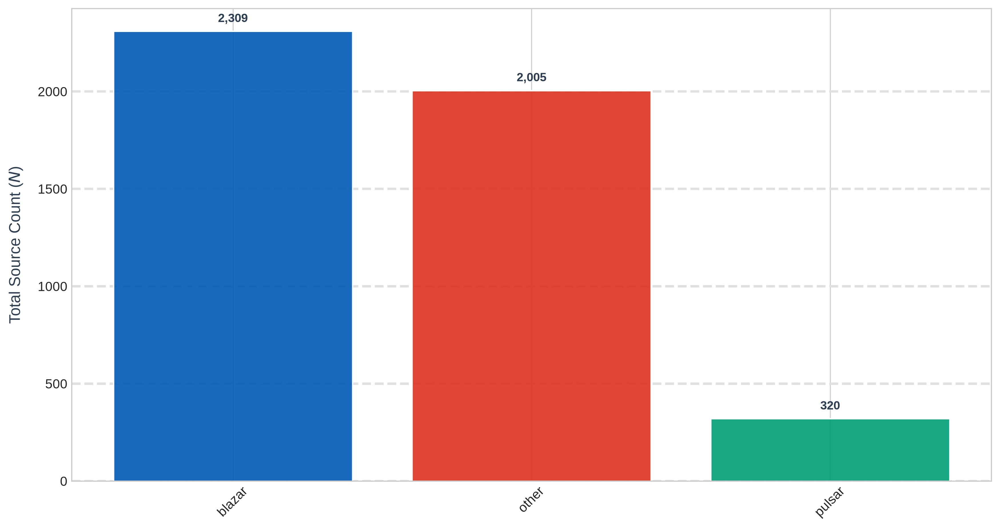

In [13]:
# % how we classify associated and unassociated in the rebin bar chart - PLT ASSOC
# # 1. Access the column data safely

# # 2. Extract valid strings only, ignoring masked/null rows and stripping whitespaces
# # We check if 'c' is a string and strip whitespace because Fermi catalogs often have trailing spaces (e.g., 'bll  ')
class_column = list(set(associated_source_table['CLASS1_rebinned_3_labels']))
valid_classes = [
    str(c).strip() for c in class_column 
    if c is not np.ma.masked and str(c).strip() != '' and str(c).strip() != 'None'
]
unique_classes = sorted(list(set(valid_classes)))
bar_labels = unique_classes
print(bar_labels)
# # Initialize historical tracking structures
# temp_prev_counts = {label: 0 for label in bar_labels}
# hist_totals = {label: 0 for label in bar_labels}
# ==============================================================================
# 1. COMPUTE SINGLE SNAPSHOT COUNTS FOR YEAR 14 (INDEX 4)
# ==============================================================================

# Step A: Clean and extract string representation of classes
raw_classes = [str(c).strip() for c in valid_values['CLASS1_rebinned_3_labels'] if c is not np.ma.masked]
raw_classes_total = [str(c).strip() for c in associated_source_table['CLASS1_rebinned_3_labels'] if c is not np.ma.masked]

# Step B: Compute counts for each specific subclass
class_counts = {}
class_counts_full_table = {}
for label in bar_labels:
    class_counts[label] = raw_classes.count(label)
    class_counts_full_table[label] = raw_classes_total.count(label)

# ==============================================================================
# 2. PLOT THE RESULTS (ENHANCED ASTRO DESIGN)
# ==============================================================================
# Use a clean, modern aesthetic baseline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=300)
for idx, label in enumerate(bar_labels):
    # Loop smoothly over  ASTRO_COLORS array using modulo math
    ''' REMOVE THE FIRST BAR AND SET THE BOTTOME OF THE SEOCND TO ZERO IF I JUST WANT FULL VALUES LABELS!'''
    bar_height = class_counts[label]
    bar_height_full = class_counts_full_table[label]
    bar_color = ASTRO_COLORS[idx % len(ASTRO_COLORS)]
    hist_cutoff = bar_height_full - bar_height

    print(bar_height)
    print(bar_height_full)


    
    rect = ax.bar(label, height=bar_height, bottom=0, 
                  color=bar_color, edgecolor='white', linewidth=1.2, alpha=0.9)
    
    rect = ax.bar(label, height=hist_cutoff, bottom=bar_height, 
                  color=bar_color, edgecolor='white', linewidth=1.2, alpha=0.7)
 
    # --- CLEAN DATA LABELS ---
    # Place text directly ABOVE the bar for a modern, uncluttered look
    if bar_height > 0:
        ax.text(label, bar_height + (max(class_counts.values()) * 0.015), 
                f"{bar_height:,}", # Formatted with commas for readability
                ha='center', va='bottom', 
                color='#2C3E50', fontsize=10, fontweight='semibold')

# ==============================================================================
# ASTRONOMICAL STYLING & LAYOUT REFINEMENTS
# ==============================================================================
# Format grid to be light and subtle behind the bars
ax.grid(True, axis='y', linestyle='--', linewidth=2, color='#E0E0E0', zorder=0)
ax.set_axisbelow(True) # Pushes grid lines behind the bars

# Remove top and right box borders (Spines) for a high-end minimalist feel
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)
# ax.spines['left'].set_color('#BDC3C7')
# ax.spines['bottom'].set_color('#BDC3C7')
# Refine labels and axis ticks
ax.tick_params(axis='x', which='major', labelsize=11, rotation=45, color='#BDC3C7') 
ax.tick_params(axis='y', which='major', labelsize=11, color='#BDC3C7')
# Labeling using a clear hierarchy
ax.set_ylabel("Total Source Count ($N$)", labelpad=12, fontsize=13, fontweight='medium', color='#2C3E50')
# ax.set_title("Fermi-LAT CLASS1 Distribution (14-Yr Catalog) Associated Sources", 
#              pad=25, fontsize=15, fontweight='bold', color='#2C3E50', loc='left')

plt.savefig('dist_classes_assoc14yr.png', dpi=300)
plt.tight_layout()
plt.show()



['blazar', 'other', 'pulsar']


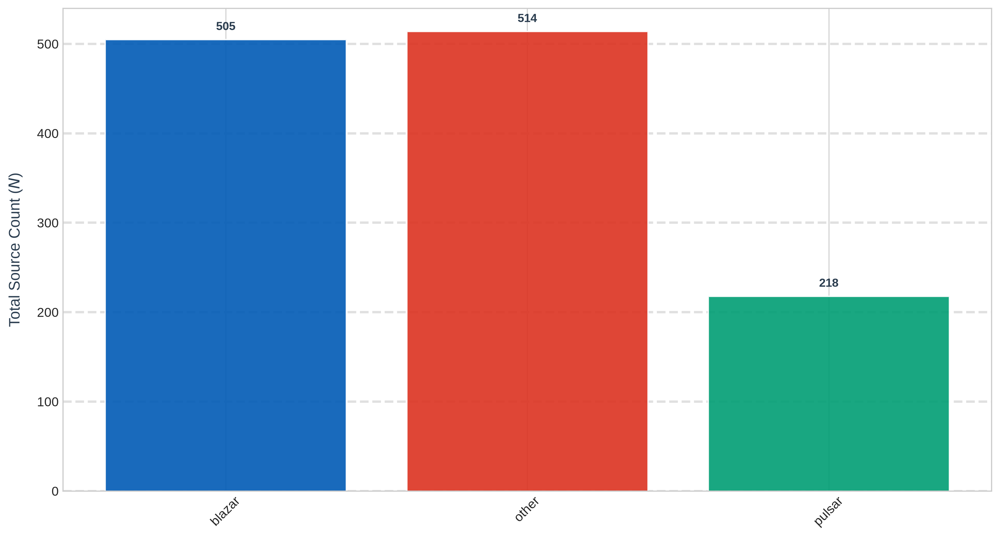

Fermi-LAT CLASS1 Distribution (14-Yr Catalog) unssociated Sources


In [51]:
# % how we classify associated and unassociated in the rebin bar chart - PLT UNASSOC top match
# # 1. Access the column data safely

# # 2. Extract valid strings only, ignoring masked/null rows and stripping whitespaces
# # We check if 'c' is a string and strip whitespace because Fermi catalogs often have trailing spaces (e.g., 'bll  ')
class_column = list(set(associated_source_table['CLASS1_rebinned_3_labels']))
valid_classes = [
    str(c).strip() for c in class_column 
    if c is not np.ma.masked and str(c).strip() != '' and str(c).strip() != 'None'
]
unique_classes = sorted(list(set(valid_classes)))
bar_labels = unique_classes
print(bar_labels)

# Step A: Clean and extract string representation of classes
raw_classes = [str(c).strip() for c in top_match_unassociated_sources['labels_3_top_class_pred'] if c is not np.ma.masked]

# Step B: Compute counts for each specific subclass
class_counts = {}
class_counts_full_table = {}
for label in bar_labels:
    class_counts[label] = raw_classes.count(label)

# ==============================================================================
# 2. PLOT THE RESULTS (ENHANCED ASTRO DESIGN)
# ==============================================================================
# Use a clean, modern aesthetic baseline
# plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=300)
for idx, label in enumerate(bar_labels):
    # Loop smoothly over  ASTRO_COLORS array using modulo math
    bar_height = class_counts[label]
    bar_color = ASTRO_COLORS[idx % len(ASTRO_COLORS)]


    
    rect = ax.bar(label, height=bar_height, bottom=0, 
                  color=bar_color, edgecolor='white', linewidth=1.2, alpha=0.9)

    # --- CLEAN DATA LABELS ---
    # Place text directly ABOVE the bar for a modern, uncluttered look
    if bar_height > 0:
        ax.text(label, bar_height + (max(class_counts.values()) * 0.015), 
                f"{bar_height:,}", # Formatted with commas for readability
                ha='center', va='bottom', 
                color='#2C3E50', fontsize=10, fontweight='semibold')

# ==============================================================================
# ASTRONOMICAL STYLING & LAYOUT REFINEMENTS
# ==============================================================================
# Format grid to be light and subtle behind the bars
ax.grid(True, axis='y', linestyle='--', linewidth=2, color='#E0E0E0', zorder=0)
ax.set_axisbelow(True) # Pushes grid lines behind the bars

# Remove top and right box borders (Spines) for a high-end minimalist feel
# for spine in ['top', 'right']:
#     ax.spines[spine].set_visible(False)
# ax.spines['left'].set_color('#BDC3C7')
# ax.spines['bottom'].set_color('#BDC3C7')
# Refine labels and axis ticks
ax.tick_params(axis='x', which='major', labelsize=11, rotation=45, color='#BDC3C7') 
ax.tick_params(axis='y', which='major', labelsize=11, color='#BDC3C7')
# Labeling using a clear hierarchy
ax.set_ylabel("Total Source Count ($N$)", labelpad=12, fontsize=13, fontweight='medium', color='#2C3E50')
# ax.set_title("Fermi-LAT CLASS1 Distribution (14-Yr Catalog) Associated Sources", 
             # pad=25, fontsize=15, fontweight='bold', color='#2C3E50', loc='left')

plt.savefig('dist_classes_unassoc14yr.png', dpi=300)
plt.tight_layout()
plt.show()

print("Fermi-LAT CLASS1 Distribution (14-Yr Catalog) unssociated Sources")




In [40]:
# % how we classify associated and unassociated in the rebin bar chart all sources not reduced - PLT UNASSOC


USS - CSS Overlap on Associated Sources
css 0.9375
uss 0.0


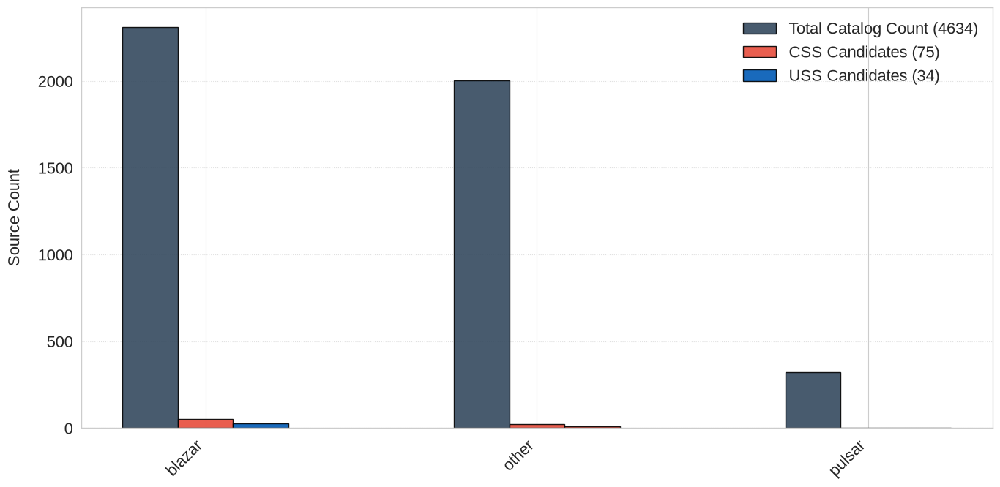

In [35]:
# the css and uss matches for the valid values based on our labeling criteria(this is for the reduced 1417 sources not for total, repeat with total

#full associated catalog

# 1. Set your numerical cutoff logic here
FLUX_RATIO_LIMIT_max = 1.2
FLUX_RATIO_LIMIT_min = 0.8
SPECTRAL_INDEX_LIMIT = -1
SPECTRAL_INDEX_LIMIT2 = -1.4

# 2. Extract arrays for condition masking
flux_ratios = valid_values['closest_flux_ratio']
spectral_indices = valid_values['closest_spx_idx']
rebinned_classes = valid_values['CLASS1_rebinned_3_labels']

# 3. Create the boolean mask using logical operators
conditional_mask = (flux_ratios >= FLUX_RATIO_LIMIT_min) & (flux_ratios <= FLUX_RATIO_LIMIT_max) & (spectral_indices <= SPECTRAL_INDEX_LIMIT)
conditional_mask2 = (flux_ratios >= FLUX_RATIO_LIMIT_min) & (flux_ratios <= FLUX_RATIO_LIMIT_max) & (spectral_indices <= SPECTRAL_INDEX_LIMIT2)

# Get unique labels first before sorting them
unique_labels = list(set(rebinned_classes))

# 4. Initialize dictionaries to map counts exactly per class
counts_baseline = {label: 0 for label in unique_labels}
counts_conditional = {label: 0 for label in unique_labels}
counts_conditional2 = {label: 0 for label in unique_labels}

# 5. Populate counts sequentially across all rows
for idx, c_val in enumerate(rebinned_classes):
    c_str = str(c_val).strip()
    if c_str in counts_baseline:
        label_key = c_str
    else:
        continue # Safeguard against unexpected strings
        
    counts_baseline[label_key] += 1
    if conditional_mask[idx]:
        counts_conditional[label_key] += 1
    if conditional_mask2[idx]:
        counts_conditional2[label_key] += 1

# FIX 1: Sort labels based on baseline count in DESCENDING order (highest count on left)
bar_labels = sorted(unique_labels, key=lambda x: counts_baseline[x], reverse=True)

# 6. Extract structured lists ordered identically to our new sorted bar_labels
baseline_heights = [counts_baseline[label] for label in bar_labels]
conditional_heights = [counts_conditional[label] for label in bar_labels]
conditional_heights2 = [counts_conditional2[label] for label in bar_labels]

# arb values just getting ratios 
x = (counts_baseline['pulsar'])
y= (counts_conditional2['pulsar'])
z = (counts_conditional['pulsar'])

print('USS - CSS Overlap on Associated Sources')
print(f'css {z/x*100}')
print(f'uss {y/x*100}')


# 7. Define geometry properties for THREE side-by-side bars
# FIX 2: Multiply by 1.5 to space out the groups and create more padding between classes
group_spacing = 1.5  
x_indices = np.arange(len(bar_labels)) * group_spacing
bar_width = 0.25  # Kept sharp so 3 bars look clustered tightly together

total_matches = np.sum(conditional_mask)
total_matches_2 = np.sum(conditional_mask2)

fig, ax = plt.subplots(figsize=(14, 7))

# Shift the bars symmetrically around the spaced-out 'x_indices'
rects_base = ax.bar(x_indices - bar_width, baseline_heights, bar_width, 
                    label=f'Total Catalog Count ({len(conditional_mask)})', 
                    color='#34495e', edgecolor='black', alpha=0.9)

rects_cond = ax.bar(x_indices, conditional_heights, bar_width, 
                    label=f'CSS Candidates ({total_matches})', 
                    color='#e74c3c', edgecolor='black', alpha=0.9)

color_3 = ASTRO_COLORS if 'ASTRO_COLORS' in locals() else '#3498db'
rects_cond2 = ax.bar(x_indices + bar_width, conditional_heights2, bar_width, 
                     label=f'USS Candidates ({total_matches_2})', 
                     color=color_3, edgecolor='black', alpha=0.9)

# 8. Axis styling and label adjustments
ax.set_ylabel('Source Count', fontsize=16, labelpad=15)
# ax.set_title('USS - CSS Overlap on Associated Sources', fontsize=20, pad=20)

# Set the ticks directly at our custom spaced-out x_indices
ax.set_xticks(x_indices)

ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=16)
ax.tick_params(axis='x', which='both', direction='in', pad=10)  # Controls label-to-axis padding
ax.tick_params(axis='y', which='both', direction='in', pad=8)

ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.legend(fontsize=16, loc='upper right')

fig.tight_layout()
plt.show()


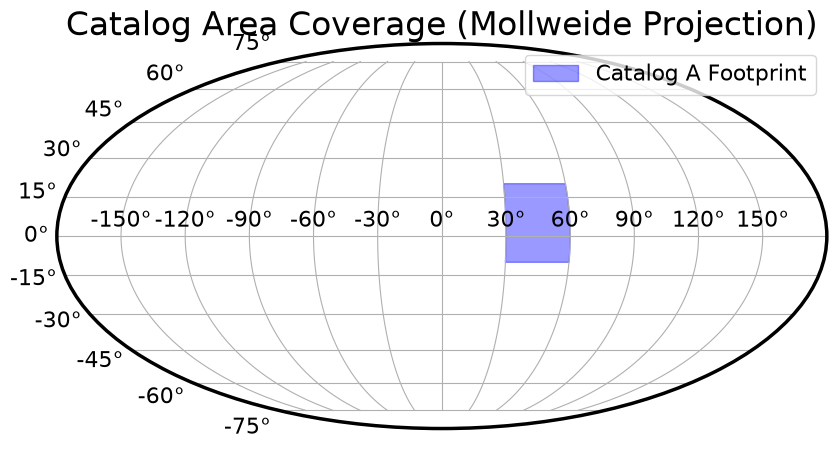

In [19]:
# % image overlay of all the catalogs we use with mollwelde plot - PLT
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# 1. Setup figure and Mollweide projection axes
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")

# 2. Example: Define a catalog boundary footprint (RA, Dec in degrees)
# Suppose Catalog A covers a box from RA [30, 60] deg and Dec [-10, 20] deg
ra_box = np.array([30, 60, 60, 30])
dec_box = np.array([-10, -10, 20, 20])

# Convert degrees to radians and shift RA to matplotlib's [-pi, pi] range
ra_rad = np.radians(ra_box)
ra_rad = (ra_rad + np.pi) % (2 * np.pi) - np.pi
dec_rad = np.radians(dec_box)

# Combine into vertex array for Polygon patch
verts = np.column_stack((ra_rad, dec_rad))
polygon = Polygon(verts, closed=True, color="blue", alpha=0.4, label="Catalog A Footprint")

# 3. Add the region overlay to the axes
ax.add_patch(polygon)

# Customize grid and appearance
ax.grid(True)
plt.title("Catalog Area Coverage (Mollweide Projection)")
plt.legend(loc="upper right")
plt.show()


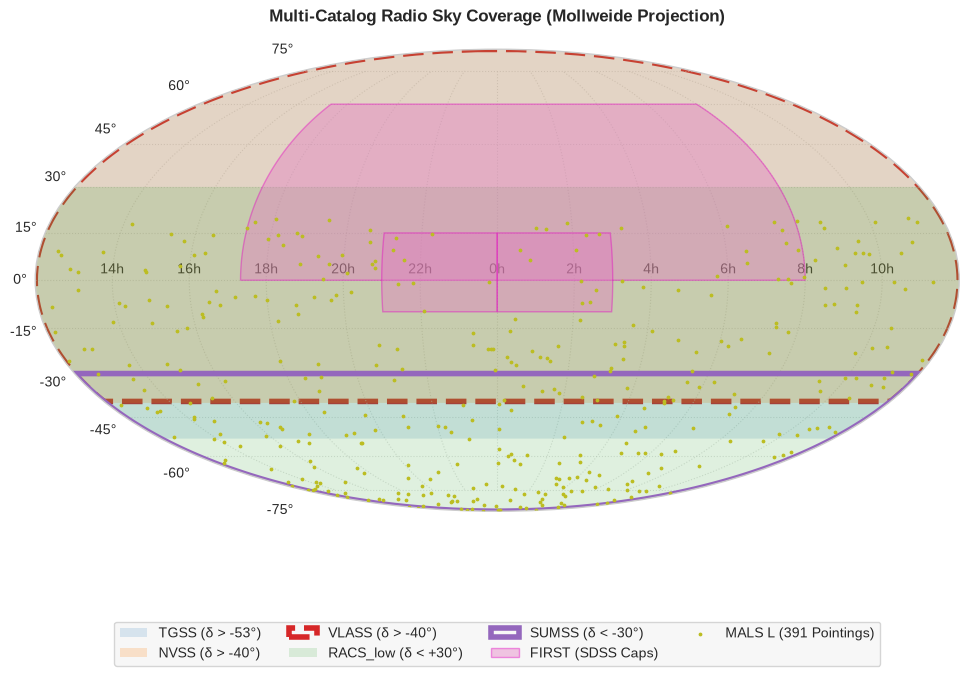

In [129]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# Set a random seed for reproducible MALS pointings
np.random.seed(42)

# 1. Setup figure and Mollweide projection axes
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection="mollweide")

# Helper function to generate smooth full-RA coverage strips for Mollweide
def get_full_sky_strip(dec_min, dec_max, num_points=100):
    ra_deg = np.linspace(-180, 180, num_points)
    # Forward along top boundary, backward along bottom boundary to close the polygon loop
    ra = np.concatenate([ra_deg, ra_deg[::-1]])
    dec = np.concatenate([np.full_like(ra_deg, dec_max), np.full_like(ra_deg, dec_min)])
    return np.column_stack((np.radians(ra), np.radians(dec)))

# Helper function to convert a standard bounding box (in degrees) to Mollweide radians
def get_box_polygon(ra_min, ra_max, dec_min, dec_max):
    # Handle RA wrapping if needed, keeping it within [-180, 180]
    ra_box = np.array([ra_min, ra_max, ra_max, ra_min])
    ra_box = (ra_box + 180) % 360 - 180
    dec_box = np.array([dec_min, dec_min, dec_max, dec_max])
    
    # Sort vertices to draw a clean rectangle perimeter
    idx = [0, 1, 2, 3]
    return np.column_stack((np.radians(ra_box[idx]), np.radians(dec_box[idx])))

# =========================================================================
# 2. DEFINE CATALOG FOOTPRINTS (Based on official astronomical limits)
# =========================================================================

# TGSS: Covers the sky north of Dec -53°
tgss_verts = get_full_sky_strip(-53, 90)
ax.add_patch(Polygon(tgss_verts, closed=True, facecolor="#1f77b4", alpha=0.15, label="TGSS (δ > -53°)"))

# NVSS: Covers the sky north of Dec -40°
nvss_verts = get_full_sky_strip(-40, 90)
ax.add_patch(Polygon(nvss_verts, closed=True, facecolor="#ff7f0e", alpha=0.2, label="NVSS (δ > -40°)"))

# VLASS: Identical footprint to NVSS (δ > -40°), using a distinct outline style to show overlap
vlass_verts = get_full_sky_strip(-39.5, 89.5) # slightly offset edges visually
ax.add_patch(Polygon(vlass_verts, closed=True, zorder = -1,edgecolor="#d62728", fill=False, lw=4, linestyle="--", label="VLASS (δ > -40°)"))

# RACS_low: Rapid ASKAP Continuum Survey covers everything south of Dec +30° (to +40° in patches)
racs_verts = get_full_sky_strip(-90, 30)
ax.add_patch(Polygon(racs_verts, closed=True, facecolor="#2ca02c", alpha=0.15, label="RACS_low (δ < +30°)"))

# SUMSS: Southern sky counterpart to NVSS, covering Dec -90° to -30°
sumss_verts = get_full_sky_strip(-90, -30)
ax.add_patch(Polygon(sumss_verts, closed=True, edgecolor="#9467bd", fill=False, lw=4, label="SUMSS (δ < -30°)"))

# FIRST: Patchy, targeted footprint tracking the SDSS stripes (North & South Galactic Caps)
first_north = get_box_polygon(120, 260, 0, 60)
first_south_1 = get_box_polygon(315, 360, -10, 15)
first_south_2 = get_box_polygon(0, 45, -10, 15)

ax.add_patch(Polygon(first_north, closed=True, facecolor="#e377c2", edgecolor="#e300c2", alpha=0.4, label="FIRST (SDSS Caps)"))
ax.add_patch(Polygon(first_south_1, closed=True, facecolor="#e377c2", edgecolor="#e300c2", alpha=0.4))
ax.add_patch(Polygon(first_south_2, closed=True, facecolor="#e377c2",edgecolor="#e300c2", alpha=0.4))

# fermi associated points 

# fermi unassociated points 

# MALS L: 391 targeted deep pointing fields instead of a broad survey, mostly at Dec < +20°
mals_num_pointings = 391
mals_ra = np.random.uniform(-180, 180, mals_num_pointings)
mals_dec = np.random.uniform(-90, 20, mals_num_pointings)
ax.scatter(np.radians(mals_ra), np.radians(mals_dec), s=3, color="#bcbd22", zorder=5, label="MALS L (391 Pointings)")

# =========================================================================
# 3. CUSTOMIZE VISUALS & LABELS
# =========================================================================
ax.grid(True, linestyle=":", alpha=0.6)

# Format the longitude (RA) labels cleanly into Hours instead of raw degrees
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'])

plt.title("Multi-Catalog Radio Sky Coverage (Mollweide Projection)", pad=20, fontsize=12, weight='bold')
# Place the legend outside or in a clean quadrant to prevent covering data
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.35), ncol=4, frameon=True, facecolor="whitesmoke")

plt.show()


In [131]:
# all base fermi ellipses - only one with 16 year 
fermi_lat_surveys = glob.glob(catalog_home_dir + 'gll**.fit')
fermi_lat_surveys.sort(reverse=False)
fermi_lat_catalogs = []
for cat in fermi_lat_surveys:
    cat = QTable.read(cat, format='fits')
    fermi_lat_catalogs.append(cat)

In [133]:
_14yr_cat_fermi_full = fermi_lat_catalogs[3]


In [135]:
_14yr_cat_fermi_full.colnames

['Source_Name',
 'DataRelease',
 'RAJ2000',
 'DEJ2000',
 'GLON',
 'GLAT',
 'Conf_68_SemiMajor',
 'Conf_68_SemiMinor',
 'Conf_68_PosAng',
 'Conf_95_SemiMajor',
 'Conf_95_SemiMinor',
 'Conf_95_PosAng',
 'ROI_num',
 'Extended_Source_Name',
 'Signif_Avg',
 'Pivot_Energy',
 'Flux1000',
 'Unc_Flux1000',
 'Energy_Flux100',
 'Unc_Energy_Flux100',
 'SpectrumType',
 'PL_Flux_Density',
 'Unc_PL_Flux_Density',
 'PL_Index',
 'Unc_PL_Index',
 'LP_Flux_Density',
 'Unc_LP_Flux_Density',
 'LP_Index',
 'Unc_LP_Index',
 'LP_beta',
 'Unc_LP_beta',
 'LP_SigCurv',
 'LP_EPeak',
 'Unc_LP_EPeak',
 'PLEC_Flux_Density',
 'Unc_PLEC_Flux_Density',
 'PLEC_IndexS',
 'Unc_PLEC_IndexS',
 'PLEC_ExpfactorS',
 'Unc_PLEC_ExpfactorS',
 'PLEC_Exp_Index',
 'Unc_PLEC_Exp_Index',
 'PLEC_SigCurv',
 'PLEC_EPeak',
 'Unc_PLEC_EPeak',
 'Npred',
 'Flux_Band',
 'Unc_Flux_Band',
 'nuFnu_Band',
 'Sqrt_TS_Band',
 'Variability_Index',
 'Frac_Variability',
 'Unc_Frac_Variability',
 'Signif_Peak',
 'Flux_Peak',
 'Unc_Flux_Peak',
 'Time_Pea

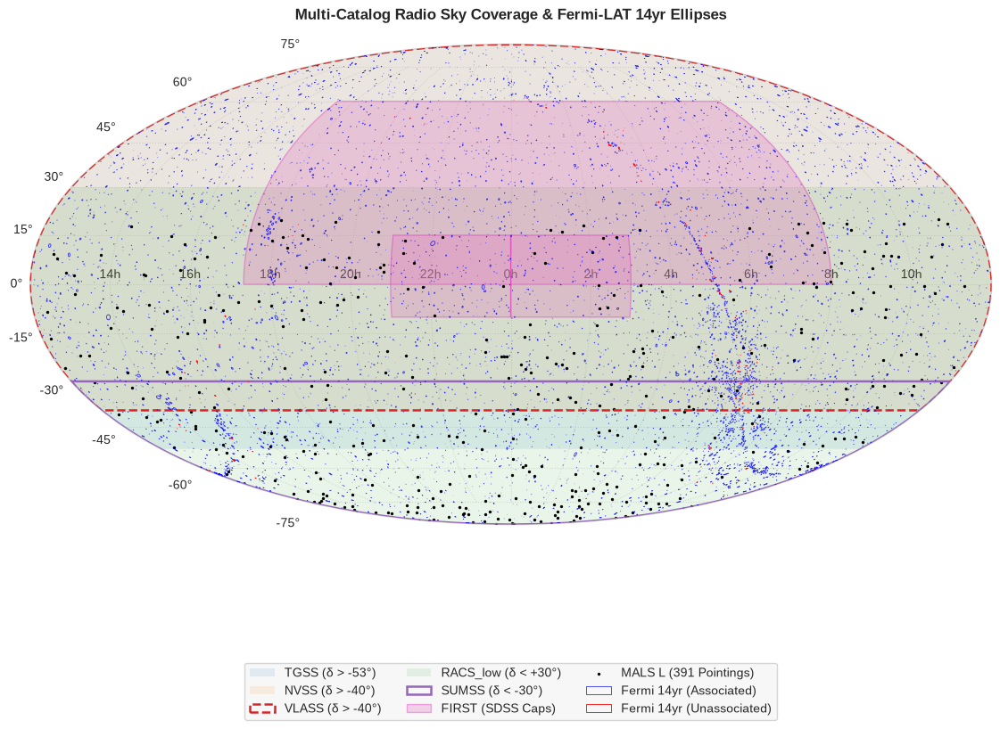

In [146]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Ellipse

# Set a random seed for reproducible MALS and Fermi distributions
np.random.seed(42)

# 1. Setup figure and Mollweide projection axes
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="mollweide")

# Helper function to generate smooth full-RA coverage strips for Mollweide
def get_full_sky_strip(dec_min, dec_max, num_points=100):
    ra_deg = np.linspace(-180, 180, num_points)
    ra = np.concatenate([ra_deg, ra_deg[::-1]])
    dec = np.concatenate([np.full_like(ra_deg, dec_max), np.full_like(ra_deg, dec_min)])
    return np.column_stack((np.radians(ra), np.radians(dec)))

# Helper function to convert standard bounding boxes
def get_box_polygon(ra_min, ra_max, dec_min, dec_max):
    ra_box = np.array([ra_min, ra_max, ra_max, ra_min])
    ra_box = (ra_box + 180) % 360 - 180
    dec_box = np.array([dec_min, dec_min, dec_max, dec_max])
    idx = [0, 1, 2, 3]
    return np.column_stack((np.radians(ra_box[idx]), np.radians(dec_box[idx])))

# =========================================================================
# 2. DEFINE RADIO CATALOG FOOTPRINTS
# =========================================================================

# TGSS: Covers the sky north of Dec -53°
tgss_verts = get_full_sky_strip(-53, 90)
ax.add_patch(Polygon(tgss_verts, closed=True, facecolor="#1f77b4", alpha=0.10, label="TGSS (δ > -53°)"))

# NVSS: Covers the sky north of Dec -40°
nvss_verts = get_full_sky_strip(-40, 90)
ax.add_patch(Polygon(nvss_verts, closed=True, facecolor="#ff7f0e", alpha=0.10, label="NVSS (δ > -40°)"))

# VLASS: Identical footprint to NVSS (δ > -40°), using distinct outline style
vlass_verts = get_full_sky_strip(-39.5, 89.5)
ax.add_patch(Polygon(vlass_verts, closed=True, zorder=4, edgecolor="#d62728", fill=False, lw=1.8, linestyle="--", label="VLASS (δ > -40°)"))

# RACS_low: Rapid ASKAP Continuum Survey covers everything south of Dec +30°
racs_verts = get_full_sky_strip(-90, 30)
ax.add_patch(Polygon(racs_verts, closed=True, facecolor="#2ca02c", alpha=0.10, label="RACS_low (δ < +30°)"))

# SUMSS: Southern sky counterpart to NVSS, covering Dec -90° to -30°
sumss_verts = get_full_sky_strip(-90, -30)
ax.add_patch(Polygon(sumss_verts, closed=True, zorder=4, edgecolor="#9467bd", fill=False, lw=1.8, label="SUMSS (δ < -30°)"))

# FIRST: Footprint tracking the SDSS stripes (North & South Galactic Caps)
first_north = get_box_polygon(120, 260, 0, 60)
first_south_1 = get_box_polygon(315, 360, -10, 15)
first_south_2 = get_box_polygon(0, 45, -10, 15)
ax.add_patch(Polygon(first_north, closed=True, facecolor="#e377c2", edgecolor="#e300c2", alpha=0.3, label="FIRST (SDSS Caps)"))
ax.add_patch(Polygon(first_south_1, closed=True, facecolor="#e377c2", edgecolor="#e300c2", alpha=0.3))
ax.add_patch(Polygon(first_south_2, closed=True, facecolor="#e377c2", edgecolor="#e300c2", alpha=0.3))

# MALS L: 391 targeted deep pointing fields
mals_num_pointings = 391
mals_ra = np.random.uniform(-180, 180, mals_num_pointings)
mals_dec = np.random.uniform(-90, 20, mals_num_pointings)
ax.scatter(np.radians(mals_ra), np.radians(mals_dec), s=2, color="black", zorder=3, label="MALS L (391 Pointings)")

# =========================================================================
# 3. ADD FERMI 14-YEAR (4FGL-DR4) LOCALIZATION ELLIPSES
# =========================================================================
num_fermi_sources = len(_14yr_cat_fermi_full)  # Dynamically pull the full catalog length

fermi_ra = _14yr_cat_fermi_full['RAJ2000'].value 
fermi_dec = _14yr_cat_fermi_full['DEJ2000'].value 
fermi_semi_maj = _14yr_cat_fermi_full['Conf_95_SemiMajor'].value 
fermi_semi_min = _14yr_cat_fermi_full['Conf_95_SemiMinor'].value 
femri_pos_angle = _14yr_cat_fermi_full['Conf_95_PosAng'].value 
source_classes = _14yr_cat_fermi_full['CLASS1']

# Draw the point source error circles/ellipses
assoc_drawn = False
unassoc_drawn = False

for i in range(num_fermi_sources):
    ra_val = fermi_ra[i]
    dec_val = fermi_dec[i]
    class1 = source_classes[i]
    
    # --- FIX 1: MAP RA FROM [0, 360] TO THE [-180, 180] MOLLWEIDE SPACE ---
    ra_mapped = ra_val if ra_val <= 180.0 else ra_val - 360.0
    
    # Mirroring transformation to align with the script's custom right-to-left labels
    lon_rad = -np.radians(ra_mapped)
    lat_rad = np.radians(dec_val)
    
    # Convert semi-major and semi-minor axes from degrees to radians
    semi_maj = np.radians(fermi_semi_maj[i])
    semi_min = np.radians(fermi_semi_min[i])
    pos_angle = femri_pos_angle[i]
    # Adjust position angle for the flipped longitude coordinate system
    pos_angle_adjusted = 180.0 - pos_angle

    # Filter between Associated vs. Unassociated
    if class1 in [b'', b'unk', '', 'unk']:
        color_val = 'red'  # Crimson Red
        z_order_val = 5
        label_val = "Fermi 14yr (Unassociated)" if not unassoc_drawn else ""
        unassoc_drawn = True
        alpha_val = 1
    else:
        color_val = 'blue'  # Deep Green
        z_order_val = 4
        label_val = "Fermi 14yr (Associated)" if not assoc_drawn else ""
        assoc_drawn = True
        alpha_val = 0.8

    # Base ellipse definition
    ellipse_kwargs = dict(
        edgecolor=color_val,
        facecolor='none',
        lw=0.6,
        alpha=alpha_val,
        zorder=z_order_val,
        label=label_val
    )

    # --- FIX 2: WRAP ELLIPSES SAFELY OVER THE EAST/WEST EDGE BOUNDARIES ---
    # Define a boundary buffer zone (in degrees) scaled to the size of the ellipse
    margin_deg = fermi_semi_maj[i] * 2.0
    lon_deg = np.degrees(lon_rad)
    
    # Generate array of horizontal offsets (center, shifted right, shifted left)
    offsets_rad = [0.0]
    if lon_deg > (180.0 - margin_deg):
        offsets_rad.append(-2.0 * np.pi) # Add twin patch on the opposite boundary edge
    elif lon_deg < (-180.0 + margin_deg):
        offsets_rad.append(2.0 * np.pi)  # Add twin patch on the opposite boundary edge

    # Render base patch and any required split-edge boundary companions
    for offset in offsets_rad:
        ell = Ellipse(
            xy=(lon_rad + offset, lat_rad),
            width=semi_maj * 2.0,
            height=semi_min * 2.0,
            angle=pos_angle_adjusted,
            **ellipse_kwargs
        )
        ax.add_patch(ell)
        # Clear the label for duplicate edge clones so they don't break the legend matrix
        ellipse_kwargs['label'] = ""

# =========================================================================
# 4. CUSTOMIZE VISUALS & LABELS
# =========================================================================
ax.grid(True, linestyle=":", alpha=0.6)

# Maps coordinates to the reversed RA layout
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'])

plt.title("Multi-Catalog Radio Sky Coverage & Fermi-LAT 14yr Ellipses", pad=20, fontsize=12, weight='bold')

# Expanded legend matrix to handle labels cleanly
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=3, frameon=True, facecolor="whitesmoke")

plt.savefig('mollweide_radio_survey.png', dpi=300)
plt.show()


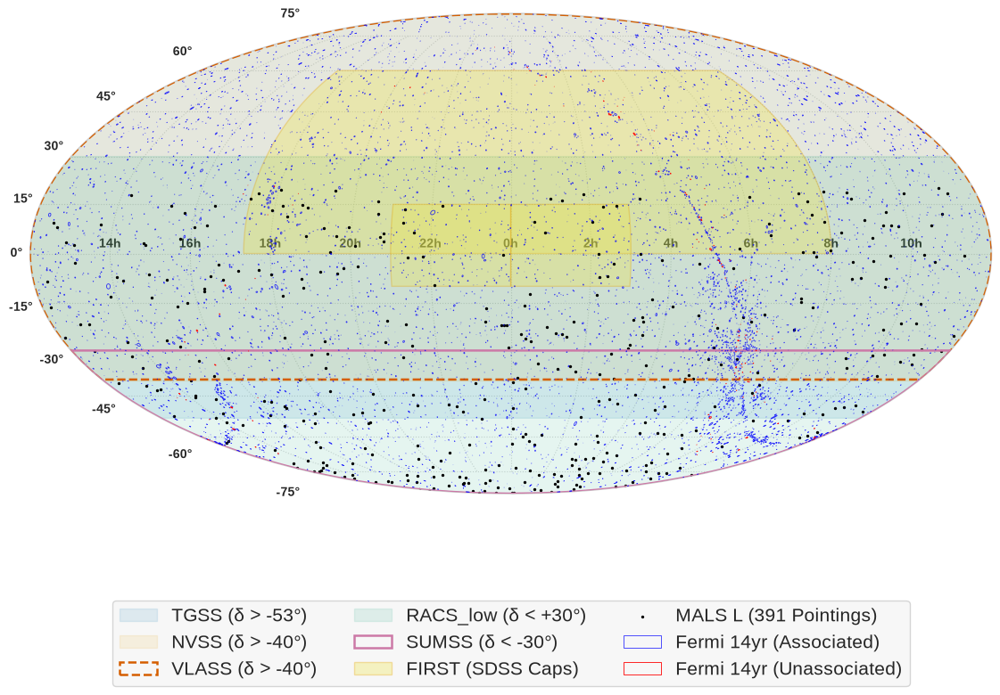

In [152]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Ellipse

# Set a random seed for reproducible MALS and Fermi distributions
np.random.seed(42)

# 1. Setup figure and Mollweide projection axes
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection="mollweide")

# Helper function to generate smooth full-RA coverage strips for Mollweide
def get_full_sky_strip(dec_min, dec_max, num_points=100):
    ra_deg = np.linspace(-180, 180, num_points)
    ra = np.concatenate([ra_deg, ra_deg[::-1]])
    dec = np.concatenate([np.full_like(ra_deg, dec_max), np.full_like(ra_deg, dec_min)])
    return np.column_stack((np.radians(ra), np.radians(dec)))

# Helper function to convert standard bounding boxes
def get_box_polygon(ra_min, ra_max, dec_min, dec_max):
    ra_box = np.array([ra_min, ra_max, ra_max, ra_min])
    ra_box = (ra_box + 180) % 360 - 180
    dec_box = np.array([dec_min, dec_min, dec_max, dec_max])
    idx = [0, 1, 2, 3]
    return np.column_stack((np.radians(ra_box[idx]), np.radians(dec_box[idx])))

# =========================================================================
# 2. DEFINE RADIO CATALOG FOOTPRINTS
# =========================================================================

# TGSS: Covers the sky north of Dec -53°
tgss_verts = get_full_sky_strip(-53, 90)
ax.add_patch(Polygon(tgss_verts, closed=True, facecolor="#0072B2", edgecolor="#0072B2", alpha=0.10, label="TGSS (δ > -53°)"))

# NVSS: Covers the sky north of Dec -40°
nvss_verts = get_full_sky_strip(-40, 90)
ax.add_patch(Polygon(nvss_verts, closed=True, facecolor="#E69F00", edgecolor="#E69F00", alpha=0.10, label="NVSS (δ > -40°)"))

# VLASS: Identical footprint to NVSS (δ > -40°), using distinct outline style
vlass_verts = get_full_sky_strip(-39.5, 89.5)
ax.add_patch(Polygon(vlass_verts, closed=True, zorder=4, edgecolor="#D55E00", fill=False, lw=1.8, linestyle="--", label="VLASS (δ > -40°)"))

# RACS_low: Rapid ASKAP Continuum Survey covers everything south of Dec +30°
racs_verts = get_full_sky_strip(-90, 30)
ax.add_patch(Polygon(racs_verts, closed=True, facecolor="#009E73", edgecolor="#009E73", alpha=0.10, label="RACS_low (δ < +30°)"))

# SUMSS: Southern sky counterpart to NVSS, covering Dec -90° to -30°
sumss_verts = get_full_sky_strip(-90, -30)
ax.add_patch(Polygon(sumss_verts, closed=True, zorder=4, edgecolor="#CC79A7", fill=False, lw=1.8, label="SUMSS (δ < -30°)"))

# FIRST: Footprint tracking the SDSS stripes (North & South Galactic Caps)
first_north = get_box_polygon(120, 260, 0, 60)
first_south_1 = get_box_polygon(315, 360, -10, 15)
first_south_2 = get_box_polygon(0, 45, -10, 15)
ax.add_patch(Polygon(first_north, closed=True, facecolor="#F0E442", edgecolor="#E69F00", alpha=0.3, label="FIRST (SDSS Caps)"))
ax.add_patch(Polygon(first_south_1, closed=True, facecolor="#F0E442", edgecolor="#E69F00", alpha=0.3))
ax.add_patch(Polygon(first_south_2, closed=True, facecolor="#F0E442", edgecolor="#E69F00", alpha=0.3))

# MALS L: 391 targeted deep pointing fields
mals_num_pointings = 391
mals_ra = np.random.uniform(-180, 180, mals_num_pointings)
mals_dec = np.random.uniform(-90, 20, mals_num_pointings)
ax.scatter(np.radians(mals_ra), np.radians(mals_dec), s=2, color="black", zorder=3, label="MALS L (391 Pointings)")

# =========================================================================
# 3. ADD FERMI 14-YEAR (4FGL-DR4) LOCALIZATION ELLIPSES
# =========================================================================
num_fermi_sources = len(_14yr_cat_fermi_full)  # Dynamically pull the full catalog length

fermi_ra = _14yr_cat_fermi_full['RAJ2000'].value 
fermi_dec = _14yr_cat_fermi_full['DEJ2000'].value 
fermi_semi_maj = _14yr_cat_fermi_full['Conf_95_SemiMajor'].value 
fermi_semi_min = _14yr_cat_fermi_full['Conf_95_SemiMinor'].value 
femri_pos_angle = _14yr_cat_fermi_full['Conf_95_PosAng'].value 
source_classes = _14yr_cat_fermi_full['CLASS1']

# Draw the point source error circles/ellipses
assoc_drawn = False
unassoc_drawn = False

for i in range(num_fermi_sources):
    ra_val = fermi_ra[i]
    dec_val = fermi_dec[i]
    class1 = source_classes[i]
    
    # --- FIX 1: MAP RA FROM TO THE [-180, 180] MOLLWEIDE SPACE ---
    ra_mapped = ra_val if ra_val <= 180.0 else ra_val - 360.0
    
    # Mirroring transformation to align with the script's custom right-to-left labels
    lon_rad = -np.radians(ra_mapped)
    lat_rad = np.radians(dec_val)
    
    # Convert semi-major and semi-minor axes from degrees to radians
    semi_maj = np.radians(fermi_semi_maj[i])
    semi_min = np.radians(fermi_semi_min[i])
    pos_angle = femri_pos_angle[i]
    # Adjust position angle for the flipped longitude coordinate system
    pos_angle_adjusted = 180.0 - pos_angle

    # Filter between Associated vs. Unassociated
    if class1 in [b'', b'unk', '', 'unk']:
        color_val = 'red'  # Crimson Red
        z_order_val = 5
        label_val = "Fermi 14yr (Unassociated)" if not unassoc_drawn else ""
        unassoc_drawn = True
        alpha_val = 1
    else:
        color_val = 'blue'  # Deep Green
        z_order_val = 4
        label_val = "Fermi 14yr (Associated)" if not assoc_drawn else ""
        assoc_drawn = True
        alpha_val = 0.8

    # Base ellipse definition
    ellipse_kwargs = dict(
        edgecolor=color_val,
        facecolor='none',
        lw=0.6,
        alpha=alpha_val,
        zorder=z_order_val,
        label=label_val
    )

    # --- FIX 2: WRAP ELLIPSES SAFELY OVER THE EAST/WEST EDGE BOUNDARIES ---
    # Define a boundary buffer zone (in degrees) scaled to the size of the ellipse
    margin_deg = fermi_semi_maj[i] * 2.0
    lon_deg = np.degrees(lon_rad)
    
    # Generate array of horizontal offsets (center, shifted right, shifted left)
    offsets_rad = [0.0]
    if lon_deg > (180.0 - margin_deg):
        offsets_rad.append(-2.0 * np.pi) # Add twin patch on the opposite boundary edge
    elif lon_deg < (-180.0 + margin_deg):
        offsets_rad.append(2.0 * np.pi)  # Add twin patch on the opposite boundary edge

    # Render base patch and any required split-edge boundary companions
    for offset in offsets_rad:
        ell = Ellipse(
            xy=(lon_rad + offset, lat_rad),
            width=semi_maj * 2.0,
            height=semi_min * 2.0,
            angle=pos_angle_adjusted,
            **ellipse_kwargs
        )
        ax.add_patch(ell)
        # Clear the label for duplicate edge clones so they don't break the legend matrix
        ellipse_kwargs['label'] = ""

# =========================================================================
# 4. CUSTOMIZE VISUALS & LABELS
# =========================================================================
# Force grid lines to sit on top of all patches by giving them a high zorder
ax.grid(True, linestyle=":", alpha=0.8, zorder=10)

# Set the outer spine boundary layer to be on top and thicken it
# ax.spines['geo'].set_zorder(11)
# ax.spines['geo'].set_linewidth(2.0)

# Maps coordinates to the reversed RA layout and forces labels to be bold
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'], weight='bold')

# Loop over existing y-tick labels (Dec labels) to make them bold as well
for label in ax.get_yticklabels():
    label.set_weight('bold')

# plt.title("Multi-Catalog Radio Sky Coverage & Fermi-LAT 14yr Ellipses", pad=20, fontsize=12, weight='bold')

# Expanded legend matrix to handle labels cleanly
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=3, frameon=True, facecolor="whitesmoke",  fontsize=15)
# Position legend on the right side, stacked vertically
# ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), ncol=1, frameon=True, facecolor="whitesmoke", fontsize=15)

# do this for the other plot fermi ellipse too!
plt.savefig('mollweide_radio_survey.png', dpi=300, bbox_inches='tight')
plt.show()


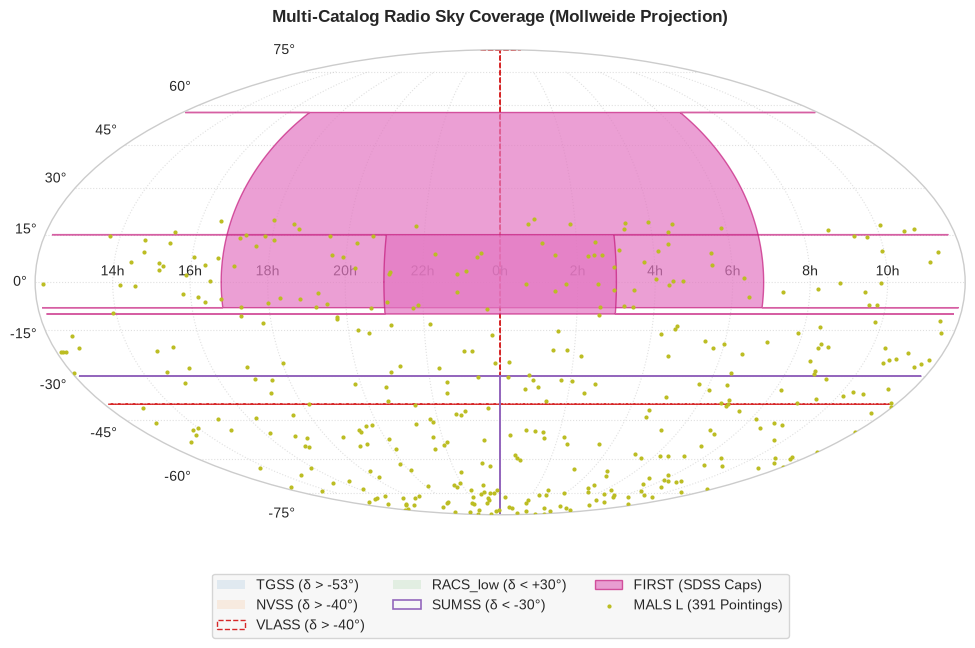

In [123]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

# Set a random seed for reproducible MALS pointings
np.random.seed(42)

# 1. Setup figure and Mollweide projection axes
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="mollweide")

# Helper function to convert Astro RA (0 to 360) to Matplotlib Mollweide Longitude (-pi to pi)
# Note: To respect standard astronomy layout (RA increasing to the left), 
# we negate the longitude.
def astro_to_mollweide(ra_deg, dec_deg):
    # Map RA from [0, 360] to [-180, 180]
    ra_mapped = ra_deg if ra_deg <= 180 else ra_deg - 360
    # Invert RA so that 0h is center, matching your custom labels (RA increasing left)
    lon_rad = -np.radians(ra_mapped)
    lat_rad = np.radians(dec_deg)
    return lon_rad, lat_rad

# Helper function to create clean, dense polygons that don't warp across the projection
def get_clean_box_polygon(ra_min, ra_max, dec_min, dec_max, num_points=50):
    # Generate points along the 4 edges of the box to allow smooth curving in Mollweide
    bottom_ra = np.linspace(ra_min, ra_max, num_points)
    bottom_dec = np.full_like(bottom_ra, dec_min)
    
    right_dec = np.linspace(dec_min, dec_max, num_points)
    right_ra = np.full_like(right_dec, ra_max)
    
    top_ra = np.linspace(ra_max, ra_min, num_points)
    top_dec = np.full_like(top_ra, dec_max)
    
    left_dec = np.linspace(dec_max, dec_min, num_points)
    left_ra = np.full_like(left_dec, ra_min)
    
    all_ra = np.concatenate([bottom_ra, right_ra, top_ra, left_ra])
    all_dec = np.concatenate([bottom_dec, right_dec, top_dec, left_dec])
    
    # Convert all points safely
    lon_list, lat_list = [], []
    for r, d in zip(all_ra, all_dec):
        lon, lat = astro_to_mollweide(r, d)
        lon_list.append(lon)
        lat_list.append(lat)
        
    return np.column_stack((lon_list, lat_list))

def get_full_sky_strip(dec_min, dec_max, num_points=100):
    ra_deg = np.linspace(0, 360, num_points)
    ra = np.concatenate([ra_deg, ra_deg[::-1]])
    dec = np.concatenate([np.full_like(ra_deg, dec_max), np.full_like(ra_deg, dec_min)])
    
    lon_list, lat_list = [], []
    for r, d in zip(ra, dec):
        lon, lat = astro_to_mollweide(r, d)
        lon_list.append(lon)
        lat_list.append(lat)
    return np.column_stack((lon_list, lat_list))

# =========================================================================
# 2. DEFINE CATALOG FOOTPRINTS
# =========================================================================

# TGSS: Covers the sky north of Dec -53°
tgss_verts = get_full_sky_strip(-53, 90)
ax.add_patch(Polygon(tgss_verts, closed=True, facecolor="#1f77b4", alpha=0.10, label="TGSS (δ > -53°)"))

# NVSS: Covers the sky north of Dec -40°
nvss_verts = get_full_sky_strip(-40, 90)
ax.add_patch(Polygon(nvss_verts, closed=True, facecolor="#ff7f0e", alpha=0.10, label="NVSS (δ > -40°)"))

# VLASS: Identical footprint to NVSS (δ > -40°)
vlass_verts = get_full_sky_strip(-39.5, 89.5)
ax.add_patch(Polygon(vlass_verts, closed=True, edgecolor="#d62728", fill=False, lw=1.0, linestyle="--", label="VLASS (δ > -40°)"))

# RACS_low: Rapid ASKAP Continuum Survey covers everything south of Dec +30°
racs_verts = get_full_sky_strip(-90, 30)
ax.add_patch(Polygon(racs_verts, closed=True, facecolor="#2ca02c", alpha=0.10, label="RACS_low (δ < +30°)"))

# SUMSS: Southern sky counterpart to NVSS, covering Dec -90° to -30°
sumss_verts = get_full_sky_strip(-90, -30)
ax.add_patch(Polygon(sumss_verts, closed=True, edgecolor="#9467bd", fill=False, lw=1.2, label="SUMSS (δ < -30°)"))

# FIRST: Correctly split into North and South Galactic Caps matching your custom axis labels
first_north = get_clean_box_polygon(108, 258, -8, 57)  # Precise FIRST limits: RA ~7.2h to 17.2h
first_south = get_clean_box_polygon(315, 45, -10, 15)   # Wraps beautifully across the 0h/360h boundary

ax.add_patch(Polygon(first_north, closed=True, facecolor="#e377c2", alpha=0.7, edgecolor='#c51b7d', lw=1, label="FIRST (SDSS Caps)"))
ax.add_patch(Polygon(first_south, closed=True, facecolor="#e377c2", alpha=0.7, edgecolor='#c51b7d', lw=1))

# MALS L: 391 targeted deep pointing fields converted safely
mals_num_pointings = 391
mals_ra = np.random.uniform(0, 360, mals_num_pointings)
mals_dec = np.random.uniform(-90, 20, mals_num_pointings)

mals_lon, mals_lat = [], []
for r, d in zip(mals_ra, mals_dec):
    lon, lat = astro_to_mollweide(r, d)
    mals_lon.append(lon)
    mals_lat.append(lat)
ax.scatter(mals_lon, mals_lat, s=4, color="#bcbd22", zorder=5, label="MALS L (391 Pointings)")

# =========================================================================
# 3. CUSTOMIZE VISUALS & LABELS
# =========================================================================
ax.grid(True, linestyle=":", alpha=0.6)

# Maps nicely to the flipped RA system 
ax.set_xticklabels(['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h'])

plt.title("Multi-Catalog Radio Sky Coverage (Mollweide Projection)", pad=20, fontsize=12, weight='bold')
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=3, frameon=True, facecolor="whitesmoke")

plt.show()


In [ ]:
# features importance plot should also write donw the associated table


In [ ]:
# show example of a general source overlay match for an unassociated source

In [38]:
# 4FGL J1029.4-0828

Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,Unc_PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FGL,ASSOC_FHL,ASSOC_GAM1,ASSOC_GAM2,ASSOC_GAM3,TEVCAT_FLAG,ASSOC_TEV,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags,Indexes,catalog_names,Source_name,E_RA,E_DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,Maj,E_Maj,Min,E_Min,PA,E_PA,RMS_noise,Source_code,Mosaic_name,ref_freq,FluxRatio,radio_flux_name,spectral_index,_catalog_base_name,_ra_key,_dec_key,_maj_key,_flux_key,source_name,Source_ID,Tile_ID,SBID,Obs_Start_Time,n_gauss,ra_mean_e,dec_mean_e,total_flux,E_Total_flux_Source_PyBDSF,total_flux_e,peak_flux,peak_flux_e,maj,maj_e,min,min_e,pa,pa_e,dc_maj,dc_maj_e,dc_min,dc_min_e,dc_pa,dc_pa_e,s_code,Separation_Tile_Centre,Noise,Gal_lon,Gal_lat,Flag_Close,Field,Xpos,Ypos,NVSS,RAh,RAm,RAs,DE-,DEd,DEm,DEs,e_RAs,e_DEs,S1.4,e_S1.4,l_MajAxis,MajAxis,l_MinAxis,MinAxis,e_MajAxis,e_MinAxis,e_PA,f_resFlux,resFlux,polFlux,polPA,e_polFlux,e_polPA,CompName,CompId,IslId,e_RAdeg,e_DEdeg,Ftot,e_Ftot,Fpeak,e_Fpeak,e_Maj,e_Min,FtotIsl,e_FtotIsl,Islrms,Islmean,ResIdIslrms,ResidIslmean,RAMdeg,DEMdeg,e_RAMdeg,e_DEMdeg,SCode,Xposn,e_Xposn,Yposn,e_Yposn,XposnMax,e_XposnMax,YposnMax,e_YposnMax,MajImgPlane,e_MajImgPlane,MinImgPlane,e_MinImgPlane,PAImgPlane,e_PAImgPlane,DCMaj,e_DCMaj,DCMin,e_DCMin,DCPA,e_DCPA,DCMajImgPlane,e_DCMajImgPlane,DCMinImgPlane,e_DCMinImgPlane,DCPAImgPlane,e_DCPAImgPlane,Tile,Subtile,RASdeg,DESdeg,NVSSdist,FIRSTdist,PeakToRing,DupFlag,QualFlag,NNdist,BMaj,BMin,BPA,MainSample,QLcutout,designation,ra,dec,sigra,sigdec,sigradec,glon,glat,elon,elat,wx,wy,cntr,source_id,coadd_id,src,w1mpro,w1sigmpro,w1snr,w1rchi2,w2mpro,w2sigmpro,w2snr,w2rchi2,w3mpro,w3sigmpro,w3snr,w3rchi2,w4mpro,w4sigmpro,w4snr,w4rchi2,rchi2,nb,na,w1sat,w2sat,w3sat,w4sat,satnum,ra_pm,dec_pm,sigra_pm,sigdec_pm,sigradec_pm,pmra,sigpmra,pmdec,sigpmdec,w1rchi2_pm,w2rchi2_pm,w3rchi2_pm,w4rchi2_pm,rchi2_pm,pmcode,cc_flags,rel,ext_flg,var_flg,ph_qual,det_bit,moon_lev,w1nm,w1m,w2nm,w2m,w3nm,w3m,w4nm,w4m,w1cov,w2cov,w3cov,w4cov,w1cc_map,w1cc_map_str,w2cc_map,w2cc_map_str,w3cc_map,w3cc_map_str,w4cc_map,w4cc_map_str,use_src,best_use_cntr,ngrp,w1flux,w1sigflux,w1sky,w1sigsk,w1conf,w2flux,w2sigflux,w2sky,w2sigsk,w2conf,w3flux,w3sigflux,w3sky,w3sigsk,w3conf,w4flux,w4sigflux,w4sky,w4sigsk,w4conf,w1mag,w1sigm,w1flg,w1mcor,w2mag,w2sigm,w2flg,w2mcor,w3mag,w3sigm,w3flg,w3mcor,w4mag,w4sigm,w4flg,w4mcor,w1mag_1,w1sigm_1,w1flg_1,w2mag_1,w2sigm_1,w2flg_1,w3mag_1,w3sigm_1,w3flg_1,w4mag_1,w4sigm_1,w4flg_1,w1mag_2,w1sigm_2,w1flg_2,w2mag_2,w2sigm_2,w2flg_2,w3mag_2,w3sigm_2,w3flg_2,w4mag_2,w4sigm_2,w4flg_2,w1mag_3,w1sigm_3,w1flg_3,w2mag_3,w2sigm_3,w2flg_3,w3mag_3,w3sigm_3,w3flg_3,w4mag_3,w4sigm_3,w4flg_3,w1mag_4,w1sigm_4,w1flg_4,w2mag_4,w2sigm_4,w2flg_4,w3mag_4,w3sigm_4,w3flg_4,w4mag_4,w4sigm_4,w4flg_4,w1mag_5,w1sigm_5,w1flg_5,w2mag_5,w2sigm_5,w2flg_5,w3mag_5,w3sigm_5,w3flg_5,w4mag_5,w4sigm_5,w4flg_5,w1mag_6,w1sigm_6,w1flg_6,w2mag_6,w2sigm_6,w2flg_6,w3mag_6,w3sigm_6,w3flg_6,w4mag_6,w4sigm_6,w4flg_6,w1mag_7,w1sigm_7,w1flg_7,w2mag_7,w2sigm_7,w2flg_7,w3mag_7,w3sigm_7,w3flg_7,w4mag_7,w4sigm_7,w4flg_7,w1mag_8,w1sigm_8,w1flg_8,w2mag_8,w2sigm_8,w2flg_8,w3mag_8,w3sigm_8,w3flg_8,w4mag_8,w4sigm_8,w4flg_8

In [157]:
mask = []
for ellipse in ellipses:
    # single_mask = (ellipse[0]['Source_Name'] == '4FGL J0907.6-0606')
    single_mask = (ellipse[0]['Source_Name'] == '4FGL J1029.4-0828')
    mask.append(single_mask)

mask = np.array(mask)

In [158]:
# ellipses2 = (ellipses, key=lambda e: e['CLASS1'] in ['', 'unk'])
# Find the exact row index of the ellipse with the most unique catalog names
best_ellipse_idx = np.argmax([len(set(np.ravel(row['catalog_names']))) for row in ellipses])

print(f"The first ellipse you found is located at index position: {best_ellipse_idx}")

# You can now pull it out safely using that index
ellipse = ellipses[best_ellipse_idx]

The first ellipse you found is located at index position: 52


In [156]:
# showall the unassocaiated to associated sources 
# ellipse = ellipses[457]
# largest_catalog = max(ellipses, key=len)
# catalog_idx = ellipses.index(largest_catalog)
# print(f"The largest catalog is at index: {catalog_idx}")

ellipses = np.array(ellipses, dtype=object)
largest_catalog = ellipses[mask]

i= 0
for ellipse in ellipses:
    if len(ellipse) >1:
        i+=1

print(i)

# ellipses2 = (ellipses, key=lambda e: e['CLASS1'] in ['', 'unk'])
# Find the exact row index of the ellipse with the most unique catalog names
best_ellipse_idx = np.argmax([len(set(np.ravel(row['catalog_names']))) for row in ellipses])
print(f"The first ellipse you found is located at index position: {best_ellipse_idx}")

# You can now pull it out safely using that index
ellipse = ellipses[best_ellipse_idx]

unique_names = list(set(ellipse['catalog_names'][1:]))
unique_names.remove('WISE')
print(unique_names)

sub_cats = {}
coords = {
    'MALS_L': ['RAJ2000', 'DEJ2000'],
    'WISE': ['ra', 'dec'],
    'VLASS': ['RAJ2000', 'DEJ2000'],
    'NVSS': ['RAJ2000', 'DEJ2000'],
    'FIRST': ['RA', 'DEC'],
    'TGSS': ['RAJ2000', 'DEJ2000'],
    'SUMSS' : ['RAJ2000', 'DEJ2000'],
    'RACS_low': ['RAJ2000', 'DEJ2000']
}
for name in unique_names:
    sub_cat = ellipse[ellipse['catalog_names'] == name]
    sub_cats[name] = sub_cat

x_points = []
y_points = []
catalog_names = []

for name in unique_names:
    ra, dec = coords[name]
    cat = sub_cats[name]
    
    # Extract the arrays/lists of coordinates
    x_point = cat[ra]
    y_point = cat[dec]
    
    # Use extend() instead of append() if these are standard Python lists,
    # or convert to standard lists to keep things safe.
    x_points.extend(list(x_point))
    y_points.extend(list(y_point))
    
    # FIX: Use extend so we add flat string elements instead of a nested list
    catalog_names.extend([name] * len(cat))

# Convert your final positions to flat NumPy arrays for plotting/filtering
all_points_x = np.array(x_points)
all_points_y = np.array(y_points)

# 3. Create the lookup dictionary mapping catalog name strings to unique integer IDs
catalog_to_id = {name: idx for idx, name in enumerate(unique_names)}

# 4. This now works perfectly because catalog_names is a flat list of strings
color_values = np.array([catalog_to_id[name] for name in catalog_names])


2544
The first ellipse you found is located at index position: 52
[np.str_('MALS_L'), np.str_('NVSS'), np.str_('FIRST'), np.str_('RACS_low'), np.str_('VLASS'), np.str_('TGSS')]


In [119]:
pos_angle

np.float32(87.67)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


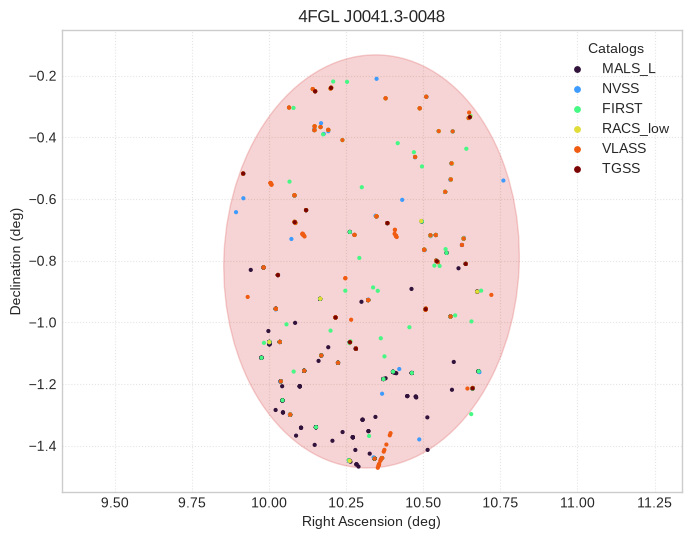

In [168]:

# SUCCESS: all_points_x, all_points_y, and color_values are now identical length 1D arrays!

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# ==========================================
# 1. EXTRACT YOUR DATA
# ==========================================
center_x = ellipse['RAJ2000'][0]
center_y = ellipse['DEJ2000'][0]
semi_major = ellipse['Conf_95_SemiMajor'][0]
semi_minor = ellipse['Conf_95_SemiMinor'][0]
pos_angle = ellipse['Conf_95_PosAng'][0]

# ==========================================
# 3. PLOT THE RESULTS
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

fermi_ellipse = Ellipse(xy=(center_x, center_y), 
                        width=semi_major * 2, 
                        height=semi_minor * 2, 
                        angle=pos_angle, 
                        edgecolor=ASTRO_COLORS[0], 
                        facecolor=ASTRO_COLORS[0], 
                        alpha=0.2)
ax.add_patch(fermi_ellipse)

# --- THE FIX: Manually set limits so the camera zooms in on the ellipse ---
padding = semi_major * 1.5  # Give some breathing room around the ellipse
ax.set_xlim(center_x - padding, center_x + padding)
ax.set_ylim(center_y - padding, center_y + padding)
# --------------------------------------------------------------------------

# Plot the actual points using your color_values array
# We normalize color_values between 0 and 1 so they scale correctly with the cmap size
num_unique = len(catalog_to_id)
norm_colors = color_values / max(1, num_unique - 1) if num_unique > 1 else color_values
plt.scatter(x_points, y_points, s=4, c=norm_colors, cmap='turbo', zorder=2)

# ---- THE FIX: ADD THE CATEGORICAL CATALOG LEGEND ----
# Create an empty list to store custom legend entries
legend_handles = []
for name, idx in catalog_to_id.items():
    # Calculate the exact normalized color position on the 'turbo' map for this index
    val = idx / (num_unique - 1) if num_unique > 1 else 0.0
    color = plt.cm.turbo(val)
    
    # Make a dummy plot entry (invisible point on plot, visible in legend)
    handle = ax.scatter([], [], c=[color], label=name , s=15)
    legend_handles.append(handle)

# Draw the legend using our custom catalog handles
ax.legend(handles=legend_handles, title="Catalogs", loc="upper right")
# -----------------------------------------------------

ax.set_aspect('equal', 'datalim')
ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_title(ellipse['Source_Name'][0])
plt.show()



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


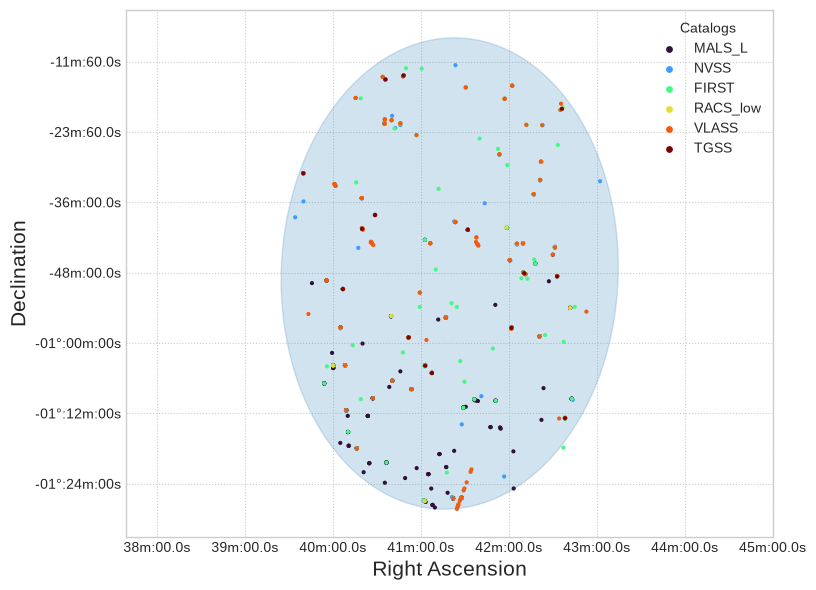

In [160]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.ticker import FuncFormatter

# =========================================================================
# 1. CELESTIAL FORMATTING HELPERS (Converts raw degrees to clean ticks)
# =========================================================================
def format_ra(x, pos):
    """Converts RA degrees to HH:MM:SS or MM:SS depending on scale."""
    hours = (x % 360) / 15.0
    h = int(hours)
    m = int((hours - h) * 60)
    s = (hours - h - m/60.0) * 3600
    if h == 0 and m == 0:
        return f"{s:.1f}s"
    elif h == 0:
        return f"{m:02d}m:{s:04.1f}s"
    return f"{h:02d}h:{m:02d}m:{s:02.0f}s"

def format_dec(y, pos):
    """Converts Dec degrees to DD:MM:SS or MM:SS depending on scale."""
    sign = "+" if y >= 0 else "-"
    abs_y = abs(y)
    d = int(abs_y)
    m = int((abs_y - d) * 60)
    s = (abs_y - d - m/60.0) * 3600
    if d == 0 and m == 0:
        return f"{sign}{s:.1f}s"
    elif d == 0:
        return f"{sign}{m:02d}m:{s:04.1f}s"
    return f"{sign}{d:02d}°:{m:02d}m:{s:02.0f}s"

# [Insert your data loading block here that populates x_points, y_points, etc.]

# =========================================================================
# 2. EXTRACT DATA & CONFIG PLOT
# =========================================================================
center_x = ellipse['RAJ2000'][0]
center_y = ellipse['DEJ2000'][0]
semi_major = ellipse['Conf_95_SemiMajor'][0]
semi_minor = ellipse['Conf_95_SemiMinor'][0]
pos_angle = ellipse['Conf_95_PosAng'][0]

fig, ax = plt.subplots(figsize=(8, 6))

# Draw the 95% confidence region ellipse
fermi_ellipse = Ellipse(xy=(center_x, center_y), 
                        width=semi_major * 2, 
                        height=semi_minor * 2, 
                        angle=pos_angle, 
                        edgecolor=ASTRO_COLORS[1], 
                        facecolor=ASTRO_COLORS[1], 
                        alpha=0.2)
ax.add_patch(fermi_ellipse)

# Zoom view tightly around the target ellipse field
padding = semi_major * 1.5  
ax.set_xlim(center_x - padding, center_x + padding)
ax.set_ylim(center_y - padding, center_y + padding)

# Normalize colors and scatter catalog points
num_unique = len(catalog_to_id)
norm_colors = color_values / max(1, num_unique - 1) if num_unique > 1 else color_values
plt.scatter(x_points, y_points, s=4, c=norm_colors, cmap='turbo', zorder=2)

# =========================================================================
# 3. APPLY TICK SYSTEM INTERCEPT
# =========================================================================
ax.xaxis.set_major_formatter(FuncFormatter(format_ra))
ax.yaxis.set_major_formatter(FuncFormatter(format_dec))

# ---- CATEGORICAL CATALOG LEGEND ----
legend_handles = []
for name, idx in catalog_to_id.items():
    name = name 
    val = idx / (num_unique - 1) if num_unique > 1 else 0.0
    color = plt.cm.turbo(val)
    handle = ax.scatter([], [], c=[color], label=name, s=15)
    legend_handles.append(handle)

ax.legend(handles=legend_handles, title="Catalogs", loc="upper right", )

# Set clean scientific labels and formatting styles
ax.set_aspect('equal', 'datalim')
ax.set_xlabel('Right Ascension', size =15)
ax.set_ylabel('Declination', size=15)
ax.grid(True, linestyle=':', alpha=1)
plt.tight_layout()
plt.savefig('fermi_ellipse.png', dpi=300, bbox_inches='tight')
plt.show()


In [88]:
# % should show an example of a nway match


In [22]:
fermi_source_path = glob.glob(catalog_fermi_nway+'/14/4FGL J1029.4-0828*.fits')[0]

In [23]:
bay_table_flux_prior = QTable.read(fermi_source_path, format='fits')

In [24]:
set(bay_table_flux_prior['match_flag'])

{np.int64(0), np.int64(1)}

In [92]:
bay_table_flux_prior[bay_table_flux_prior['match_flag']==0]

RACS_low,WISE,VLASS,Separation_FERMI_RACS_low,Separation_FERMI_WISE,Separation_FERMI_VLASS,Separation_RACS_low_WISE,Separation_RACS_low_VLASS,Separation_WISE_VLASS,Separation_max,ncat,dist_bayesfactor_uncorrected,dist_bayesfactor,dist_post,bias_RACS_low_spectral_index,bias_RACS_low_FluxRatio,bias_RACS_low_total_flux,bias_VLASS_spectral_index,bias_VLASS_Ftot,bias_VLASS_FluxRatio,p_single,match_flag,prob_has_match,prob_this_match,FERMI_Source_Name,FERMI_DataRelease,FERMI_RA,FERMI_DEC,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_ASSOC_4FGL,FERMI_TEVCAT_FLAG,FERMI_CLASS1,FERMI_ASSOC1,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_SBID,FERMI_n_gauss,FERMI_s_code,FERMI_CompId,FERMI_IslId,FERMI_DupFlag,FERMI_QualFlag,FERMI_MainSample,FERMI_pos_err,FERMI_ID,RACS_low_DataRelease,RACS_low_RA,RACS_low_DEC,RACS_low_Conf_95_SemiMajor,RACS_low_Conf_95_SemiMinor,RACS_low_Conf_95_PosAng,RACS_low_ROI_num,RACS_low_Flags,RACS_low_Indexes,RACS_low_catalog_names,RACS_low_source_name,RACS_low_Source_ID,RACS_low_Tile_ID,RACS_low_SBID,RACS_low_Obs_Start_Time,RACS_low_n_gauss,RACS_low_ra_mean_e,RACS_low_dec_mean_e,RACS_low_total_flux,RACS_low_E_Total_flux_Source_PyBDSF,RACS_low_total_flux_e,RACS_low_peak_flux,RACS_low_peak_flux_e,RACS_low_maj,RACS_low_maj_e,RACS_low_min,RACS_low_min_e,RACS_low_pa,RACS_low_pa_e,RACS_low_dc_maj,RACS_low_dc_maj_e,RACS_low_dc_min,RACS_low_dc_min_e,RACS_low_dc_pa,RACS_low_dc_pa_e,RACS_low_s_code,RACS_low_Separation_Tile_Centre,RACS_low_Noise,RACS_low_Gal_lon,RACS_low_Gal_lat,RACS_low_Flag_Close,RACS_low_ref_freq,RACS_low_FluxRatio,RACS_low_radio_flux_name,RACS_low_spectral_index,RACS_low__catalog_base_name,RACS_low__ra_key,RACS_low__dec_key,RACS_low__maj_key,RACS_low__flux_key,RACS_low_CompId,RACS_low_IslId,RACS_low_DupFlag,RACS_low_QualFlag,RACS_low_MainSample,RACS_low_pos_err,WISE_DataRelease,WISE_Conf_95_SemiMajor,WISE_Conf_95_SemiMinor,WISE_Conf_95_PosAng,WISE_ROI_num,WISE_Flags,WISE_Indexes,WISE_catalog_names,WISE_SBID,WISE_n_gauss,WISE_s_code,WISE_radio_flux_name,WISE__catalog_base_name,WISE__ra_key,WISE__dec_key,WISE__maj_key,WISE__flux_key,WISE_CompId,WISE_IslId,WISE_DupFlag,WISE_QualFlag,WISE_MainSample,WISE_designation,WISE_RA,WISE_DEC,WISE_sigra,WISE_sigdec,WISE_sigradec,WISE_glon,WISE_glat,WISE_elon,WISE_elat,WISE_wx,WISE_wy,WISE_cntr,WISE_source_id,WISE_coadd_id,WISE_src,WISE_w1mpro,WISE_w1sigmpro,WISE_w1snr,WISE_w1rchi2,WISE_w2mpro,WISE_w2sigmpro,WISE_w2snr,WISE_w2rchi2,WISE_w3mpro,WISE_w3sigmpro,WISE_w3snr,WISE_w3rchi2,WISE_w4mpro,WISE_w4sigmpro,WISE_w4snr,WISE_w4rchi2,WISE_rchi2,WISE_nb,WISE_na,WISE_w1sat,WISE_w2sat,WISE_w3sat,WISE_w4sat,WISE_satnum,WISE_ra_pm,WISE_dec_pm,WISE_sigra_pm,WISE_sigdec_pm,WISE_sigradec_pm,WISE_pmra,WISE_sigpmra,WISE_pmdec,WISE_sigpmdec,WISE_w1rchi2_pm,WISE_w2rchi2_pm,WISE_w3rchi2_pm,WISE_w4rchi2_pm,WISE_rchi2_pm,WISE_pmcode,WISE_cc_flags,WISE_rel,WISE_ext_flg,WISE_var_flg,WISE_ph_qual,WISE_det_bit,WISE_moon_lev,WISE_w1nm,WISE_w1m,WISE_w2nm,WISE_w2m,WISE_w3nm,WISE_w3m,WISE_w4nm,

In [93]:
bay_table_flux_prior_ellipse = bay_table_flux_prior[bay_table_flux_prior['match_flag'] ==1]
max_prob_has_match = np.max(bay_table_flux_prior_ellipse['prob_has_match'])
bay_table_flux_prior_ellipse = bay_table_flux_prior_ellipse[bay_table_flux_prior_ellipse['prob_has_match'] ==max_prob_has_match]
index_max_prob = np.argmax(bay_table_flux_prior_ellipse['prob_this_match'])
print(index_max_prob)
bay_table_flux_prior_ellipse = bay_table_flux_prior_ellipse[index_max_prob]

0


In [107]:
angle=90 - bay_table_flux_prior_ellipse['FERMI_Conf_95_PosAng']
angle

np.float32(132.12)

In [106]:
angle= bay_table_flux_prior_ellipse['FERMI_Conf_95_PosAng']
angle

np.float32(-42.12)

['RACS_low', 'WISE', 'VLASS']
RACS_low


/lustre/aoc/observers/nm-16041/antonio/USSCataloging/.pixi/envs/default/lib/python3.12/site-packages/numpy/_core/shape_base.py:61: UserWarning: Warning: converting a masked element to nan.
  result = asanyarray(arys[0])
/lustre/aoc/observers/nm-16041/antonio/USSCataloging/.pixi/envs/default/lib/python3.12/site-packages/numpy/ma/core.py:2885: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


WISE
VLASS


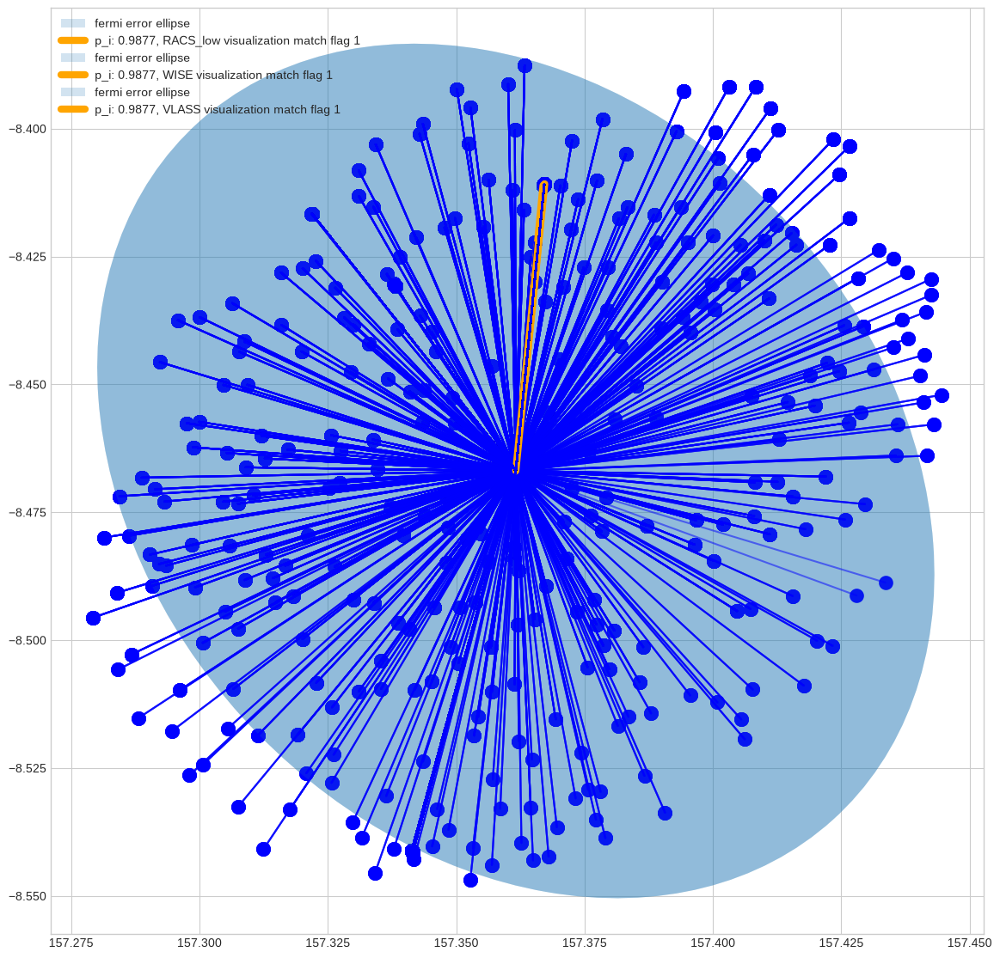

<Figure size 640x480 with 0 Axes>

In [108]:
# dont have to call the fermi ra and j like this since all the sources wil have same but it doesnt matter
bay_table_flux_prior_ellipse = bay_table_flux_prior[0]
raw_fermi_angle = bay_table_flux_prior_ellipse['FERMI_Conf_95_PosAng']
matplotlib_angle = -raw_fermi_angle
unique_names =[]
for name in bay_table_flux_prior_ellipse.colnames:
    if 'Separation' in name:
        break
    unique_names.append(name)
print(unique_names)
# position plot of the actual positions 
fig, ax = plt.subplots(figsize=(14,14))
# scatter the fermi ra and dec
# ax.scatter(bay_step_2['FERMI_RA'], bay_step_2['FERMI_RA'])
ellipse = patches.Ellipse((bay_table_flux_prior_ellipse['FERMI_RA'], bay_table_flux_prior_ellipse['FERMI_DEC']),
                          bay_table_flux_prior_ellipse['FERMI_Conf_95_SemiMajor']*2, bay_table_flux_prior_ellipse['FERMI_Conf_95_SemiMinor']*2,
                          angle=matplotlib_angle, alpha=0.2, label='fermi error ellipse')

for index in range(len(unique_names)):
    ax.add_patch(ellipse)
    name= unique_names[index]
    print(name)
    for index, source in enumerate(bay_table_flux_prior):
        if source['match_flag'] == 0:
                ax.plot([source['FERMI_RA'], source[name+'_RA']],[source['FERMI_DEC'], source[name+'_DEC']],
                        color='blue', alpha=0.5)
        if source['match_flag'] == 1:
                ax.plot([source['FERMI_RA'], source[name+'_RA']],[source['FERMI_DEC'], source[name+'_DEC']],
                        color='orange',  linewidth=6, label=f'p_i: {source['prob_this_match']:.4f}, {name} visualization match flag 1')
            
        ax.scatter([source['FERMI_RA'], source[name+'_RA']],[source['FERMI_DEC'], source[name+'_DEC']],
                        color='blue',  linewidth=6)
            
        # elif source['match_flag'] == 2:
            #     ax.plot([source['FERMI_RA'], source['MALS_L_RA'] ],[source['FERMI_DEC'], source['MALS_L_DEC']], color='black')
    ax.legend(loc='best')
plt.show()
    # plt.title(f'Ellipse: {bay_table_flux_prior[0]['FERMI_Source_Name']} ALL matching w/Various prior')
plt.savefig(f'{name}_nway_match.png', dpi=300)
# plt.savefig('dist_match_4FGL_J0041.3-0048_bay.png')
# the highest prob source! 


Populating panel 1/3 for catalog: WISE


/lustre/aoc/observers/nm-16041/antonio/USSCataloging/.pixi/envs/default/lib/python3.12/site-packages/numpy/_core/shape_base.py:61: UserWarning: Warning: converting a masked element to nan.
  result = asanyarray(arys[0])
/lustre/aoc/observers/nm-16041/antonio/USSCataloging/.pixi/envs/default/lib/python3.12/site-packages/numpy/ma/core.py:2885: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


Populating panel 2/3 for catalog: RACS_low
Populating panel 3/3 for catalog: VLASS


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


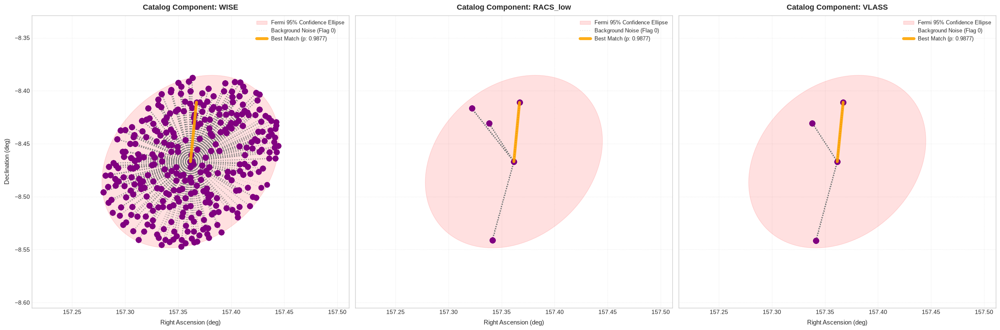

Triple canvas matrix completed and shown with consistent celestial alignment.


In [154]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================================================================
# 1. FIXED ASTRONOMICAL POSITION ANGLE TO MATPLOTLIB ROTATION DEGREES
# =========================================================================
bay_table_flux_prior_ellipse = bay_table_flux_prior[0]

raw_fermi_angle = bay_table_flux_prior_ellipse['FERMI_Conf_95_PosAng']
matplotlib_angle = -raw_fermi_angle

# Shared viewing boundary window scalar calculations
padding = bay_table_flux_prior_ellipse['FERMI_Conf_95_SemiMajor'] * 1.5
f_center_ra = bay_table_flux_prior_ellipse['FERMI_RA']
f_center_dec = bay_table_flux_prior_ellipse['FERMI_DEC']

ellipse_width = bay_table_flux_prior_ellipse['FERMI_Conf_95_SemiMajor'] * 2
ellipse_height = bay_table_flux_prior_ellipse['FERMI_Conf_95_SemiMinor'] * 2

# Define explicitly the 3 catalogs for our 3 side-by-side subplots
target_catalogs = ['WISE', 'RACS_low', 'VLASS']

# Helper function to dynamically calculate active catalogs in a given data row
def get_combination_color(source):
    active_catalogs = []
    for cat in ['WISE', 'RACS_low', 'VLASS']:
        ra_col = f"{cat}_RA"
        if ra_col in source.colnames and source[ra_col] is not None and not np.isnan(source[ra_col]):
            active_catalogs.append(cat)
            
    active_catalogs = sorted(active_catalogs)
    
    if active_catalogs == ['RACS_low', 'VLASS', 'WISE']:
        return 'purple', 'WISE + RACS + VLASS (All 3)'
    elif active_catalogs == ['VLASS', 'WISE']:
        return 'cyan', 'WISE + VLASS'
    elif active_catalogs == ['RACS_low', 'WISE']:
        return 'magenta', 'WISE + RACS'
    elif active_catalogs == ['WISE']:
        return 'green', 'WISE Only'
    elif active_catalogs == ['RACS_low', 'VLASS']:
        return 'brown', 'RACS + VLASS'
    elif active_catalogs == ['VLASS']:
        return 'olive', 'VLASS Only'
    elif active_catalogs == ['RACS_low']:
        return 'teal', 'RACS Only'
    else:
        return 'blue', 'Other / Background Match'

# =========================================================================
# 2. GENERATE TRIPLE SUBPLOT MAP (1 ROW, 3 COLUMNS)
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharey=True)

# Step through each of our 3 target catalog subplots
for idx, name in enumerate(target_catalogs):
    ax = axes[idx]
    print(f"Populating panel {idx+1}/3 for catalog: {name}")
    
    # Passing purely scalar numeric parameters to the Ellipse patch
    ellipse = patches.Ellipse(
        (f_center_ra, f_center_dec), 
        width=ellipse_width, 
        height=ellipse_height, 
        angle=matplotlib_angle, 
        edgecolor='red',
        facecolor='red',
        alpha=0.12, 
        label='Fermi 95% Confidence Ellipse'
    )
    ax.add_patch(ellipse)
    
    seen_legend_labels = set()
    
    # Process vector positions specifically for this panel's active catalog footprint
    for source in bay_table_flux_prior:
        combo_color, combo_label = get_combination_color(source)
        f_ra, f_dec = source['FERMI_RA'], source['FERMI_DEC']
        
        ra_col = f"{name}_RA"
        dec_col = f"{name}_DEC"
        
        if ra_col in source.colnames and source[ra_col] is not None and not np.isnan(source[ra_col]):
            cat_ra = source[ra_col]
            cat_dec = source[dec_col]
            
            if source['match_flag'] == 0:
                lbl = "Background Noise (Flag 0)" if "Flag 0" not in seen_legend_labels else ""
                seen_legend_labels.add("Flag 0")
                ax.plot([f_ra, cat_ra], [f_dec, cat_dec], color='grey', alpha=0.2, linestyle=':', label=lbl)
                
            elif source['match_flag'] == 1:
                lbl = f"Best Match (p: {source['prob_this_match']:.4f})" if "Best Match" not in seen_legend_labels else ""
                seen_legend_labels.add("Best Match")
                
                # Plot the connection line as standard bold orange
                ax.plot([f_ra, cat_ra], [f_dec, cat_dec], color='orange', zorder=10, linewidth=5, alpha=0.9, label=lbl)
            
            # Place individual target coordinate scatter markers
            ax.scatter([f_ra, cat_ra], [f_dec, cat_dec], color=combo_color, s=80, zorder=5)

    # =========================================================================
    # 3. PANEL VISUAL STYLING AND CELESTIAL FORMATTING
    # =========================================================================
    ax.invert_xaxis()  # Right Ascension increases to the left across real sky maps
    
    # THE FIX: Use standard [low, high] ordering. 
    # ax.invert_xaxis() will safely handle flipping the orientation on the screen.
    ax.set_xlim(f_center_ra - padding, f_center_ra + padding)
    ax.set_ylim(f_center_dec - padding, f_center_dec + padding)
    
    ax.set_aspect('equal', 'datalim')
    ax.set_xlabel('Right Ascension (deg)', fontsize=11, labelpad=8)
    if idx == 0:
        ax.set_ylabel('Declination (deg)', fontsize=11, labelpad=8)
        
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_title(f"Catalog Component: {name}", fontsize=13, weight='bold', pad=10)
    ax.legend(loc='upper right', framealpha=0.85, facecolor='whitesmoke', fontsize=9)

# Master global overarching layout settings
src_title = bay_table_flux_prior_ellipse.get('FERMI_Source_Name', 'Target Field')
# plt.suptitle(f"Multi-Catalog Tri-Panel Association Map\nBaseline Field Target: {src_title}", fontsize=16, weight='bold', y=1.02)

plt.tight_layout()
plt.savefig('triple_panel_catalog_match.png', dpi=300, bbox_inches='tight')
plt.show()

print("Triple canvas matrix completed and shown with consistent celestial alignment.")


## Results

In [ ]:
# wise comparision 

In [11]:
print(top_match_unassociated_sources.colnames)

['WISE', 'Separation_FERMI_WISE', 'Separation_max', 'ncat', 'dist_bayesfactor_uncorrected', 'dist_bayesfactor', 'dist_post', 'p_single', 'match_flag', 'prob_has_match', 'prob_this_match', 'Source_Name', 'DataRelease', 'RA', 'DEC', 'GLON', 'GLAT', 'Conf_68_SemiMajor', 'Conf_68_SemiMinor', 'Conf_68_PosAng', 'Conf_95_SemiMajor', 'Conf_95_SemiMinor', 'Conf_95_PosAng', 'ROI_num', 'Signif_Avg', 'Pivot_Energy', 'Flux1000', 'Unc_Flux1000', 'Energy_Flux100', 'Unc_Energy_Flux100', 'SpectrumType', 'PL_Flux_Density', 'Unc_PL_Flux_Density', 'PL_Index', 'Unc_PL_Index', 'LP_Flux_Density', 'Unc_LP_Flux_Density', 'LP_Index', 'Unc_LP_Index', 'LP_beta', 'Unc_LP_beta', 'LP_SigCurv', 'LP_EPeak', 'Unc_LP_EPeak', 'PLEC_Flux_Density', 'Unc_PLEC_Flux_Density', 'PLEC_IndexS', 'Unc_PLEC_IndexS', 'PLEC_ExpfactorS', 'Unc_PLEC_ExpfactorS', 'PLEC_Exp_Index', 'PLEC_SigCurv', 'PLEC_EPeak', 'Unc_PLEC_EPeak', 'Npred', 'Flux_Band', 'Unc_Flux_Band', 'nuFnu_Band', 'Sqrt_TS_Band', 'Variability_Index', 'Frac_Variability', 'U

In [9]:
top_match_unassociated_sources['WISE_W1_W3_color'] = top_match_unassociated_sources['WISE_w1mpro'] - top_match_unassociated_sources['WISE_w3mpro']


In [ ]:
from matplotlib.colors import LinearSegmentedColormap
# color = [0,1,2]
probability_threshold = 0.8
cmap = ['red', 'green', 'blue', 'gray']
color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3  for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
alphas =  [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx]  >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar')
           else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx]  >=probability_threshold and color_key == ('other')
           else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]

(-2.0, 2.0)

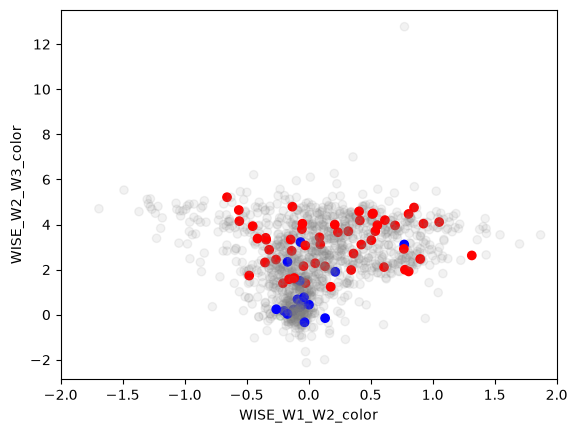

In [33]:

plt.scatter(top_match_unassociated_sources['WISE_W1_W2_color'], top_match_unassociated_sources['WISE_W2_W3_color'], c = colors, cmap=my_continuous_cmap, alpha =alphas)
plt.xlabel('WISE_W1_W2_color')
plt.ylabel('WISE_W2_W3_color')
plt.xlim(-2, 2)

(-1.0, 2.0)

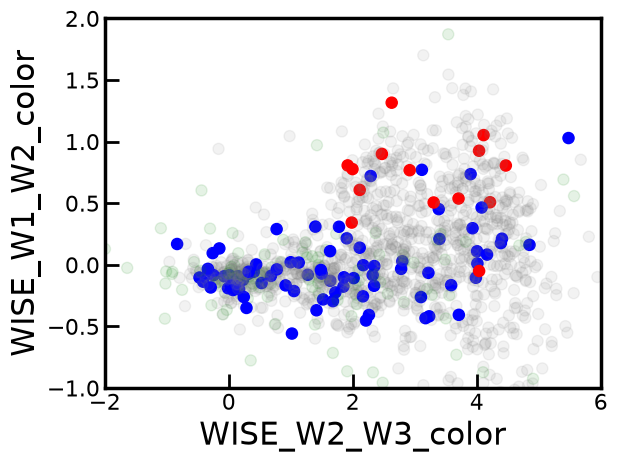

In [24]:

plt.scatter( top_match_unassociated_sources['WISE_W2_W3_color'],  top_match_unassociated_sources['WISE_W1_W2_color'],c = colors, cmap=my_continuous_cmap, alpha =alphas)
plt.xlabel('WISE_W2_W3_color')
plt.ylabel('WISE_W1_W2_color')
plt.xlim(-2, 6)
plt.ylim(-1, 2)


Text(0, 0.5, 'WISE_W3_W4_color')

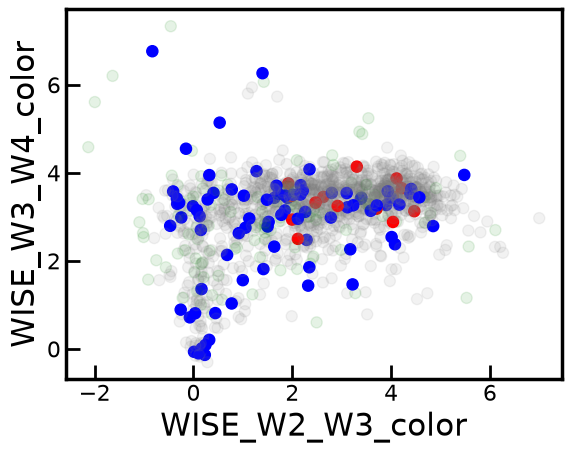

In [25]:
plt.scatter(top_match_unassociated_sources['WISE_W2_W3_color'], top_match_unassociated_sources['WISE_W3_W4_color'],  c = colors, cmap=my_continuous_cmap, alpha =alphas)
plt.xlabel('WISE_W2_W3_color')
plt.ylabel('WISE_W3_W4_color')

Text(0.5, 0, 'WISE_W3_W4_color')

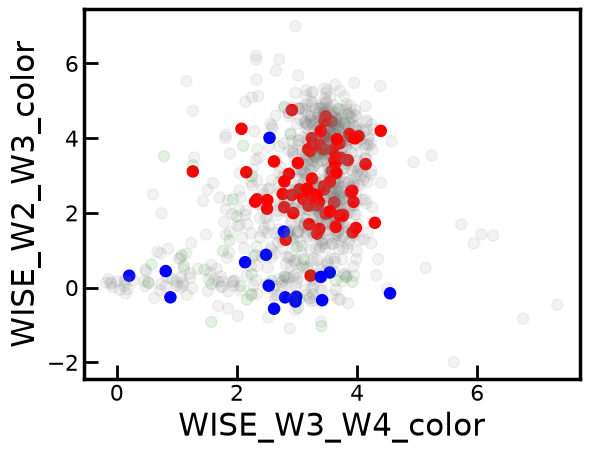

In [17]:
plt.scatter( top_match_unassociated_sources['WISE_W3_W4_color'], top_match_unassociated_sources['WISE_W2_W3_color'],  c = colors, cmap=my_continuous_cmap, alpha =alphas)
plt.ylabel('WISE_W2_W3_color')
plt.xlabel('WISE_W3_W4_color')

Text(0, 0.5, 'WISE_W2_W4_color')

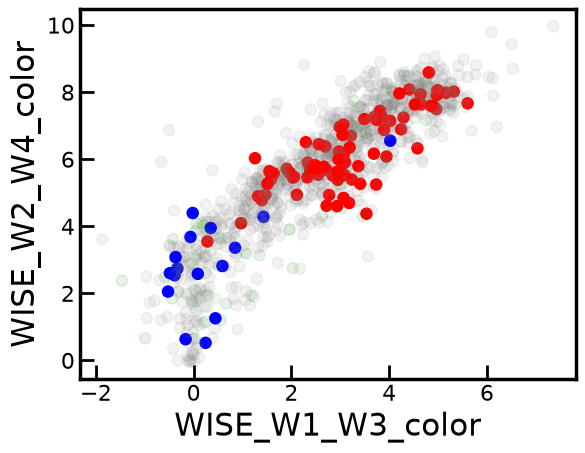

In [18]:
plt.scatter(top_match_unassociated_sources['WISE_W1_W3_color'], top_match_unassociated_sources['WISE_W2_W4_color'],  c = colors, cmap=my_continuous_cmap, alpha =alphas)
plt.xlabel('WISE_W1_W3_color')
plt.ylabel('WISE_W2_W4_color')

Text(0.02, 0.5, 'WISE_W1_W2_color')

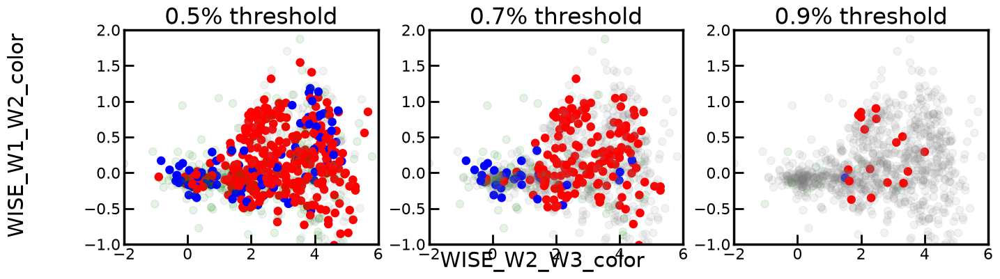

In [21]:
# wise grouped plots 0.5, 0.7 , 0.9
thresholds = [0.5, 0.7, 0.9]
wise_x_axis = 'WISE_W2_W3_color'
wise_y_axis = 'WISE_W1_W2_color'

colors_thresholds = []
alphas_thresholds = []
for threshold in thresholds:
    # color = [0,1,2]
    probability_threshold = threshold
    cmap = ['red', 'green', 'blue', 'gray']
    color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
    my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
    colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3  for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    alphas =  [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx]  >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar')
               else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx]  >=probability_threshold and color_key == ('other')
               else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)
    

fig, axs = plt.subplots(1, 3, figsize=(16,4))
axs[0].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis],  c = colors_thresholds[0], cmap=my_continuous_cmap, alpha =alphas_thresholds[0])
axs[0].set_title(f'{str(thresholds[0])}% threshold') 
axs[0].set_xlim(-2, 6)
axs[0].set_ylim(-1, 2)

axs[1].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis],  c = colors_thresholds[1], cmap=my_continuous_cmap, alpha =alphas_thresholds[1])
axs[1].set_title(f'{str(thresholds[1])}% threshold') 
axs[1].set_xlim(-2, 6)
axs[1].set_ylim(-1, 2)

axs[2].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis],  c = colors_thresholds[2], cmap=my_continuous_cmap, alpha =alphas_thresholds[2])
axs[2].set_title(f'{str(thresholds[2])}% threshold') 
axs[2].set_xlim(-2, 6)
axs[2].set_ylim(-1, 2)


fig.supxlabel(wise_x_axis)
fig.supylabel(wise_y_axis)
    
    
        


Text(0.02, 0.5, 'WISE_W1_W2_color')

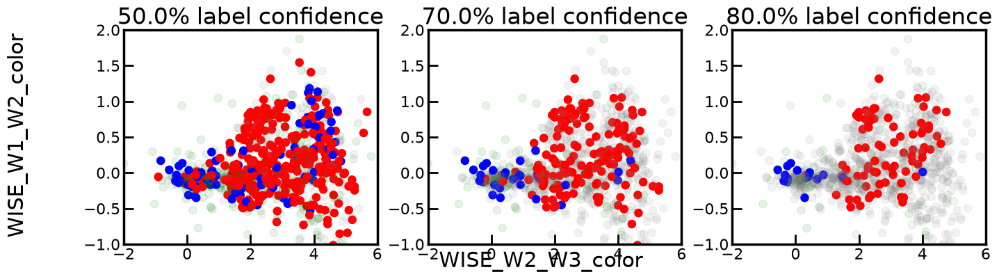

In [22]:
# wise grouped plots 0.5, 0.7 , 0.9
thresholds = [0.5, 0.7, 0.8]
wise_x_axis = 'WISE_W2_W3_color'
wise_y_axis = 'WISE_W1_W2_color'

colors_thresholds = []
alphas_thresholds = []
for threshold in thresholds:
    # color = [0,1,2]
    probability_threshold = threshold
    cmap = ['red', 'green', 'blue', 'gray']
    color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
    my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
    colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3  for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    alphas =  [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx]  >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar')
               else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx]  >=probability_threshold and color_key == ('other')
               else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)
    

fig, axs = plt.subplots(1, 3, figsize=(16,4))
axs[0].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis],  c = colors_thresholds[0], cmap=my_continuous_cmap, alpha =alphas_thresholds[0])
axs[0].set_title(f'{str(thresholds[0]*100)}% label confidence') 
axs[0].set_xlim(-2, 6)
axs[0].set_ylim(-1, 2)

axs[1].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis],  c = colors_thresholds[1], cmap=my_continuous_cmap, alpha =alphas_thresholds[1])
axs[1].set_title(f'{str(thresholds[1]*100)}% label confidence') 
axs[1].set_xlim(-2, 6)
axs[1].set_ylim(-1, 2)

axs[2].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis],  c = colors_thresholds[2], cmap=my_continuous_cmap, alpha =alphas_thresholds[2])
axs[2].set_title(f'{str(thresholds[2]*100)}% label confidence') 
axs[2].set_xlim(-2, 6)
axs[2].set_ylim(-1, 2)


fig.supxlabel(wise_x_axis)
fig.supylabel(wise_y_axis)
    
    
        


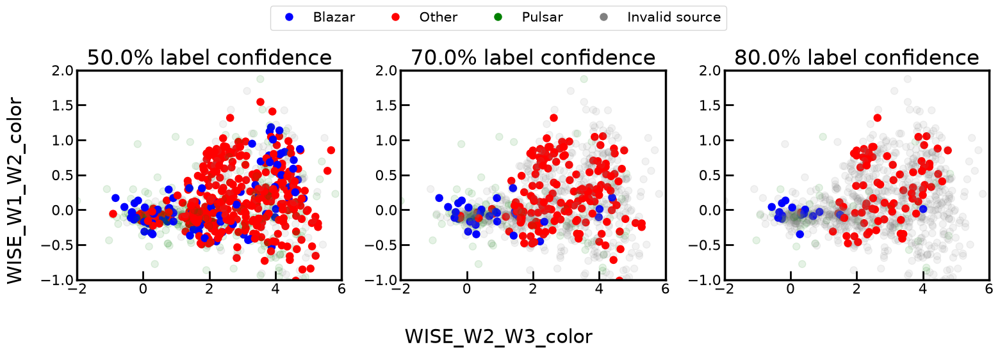

In [23]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D  # Imported for custom legend handles

# wise grouped plots
0.5, 0.7 , 0.9
thresholds = [0.5, 0.7, 0.8]
wise_x_axis = 'WISE_W2_W3_color'
wise_y_axis = 'WISE_W1_W2_color'

colors_thresholds = []
alphas_thresholds = []

for threshold in thresholds:
    # color = [0,1,2]
    probability_threshold = threshold
    cmap = ['red', 'green', 'blue', 'gray']
    color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
    my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
    
    colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    alphas = [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar') else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and color_key == ('other') else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    
    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)

# Adjusted figsize and added layout constraint to fit the legend nicely
fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout='tight')

# Subplot 0
axs[0].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[0], cmap=my_continuous_cmap, alpha =alphas_thresholds[0])
axs[0].set_title(f'{str(thresholds[0]*100)}% label confidence')
axs[0].set_xlim(-2, 6)
axs[0].set_ylim(-1, 2)

# Subplot 1
axs[1].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[1], cmap=my_continuous_cmap, alpha =alphas_thresholds[1])
axs[1].set_title(f'{str(thresholds[1]*100)}% label confidence')
axs[1].set_xlim(-2, 6)
axs[1].set_ylim(-1, 2)

# Subplot 2
axs[2].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[2], cmap=my_continuous_cmap, alpha =alphas_thresholds[2])
axs[2].set_title(f'{str(thresholds[2]*100)}% label confidence')
axs[2].set_xlim(-2, 6)
axs[2].set_ylim(-1, 2)

# --- CUSTOM LEGEND IMPLEMENTATION ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Blazar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Pulsar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Invalid source')
]
# Places a single shared legend at the top center of the entire figure
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.10), fontsize=15)
fig.supxlabel(wise_x_axis)
fig.supylabel(wise_y_axis)
plt.show()


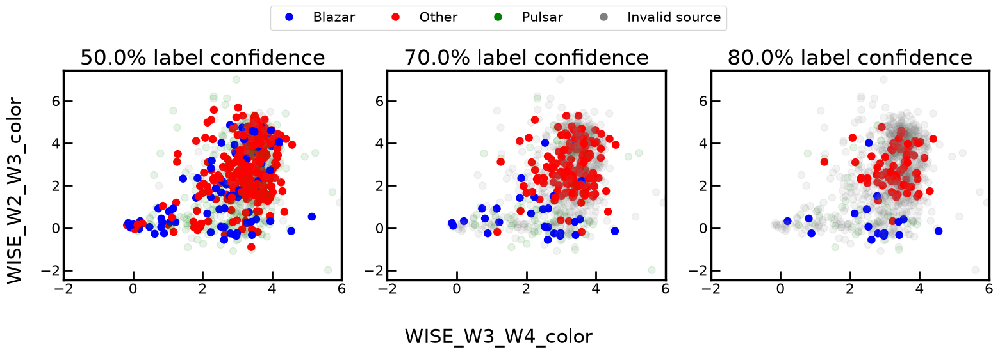

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D  # Imported for custom legend handles

# wise grouped plots
0.5, 0.7 , 0.9
thresholds = [0.5, 0.7, 0.8]
wise_x_axis = 'WISE_W3_W4_color'
wise_y_axis = 'WISE_W2_W3_color'

colors_thresholds = []
alphas_thresholds = []

for threshold in thresholds:
    # color = [0,1,2]
    probability_threshold = threshold
    cmap = ['red', 'green', 'blue', 'gray']
    color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
    my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
    
    colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    alphas = [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar') else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and color_key == ('other') else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    
    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)

# Adjusted figsize and added layout constraint to fit the legend nicely
fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout='tight')

# Subplot 0
axs[0].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[0], cmap=my_continuous_cmap, alpha =alphas_thresholds[0])
axs[0].set_title(f'{str(thresholds[0]*100)}% label confidence')
axs[0].set_xlim(-2, 6)
# axs[0].set_ylim(-1, 2)

# Subplot 1
axs[1].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[1], cmap=my_continuous_cmap, alpha =alphas_thresholds[1])
axs[1].set_title(f'{str(thresholds[1]*100)}% label confidence')
axs[1].set_xlim(-2, 6)
# axs[1].set_ylim(-1, 2)

# Subplot 2
axs[2].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[2], cmap=my_continuous_cmap, alpha =alphas_thresholds[2])
axs[2].set_title(f'{str(thresholds[2]*100)}% label confidence')
axs[2].set_xlim(-2, 6)
# axs[2].set_ylim(-1, 2)

# --- CUSTOM LEGEND IMPLEMENTATION ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Blazar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Pulsar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Invalid source')
]

# Places a single shared legend at the top center of the entire figure
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.10), fontsize=15)

fig.supxlabel(wise_x_axis)
fig.supylabel(wise_y_axis)

plt.show()


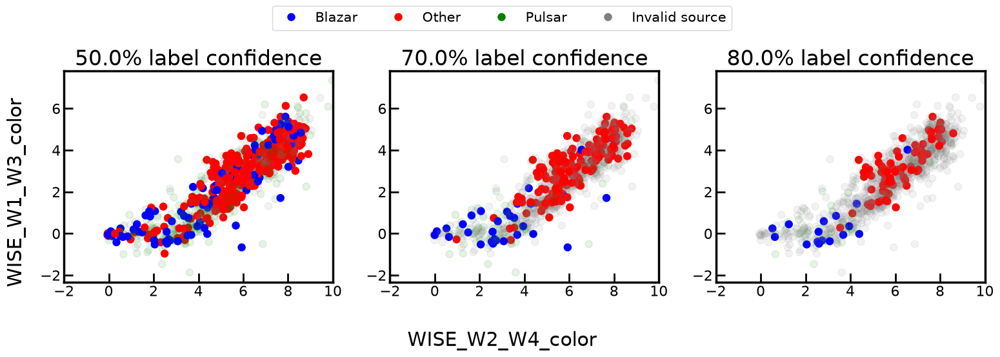

In [25]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D  # Imported for custom legend handles

# wise grouped plots
0.5, 0.7 , 0.9
thresholds = [0.5, 0.7, 0.8]
wise_x_axis = 'WISE_W2_W4_color'
wise_y_axis = 'WISE_W1_W3_color'


colors_thresholds = []
alphas_thresholds = []

for threshold in thresholds:
    # color = [0,1,2]
    probability_threshold = threshold
    cmap = ['red', 'green', 'blue', 'gray']
    color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
    my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
    
    colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    alphas = [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar') else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and color_key == ('other') else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    
    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)

# Adjusted figsize and added layout constraint to fit the legend nicely
fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout='tight')

# Subplot 0
axs[0].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[0], cmap=my_continuous_cmap, alpha =alphas_thresholds[0])
axs[0].set_title(f'{str(thresholds[0]*100)}% label confidence')
axs[0].set_xlim(-2, 10)
# axs[0].set_ylim(-1, 2)

# Subplot 1
axs[1].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[1], cmap=my_continuous_cmap, alpha =alphas_thresholds[1])
axs[1].set_title(f'{str(thresholds[1]*100)}% label confidence')
axs[1].set_xlim(-2, 10)
# axs[1].set_ylim(-1, 2)

# Subplot 2
axs[2].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[2], cmap=my_continuous_cmap, alpha =alphas_thresholds[2])
axs[2].set_title(f'{str(thresholds[2]*100)}% label confidence')
axs[2].set_xlim(-2, 10)
# axs[2].set_ylim(-1, 2)

# --- CUSTOM LEGEND IMPLEMENTATION ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Blazar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Pulsar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Invalid source')
]

# Places a single shared legend at the top center of the entire figure
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.10), fontsize=15)

fig.supxlabel(wise_x_axis)
fig.supylabel(wise_y_axis)

plt.show()


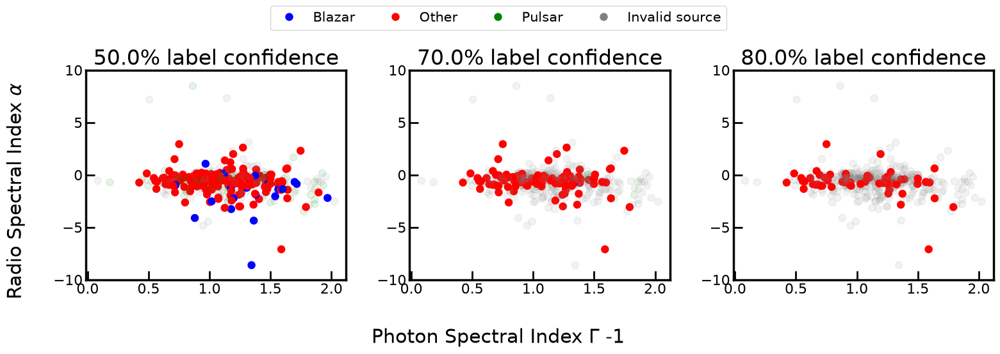

In [26]:
# photon idx vs radio idx 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D  # Imported for custom legend handles

# wise grouped plots
0.5, 0.7 , 0.9
thresholds = [0.5, 0.7, 0.8]


colors_thresholds = []
alphas_thresholds = []

for threshold in thresholds:
    # color = [0,1,2]
    probability_threshold = threshold
    cmap = ['red', 'green', 'blue', 'gray']
    color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
    my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
    
    colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    alphas = [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar') else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and color_key == ('other') else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    
    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)

# Adjusted figsize and added layout constraint to fit the legend nicely
fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout='tight')

# Subplot 0
axs[0].scatter( top_match_unassociated_sources['Photon_Index'], top_match_unassociated_sources['closest_spx_idx'], c = colors_thresholds[0], cmap=my_continuous_cmap, alpha =alphas_thresholds[0])
axs[0].set_title(f'{str(thresholds[0]*100)}% label confidence')
# axs[0].set_xlim(-2, 10)
axs[0].set_ylim(-10, 10)

# Subplot 1
axs[1].scatter( top_match_unassociated_sources['Photon_Index'], top_match_unassociated_sources['closest_spx_idx'], c = colors_thresholds[1], cmap=my_continuous_cmap, alpha =alphas_thresholds[1])
axs[1].set_title(f'{str(thresholds[1]*100)}% label confidence')
# axs[1].set_xlim(-2, 10)
axs[1].set_ylim(-10, 10)

# Subplot 2
axs[2].scatter( top_match_unassociated_sources['Photon_Index'], top_match_unassociated_sources['closest_spx_idx'],c = colors_thresholds[2], cmap=my_continuous_cmap, alpha =alphas_thresholds[2])
axs[2].set_title(f'{str(thresholds[2]*100)}% label confidence')
# axs[2].set_xlim(-2, 10)
axs[2].set_ylim(-10, 10)

# --- CUSTOM LEGEND IMPLEMENTATION ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Blazar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Pulsar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Invalid source')
]

# Places a single shared legend at the top center of the entire figure
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.10), fontsize=15)

fig.supxlabel(rf'Photon Spectral Index $\Gamma$ -1')
fig.supylabel(rf'Radio Spectral Index $\alpha$')

plt.show()


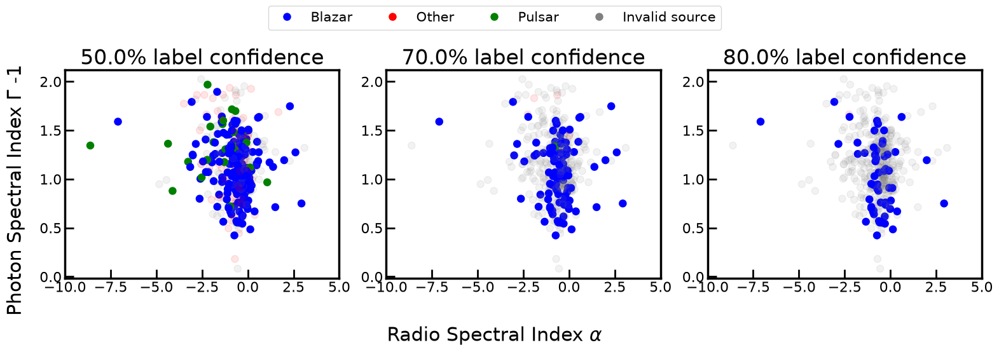

In [158]:
# photon idx vs radio idx 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D  # Imported for custom legend handles

# wise grouped plots
thresholds = [0.5, 0.7, 0.8]


colors_thresholds = []
alphas_thresholds = []

for threshold in thresholds:
    # color = [0,1,2]
    probability_threshold = threshold
    cmap = ['blue', 'red', 'green', 'gray']
    color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
    my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
    
    colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    alphas = [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar') else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and color_key == ('other') else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    
    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)

# Adjusted figsize and added layout constraint to fit the legend nicely
fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout='tight')

# Subplot 0
axs[0].scatter(top_match_unassociated_sources['closest_spx_idx'], top_match_unassociated_sources['Photon_Index'],  c = colors_thresholds[0], cmap=my_continuous_cmap, alpha =alphas_thresholds[0])
axs[0].set_title(f'{str(thresholds[0]*100)}% label confidence')
# axs[0].set_xlim(-2, 10)
axs[0].set_xlim(-10, 5)

# Subplot 1
axs[1].scatter(top_match_unassociated_sources['closest_spx_idx'], top_match_unassociated_sources['Photon_Index'], c = colors_thresholds[1], cmap=my_continuous_cmap, alpha =alphas_thresholds[1])
axs[1].set_title(f'{str(thresholds[1]*100)}% label confidence')
# axs[1].set_xlim(-2, 10)
axs[1].set_xlim(-10, 5)

# Subplot 2
axs[2].scatter(top_match_unassociated_sources['closest_spx_idx'], top_match_unassociated_sources['Photon_Index'], c = colors_thresholds[2], cmap=my_continuous_cmap, alpha =alphas_thresholds[2])
axs[2].set_title(f'{str(thresholds[2]*100)}% label confidence')
# axs[2].set_xlim(-2, 10)
axs[2].set_xlim(-10, 5)

# --- CUSTOM LEGEND IMPLEMENTATION ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Blazar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Pulsar'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Invalid source')
]

# Places a single shared legend at the top center of the entire figure
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.10), fontsize=15)

fig.supxlabel(rf'Radio Spectral Index $\alpha$')
fig.supylabel(rf'Photon Spectral Index $\Gamma$ -1')

plt.show()



In [ ]:
top_match_unassociated_sources[top_match_unassociated_sources]

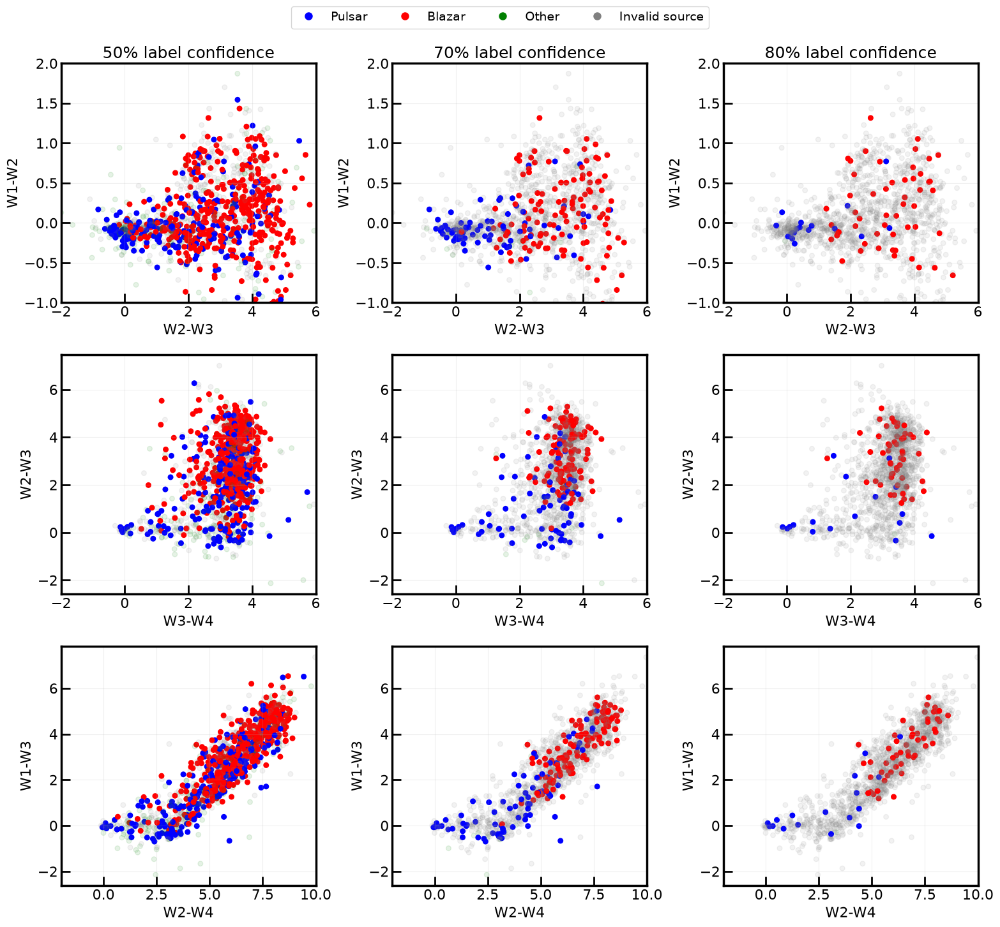

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


thresholds = [0.5, 0.7, 0.8]

# (x-axis, y-axis, x-limits, y-limits)
color_color_plots = [
    (
        'WISE_W2_W3_color',
        'WISE_W1_W2_color',
        (-2, 6),
        (-1, 2)
    ),
    (
        'WISE_W3_W4_color',
        'WISE_W2_W3_color',
        (-2, 6),
        None
    ),
    (
        'WISE_W2_W4_color',
        'WISE_W1_W3_color',
        (-2, 10),
        None
    )
]


# ============================================================
# CLASSIFICATION COLORS
# ============================================================

cmap = ['red', 'green', 'blue', 'gray']

color_map = {
    'blazar': 0,
    'other': 1,
    'pulsar': 2
}

my_continuous_cmap = LinearSegmentedColormap.from_list(
    "my_gradient",
    cmap)

colors_thresholds = []
alphas_thresholds = []

predicted_classes = top_match_unassociated_sources[
    'labels_3_top_class_pred'
]

for threshold in thresholds:

    colors = []
    alphas = []

    for source_idx, color_key in enumerate(predicted_classes):

        probability_column = (
            'labels_3_' + color_key + '_prob'
        )

        # IMPORTANT:
        # Astropy Table does NOT use .iloc
        probability = top_match_unassociated_sources[
            probability_column
        ][source_idx]

        if probability >= threshold:

            colors.append(color_map[color_key])

            if color_key == 'blazar':
                alphas.append(1.0)
            elif color_key == 'pulsar':
                alphas.append(1.0)
            elif color_key == 'other':
                alphas.append(0.1)
        else:
            colors.append(3)
            alphas.append(0.1)

    colors_thresholds.append(
        np.array(colors))

    alphas_thresholds.append(
        np.array(alphas))



fig, axs = plt.subplots(
    3,
    3,
    figsize=(16, 15)
)


# ============================================================
# LOOP THROUGH THE THREE COLOR-COLOR DIAGRAMS
# ============================================================

for row, (x_axis, y_axis, xlim, ylim) in enumerate(
    color_color_plots
):
    # split 
    first_color_y, second_color_y = y_axis.split('_')[1], y_axis.split('_')[2]

    first_color_x, second_color_x = x_axis.split('_')[1], x_axis.split('_')[2]

    # combine new label
    yaxis_title = first_color_y + '-' + second_color_y
    xaxis_title = first_color_x + '-' + second_color_x

    

    # Get data from Astropy Table
    x = np.asarray(
        top_match_unassociated_sources[x_axis],
        dtype=float)

    y = np.asarray(
        top_match_unassociated_sources[y_axis],
        dtype=float
    )


    for col, threshold in enumerate(thresholds):
        ax = axs[row, col]
        ax.scatter(
            x,
            y,
            c=colors_thresholds[col],
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds[col],
            s=30
        )

        ax.set_xlim(
            xlim[0],
            xlim[1]
        )

        if ylim is not None:

            ax.set_ylim(
                ylim[0],
                ylim[1]
            )

        if row == 0:
            ax.set_title(
                f'{threshold * 100:.0f}% label confidence',
                fontsize=18)
        ax.set_xlabel(
            xaxis_title,
            fontsize=16)

        ax.set_ylabel(
            yaxis_title,
            fontsize=16)
        ax.grid(
            True,
            alpha=0.2)


# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='blue',
        markersize=10,
        label='Pulsar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='red',
        markersize=10,
        label='Blazar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='green',
        markersize=10,
        label='Other'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='gray',
        markersize=10,
        label='Invalid source')
]


fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.980),
    fontsize=14
)




plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


output_filename = (
    'WISE_color_color_3x3_classification_confidence.png'
)

# fig.savefig(
#     output_filename,
#     dpi=300,
#     bbox_inches='tight'
# )


plt.show()

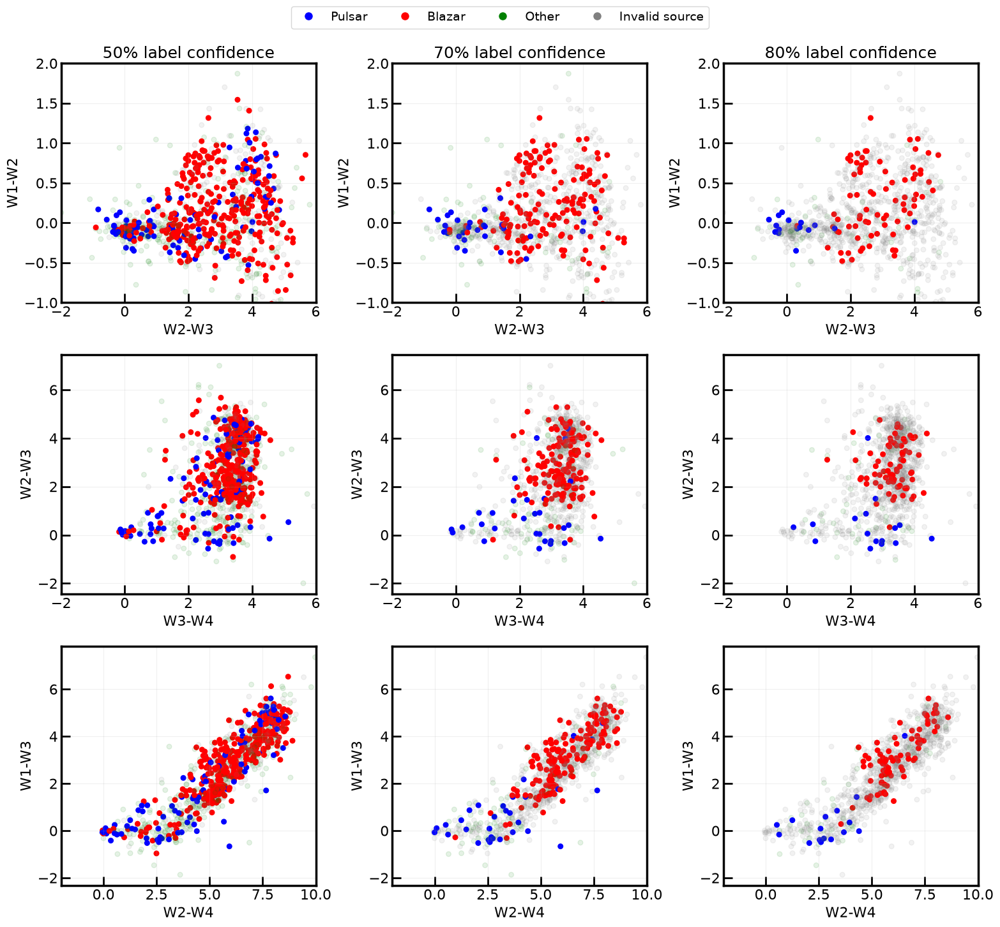

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


thresholds = [0.5, 0.7, 0.8]

# (x-axis, y-axis, x-limits, y-limits)
color_color_plots = [
    (
        'WISE_W2_W3_color',
        'WISE_W1_W2_color',
        (-2, 6),
        (-1, 2)
    ),
    (
        'WISE_W3_W4_color',
        'WISE_W2_W3_color',
        (-2, 6),
        None
    ),
    (
        'WISE_W2_W4_color',
        'WISE_W1_W3_color',
        (-2, 10),
        None
    )
]


# ============================================================
# CLASSIFICATION COLORS
# ============================================================

cmap = ['red', 'green', 'blue', 'gray']

color_map = {
    'blazar': 0,
    'other': 1,
    'pulsar': 2
}

my_continuous_cmap = LinearSegmentedColormap.from_list(
    "my_gradient",
    cmap)

colors_thresholds = []
alphas_thresholds = []

predicted_classes = top_match_unassociated_sources[
    'labels_3_top_class_pred'
]

for threshold in thresholds:

    colors = []
    alphas = []

    for source_idx, color_key in enumerate(predicted_classes):

        probability_column = (
            'labels_3_' + color_key + '_prob'
        )

        # IMPORTANT:
        # Astropy Table does NOT use .iloc
        probability = top_match_unassociated_sources[
            probability_column
        ][source_idx]

        if probability >= threshold:

            colors.append(color_map[color_key])

            if color_key == 'blazar':
                alphas.append(1.0)
            elif color_key == 'pulsar':
                alphas.append(1.0)
            elif color_key == 'other':
                alphas.append(0.1)
        else:
            colors.append(3)
            alphas.append(0.1)

    colors_thresholds.append(
        np.array(colors))

    alphas_thresholds.append(
        np.array(alphas))



fig, axs = plt.subplots(
    3,
    3,
    figsize=(16, 15)
)


# ============================================================
# LOOP THROUGH THE THREE COLOR-COLOR DIAGRAMS
# ============================================================

for row, (x_axis, y_axis, xlim, ylim) in enumerate(
    color_color_plots
):
    # split 
    first_color_y, second_color_y = y_axis.split('_')[1], y_axis.split('_')[2]

    first_color_x, second_color_x = x_axis.split('_')[1], x_axis.split('_')[2]

    # combine new label
    yaxis_title = first_color_y + '-' + second_color_y
    xaxis_title = first_color_x + '-' + second_color_x

    

    # Get data from Astropy Table
    x = np.asarray(
        top_match_unassociated_sources[x_axis],
        dtype=float)

    y = np.asarray(
        top_match_unassociated_sources[y_axis],
        dtype=float
    )


    for col, threshold in enumerate(thresholds):
        ax = axs[row, col]
        ax.scatter(
            x,
            y,
            c=colors_thresholds[col],
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds[col],
            s=30
        )

        ax.set_xlim(
            xlim[0],
            xlim[1]
        )

        if ylim is not None:

            ax.set_ylim(
                ylim[0],
                ylim[1]
            )

        if row == 0:
            ax.set_title(
                f'{threshold * 100:.0f}% label confidence',
                fontsize=18)
        ax.set_xlabel(
            xaxis_title,
            fontsize=16)

        ax.set_ylabel(
            yaxis_title,
            fontsize=16)
        ax.grid(
            True,
            alpha=0.2)


# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='blue',
        markersize=10,
        label='Pulsar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='red',
        markersize=10,
        label='Blazar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='green',
        markersize=10,
        label='Other'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='gray',
        markersize=10,
        label='Invalid source')
]


fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.980),
    fontsize=14
)




plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


output_filename = (
    'WISE_color_color_3x3_classification_confidence.png'
)

# fig.savefig(
#     output_filenamae,
#     dpi=300,
#     bbox_inches='tight'
# )


plt.show()

In [37]:
associated_source_test_table_3['WISE_W1_W3_color'] = associated_source_test_table_3['WISE_w1mpro'] - associated_source_test_table_3['WISE_w3mpro']

In [ ]:
# associated sources version
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


thresholds = [0.5, 0.7, 0.8]

# (x-axis, y-axis, x-limits, y-limits)
color_color_plots = [
    (
        'WISE_W2_W3_color',
        'WISE_W1_W2_color',
        (-2, 6),
        (-1, 2)
    ),
    (
        'WISE_W3_W4_color',
        'WISE_W2_W3_color',
        (-2, 6),
        None
    ),
    (
        'WISE_W2_W4_color',
        'WISE_W1_W3_color',
        (-2, 10),
        None
    )
]


# ============================================================
# CLASSIFICATION COLORS
# ============================================================

cmap = ['red', 'green', 'blue', 'gray']

color_map = {
    'blazar': 0,
    'other': 1,
    'pulsar': 2
}

my_continuous_cmap = LinearSegmentedColormap.from_list(
    "my_gradient",
    cmap)

colors_thresholds = []
alphas_thresholds = []

predicted_classes = associated_source_test_table_3[
    '_3_labels_top_class_pred'
]

for threshold in thresholds:

    colors = []
    alphas = []

    for source_idx, color_key in enumerate(predicted_classes):
        probability_column = ('_3_labels_' + color_key + '_prob')
        probability = associated_source_test_table_3[probability_column][source_idx]
        if probability >= threshold:
            colors.append(color_map[color_key])
            if color_key == 'blazar':
                alphas.append(1.0)
            elif color_key == 'pulsar':
                alphas.append(1.0)
            elif color_key == 'other':
                alphas.append(0.1)
        else:
            colors.append(3)
            alphas.append(0.1)

    colors_thresholds.append(np.array(colors))
    alphas_thresholds.append(np.array(alphas))

fig, axs = plt.subplots(3,3,figsize=(16, 15))


# ============================================================
# LOOP THROUGH THE THREE COLOR-COLOR DIAGRAMS
# ============================================================

for row, (x_axis, y_axis, xlim, ylim) in enumerate(
    color_color_plots
):
    # split 
    first_color_y, second_color_y = y_axis.split('_')[1], y_axis.split('_')[2]
    first_color_x, second_color_x = x_axis.split('_')[1], x_axis.split('_')[2]

    # combine new label
    yaxis_title = first_color_y + '-' + second_color_y
    xaxis_title = first_color_x + '-' + second_color_x

    

    # Get data from Astropy Table
    x = np.asarray(
        associated_source_test_table_3[x_axis],
        dtype=float)

    y = np.asarray(
        associated_source_test_table_3[y_axis],
        dtype=float
    )


    for col, threshold in enumerate(thresholds):
        ax = axs[row, col]
        ax.scatter(
            x,
            y,
            c=colors_thresholds[col],
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds[col],
            s=30
        )

        ax.set_xlim(
            xlim[0],
            xlim[1]
        )

        if ylim is not None:

            ax.set_ylim(
                ylim[0],
                ylim[1]
            )

        if row == 0:
            ax.set_title(
                f'{threshold * 100:.0f}% label confidence',
                fontsize=18)
        ax.set_xlabel(
            xaxis_title,
            fontsize=16)

        ax.set_ylabel(
            yaxis_title,
            fontsize=16)
        ax.grid(
            True,
            alpha=0.2)


# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='blue',
        markersize=10,
        label='Pulsar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='red',
        markersize=10,
        label='Blazar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='green',
        markersize=10,
        label='Other'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='gray',
        markersize=10,
        label='Invalid source')
]


fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.980),
    fontsize=14
)




plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


output_filename = (
    'WISE_color_color_3x3_classification_confidence_associated_srcs.png'
)

# fig.savefig(
#     output_filename,
#     dpi=300,
#     bbox_inches='tight'
)


plt.show()

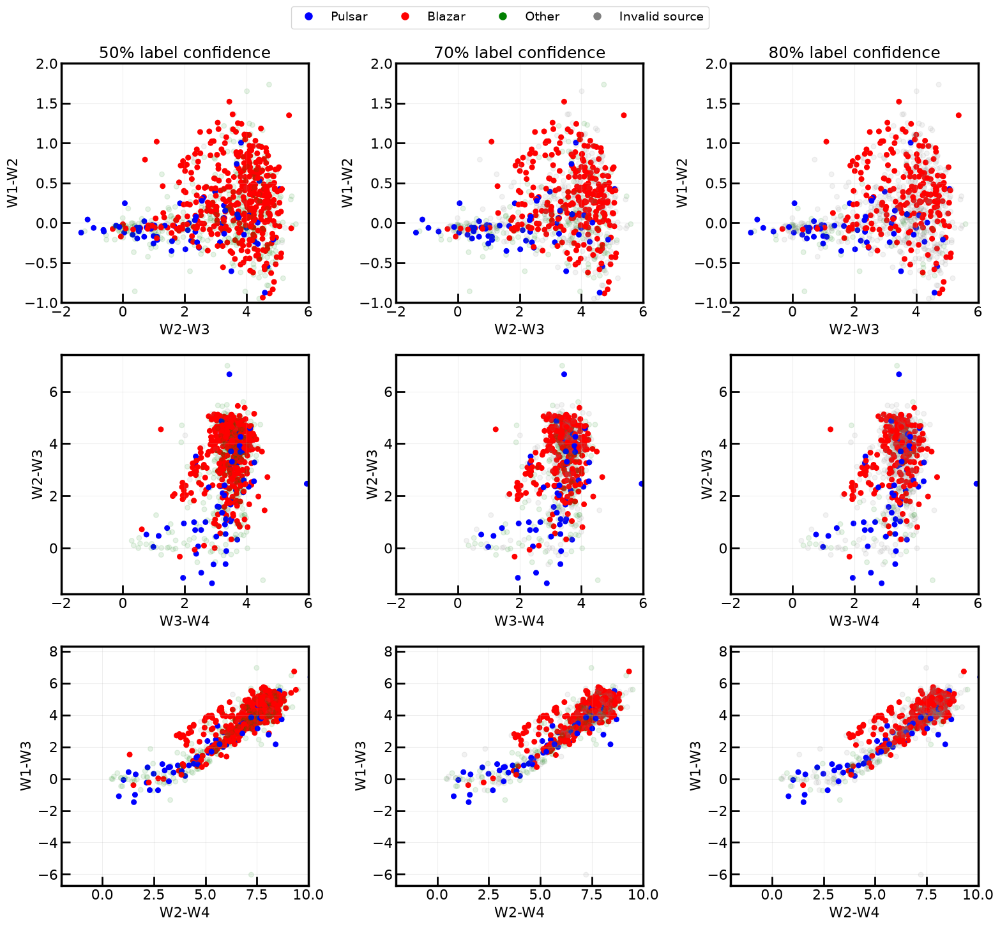

In [47]:
# associated sources version
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


thresholds = [0.5, 0.7, 0.8]

# (x-axis, y-axis, x-limits, y-limits)
color_color_plots = [
    (
        'WISE_W2_W3_color',
        'WISE_W1_W2_color',
        (-2, 6),
        (-1, 2)
    ),
    (
        'WISE_W3_W4_color',
        'WISE_W2_W3_color',
        (-2, 6),
        None
    ),
    (
        'WISE_W2_W4_color',
        'WISE_W1_W3_color',
        (-2, 10),
        None
    )
]


# ============================================================
# CLASSIFICATION COLORS
# ============================================================

cmap = ['red', 'green', 'blue', 'gray']

color_map = {
    'blazar': 0,
    'other': 1,
    'pulsar': 2
}

my_continuous_cmap = LinearSegmentedColormap.from_list(
    "my_gradient",
    cmap)

colors_thresholds = []
alphas_thresholds = []

predicted_classes = associated_source_test_table_3[
    '_3_labels_top_class_pred'
]

for threshold in thresholds:

    colors = []
    alphas = []

    for source_idx, color_key in enumerate(predicted_classes):
        probability_column = ('_3_labels_' + color_key + '_prob')
        probability = associated_source_test_table_3[probability_column][source_idx]
        if probability >= threshold:
            colors.append(color_map[color_key])
            if color_key == 'blazar':
                alphas.append(1.0)
            elif color_key == 'pulsar':
                alphas.append(1.0)
            elif color_key == 'other':
                alphas.append(0.1)
        else:
            colors.append(3)
            alphas.append(0.1)

    colors_thresholds.append(np.array(colors))
    alphas_thresholds.append(np.array(alphas))

fig, axs = plt.subplots(3,3,figsize=(16, 15))


# ============================================================
# LOOP THROUGH THE THREE COLOR-COLOR DIAGRAMS
# ============================================================

for row, (x_axis, y_axis, xlim, ylim) in enumerate(
    color_color_plots
):
    # split 
    first_color_y, second_color_y = y_axis.split('_')[1], y_axis.split('_')[2]
    first_color_x, second_color_x = x_axis.split('_')[1], x_axis.split('_')[2]

    # combine new label
    yaxis_title = first_color_y + '-' + second_color_y
    xaxis_title = first_color_x + '-' + second_color_x

    

    # Get data from Astropy Table
    x = np.asarray(
        associated_source_test_table_3[x_axis],
        dtype=float)

    y = np.asarray(
        associated_source_test_table_3[y_axis],
        dtype=float
    )


    for col, threshold in enumerate(thresholds):
        ax = axs[row, col]
        ax.scatter(
            x,
            y,
            c=colors_thresholds[col],
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds[col],
            s=30
        )

        ax.set_xlim(
            xlim[0],
            xlim[1]
        )

        if ylim is not None:

            ax.set_ylim(
                ylim[0],
                ylim[1]
            )

        if row == 0:
            ax.set_title(
                f'{threshold * 100:.0f}% label confidence',
                fontsize=18)
        ax.set_xlabel(
            xaxis_title,
            fontsize=16)

        ax.set_ylabel(
            yaxis_title,
            fontsize=16)
        ax.grid(
            True,
            alpha=0.2)


# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='blue',
        markersize=10,
        label='Pulsar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='red',
        markersize=10,
        label='Blazar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='green',
        markersize=10,
        label='Other'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='gray',
        markersize=10,
        label='Invalid source')
]


fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.980),
    fontsize=14
)




plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


output_filename = (
    'WISE_color_color_3x3_classification_confidence_associated_srcs.png'
)

# fig.savefig(
#     output_filename,
#     dpi=300,
#     bbox_inches='tight'
)


plt.show()

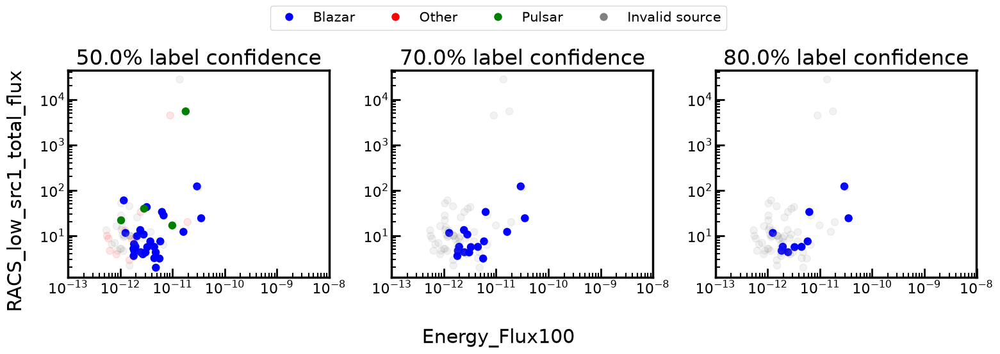

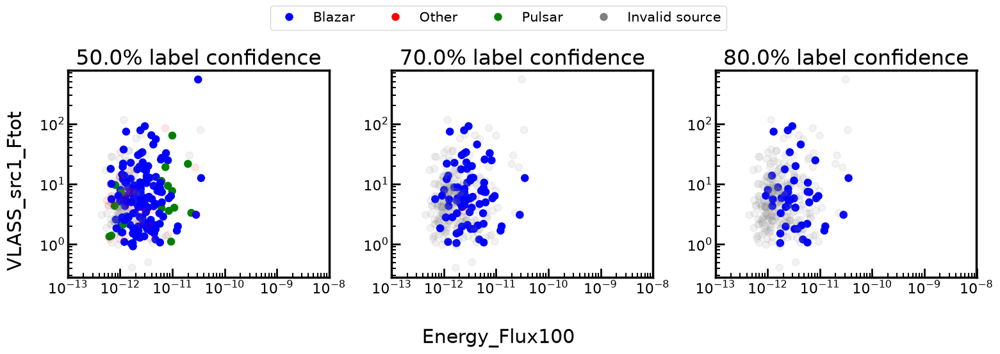

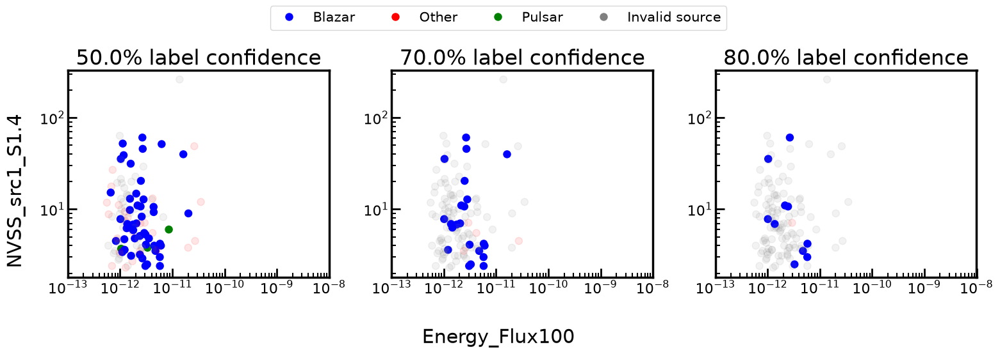

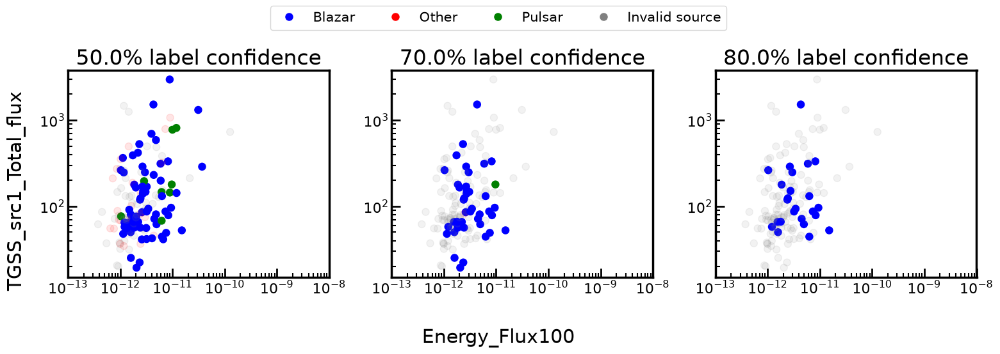

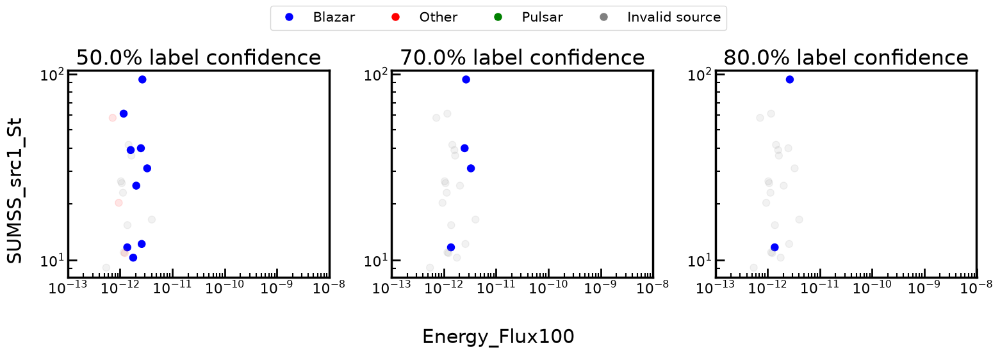

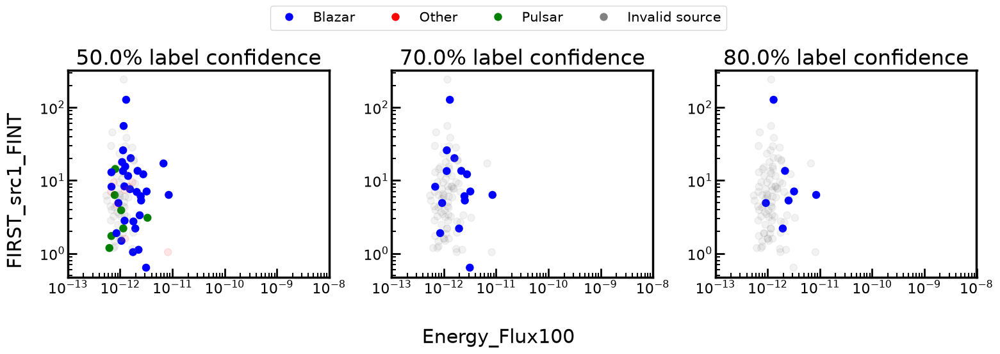

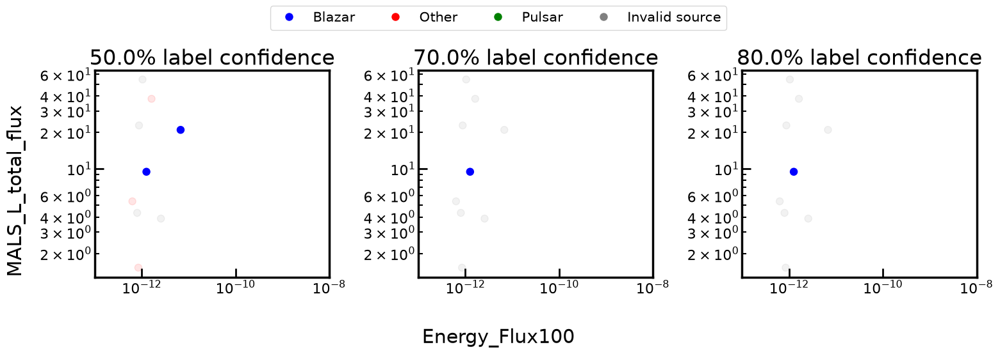

In [173]:
# radio fluxes
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D  # Imported for custom legend handles

# wise grouped plots
0.5, 0.7 , 0.9
thresholds = [0.5, 0.7, 0.8]
wise_x_axis = 'Energy_Flux100'

# Likely TOTAL / INTEGRATED radio flux columns
radio_flux_columns = {
    'RACS-low': 'RACS_low_src1_total_flux',
    'VLASS':    'VLASS_src1_Ftot',
    'NVSS':     'NVSS_src1_S1.4',
    'TGSS':     'TGSS_src1_Total_flux',
    'SUMSS':    'SUMSS_src1_St',
    'FIRST':    'FIRST_src1_FINT',
    'MALS-L':   'MALS_L_total_flux',
}



colors_thresholds = []
alphas_thresholds = []


for threshold in thresholds:
    # color = [0,1,2]
    probability_threshold = threshold
    cmap = ['blue', 'red', 'green', 'gray']
    color_map = {'blazar': 0, 'other': 1, 'pulsar': 2}
    my_continuous_cmap = LinearSegmentedColormap.from_list("my_gradient", cmap)
    
    colors = [color_map[color_key] if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold else 3 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    alphas = [1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and (color_key == 'blazar' or color_key =='pulsar') else 0.1 if top_match_unassociated_sources['labels_3_' + color_key +'_prob'][source_idx] >=probability_threshold and color_key == ('other') else 0.1 for source_idx, color_key in enumerate(top_match_unassociated_sources['labels_3_top_class_pred'])]
    
    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)

for key, value  in radio_flux_columns.items():
    wise_y_axis = value
    
    # Adjusted figsize and added layout constraint to fit the legend nicely
    fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout='tight')
    
    # Subplot 0
    axs[0].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[0], cmap=my_continuous_cmap, alpha =alphas_thresholds[0])
    axs[0].set_title(f'{str(thresholds[0]*100)}% label confidence')
    axs[0].set_xlim(10**-13, 10**-8)
    # axs[0].set_ylim(10**-3, 10**-8)

    axs[0].set_xscale('log')
    axs[0].set_yscale('log')
    
    # Subplot 1
    axs[1].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[1], cmap=my_continuous_cmap, alpha =alphas_thresholds[1])
    axs[1].set_title(f'{str(thresholds[1]*100)}% label confidence')
    axs[1].set_xlim(10**-13, 10**-8)
    axs[1].set_xscale('log')
    axs[1].set_yscale('log')
    
    # Subplot 2
    axs[2].scatter( top_match_unassociated_sources[wise_x_axis], top_match_unassociated_sources[wise_y_axis], c = colors_thresholds[2], cmap=my_continuous_cmap, alpha =alphas_thresholds[2])
    axs[2].set_title(f'{str(thresholds[2]*100)}% label confidence')
    axs[2].set_xlim(10**-13, 10**-8)
    axs[2].set_xscale('log')
    axs[2].set_yscale('log')
    
    # --- CUSTOM LEGEND IMPLEMENTATION ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Blazar'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Other'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Pulsar'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Invalid source')
    ]
    
    # Places a single shared legend at the top center of the entire figure
    fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.10), fontsize=15)
    
    fig.supxlabel(wise_x_axis)
    fig.supylabel(wise_y_axis)
    
    plt.show()
    


In [164]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# ============================================================
# Settings
# ============================================================

thresholds = [0.5, 0.7, 0.8]

wise_x_axis = 'Fermi_Flux_Density'

# Likely TOTAL / INTEGRATED radio flux columns
radio_flux_columns = {
    'RACS-low': 'RACS_low_src1_total_flux',
    'VLASS':    'VLASS_src1_Ftot',
    'NVSS':     'NVSS_src1_S1.4',
    'TGSS':     'TGSS_src1_Total_flux',
    'SUMSS':    'SUMSS_src1_St',
    'FIRST':    'FIRST_src1_FINT',
    'MALS-L':   'MALS_L_total_flux',
}


# ============================================================
# Classification colors
# ============================================================

cmap = ['blue', 'red', 'green', 'gray']
color_map = {
    'blazar': 0,
    'other': 1,
    'pulsar': 2
}

my_continuous_cmap = LinearSegmentedColormap.from_list(
    "my_gradient",
    cmap
)


# ============================================================
# Calculate colors and alpha for each probability threshold
# ============================================================

colors_thresholds = []
alphas_thresholds = []

for threshold in thresholds:

    colors = []
    alphas = []

    for source_idx, color_key in enumerate(
        top_match_unassociated_sources['labels_3_top_class_pred']
    ):

        probability_column = 'labels_3_' + color_key + '_prob'
        probability = top_match_unassociated_sources[
            probability_column
        ].iloc[source_idx]

        if probability >= threshold:
            colors.append(color_map[color_key])

            if color_key in ['blazar', 'pulsar']:
                alphas.append(1.0)
            else:
                alphas.append(0.1)

        else:
            colors.append(3)
            alphas.append(0.1)

    colors_thresholds.append(colors)
    alphas_thresholds.append(alphas)


# ============================================================
# Remove radio catalogs whose flux column isn't available
# ============================================================

available_radio_fluxes = {}

for catalog_name, flux_column in radio_flux_columns.items():

    if flux_column not in top_match_unassociated_sources.columns:
        print(f"Skipping {catalog_name}: {flux_column} not found")
        continue

    # Check whether there is at least one finite numerical value
    values = np.asarray(
        top_match_unassociated_sources[flux_column],
        dtype=float
    )

    if np.isfinite(values).sum() == 0:
        print(f"Skipping {catalog_name}: no valid flux values")
        continue

    available_radio_fluxes[catalog_name] = flux_column


print("Radio fluxes that will be plotted:")
for catalog_name, flux_column in available_radio_fluxes.items():
    print(f"  {catalog_name}: {flux_column}")


# ============================================================
# Make one figure per radio catalog
# ============================================================

for catalog_name, radio_flux_column in available_radio_fluxes.items():

    fig, axs = plt.subplots(
        1,
        len(thresholds),
        figsize=(16, 5),
        layout='tight'
    )

    # Make sure axs is iterable if there is only one threshold
    axs = np.atleast_1d(axs)

    for i, threshold in enumerate(thresholds):

        x = np.asarray(
            top_match_unassociated_sources[wise_x_axis],
            dtype=float
        )

        y = np.asarray(
            top_match_unassociated_sources[radio_flux_column],
            dtype=float
        )

        # Only plot finite values
        valid = np.isfinite(x) & np.isfinite(y)

        axs[i].scatter(
            x[valid],
            y[valid],
            c=np.asarray(colors_thresholds[i])[valid],
            cmap=my_continuous_cmap,
            alpha=np.asarray(alphas_thresholds[i])[valid],
            s=30
        )

        axs[i].set_title(
            f'{threshold * 100:.0f}% label confidence'
        )

        axs[i].set_xlim(-2, 10)

        # Radio flux is positive, so log scale is appropriate
        positive_y = y[valid][y[valid] > 0]

        if len(positive_y) > 0:
            axs[i].set_yscale('log')

        axs[i].set_xlabel(wise_x_axis)
        axs[i].set_ylabel(radio_flux_column)

        axs[i].grid(
            True,
            alpha=0.2
        )

    # ========================================================
    # Shared legend
    # ========================================================

    legend_elements = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='blue',
            markersize=10,
            label='Blazar'
        ),

        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='red',
            markersize=10,
            label='Other'
        ),

        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='green',
            markersize=10,
            label='Pulsar'
        ),

        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor='gray',
            markersize=10,
            label='Invalid source'
        )
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper center',
        ncol=4,
        bbox_to_anchor=(0.5, 1.08),
        fontsize=12
    )

    fig.supxlabel(wise_x_axis)

    fig.supylabel(
        f'{catalog_name} total radio flux\n({radio_flux_column})'
    )

    fig.suptitle(
        f'{catalog_name}: Fermi flux vs total radio flux',
        fontsize=16
    )

    plt.show()

AttributeError: 'Column' object has no attribute 'iloc'

In [ ]:
# % should highlight the distribution spread of the unassociated sources since that is the actual result

In [ ]:
# classification traingle plot for associated sources 
# should overlay the model vs actual 

In [ ]:
# classification traingle plot for unassociated sources 

In [ ]:
# repeat with umap

## Discussion

In [ ]:
# the probability of the matches for some of the top matches from our model!

In [162]:
top_match_unassociated_sources.colnames

['WISE',
 'Separation_FERMI_WISE',
 'Separation_max',
 'ncat',
 'dist_bayesfactor_uncorrected',
 'dist_bayesfactor',
 'dist_post',
 'p_single',
 'match_flag',
 'prob_has_match',
 'prob_this_match',
 'Source_Name',
 'DataRelease',
 'RA',
 'DEC',
 'GLON',
 'GLAT',
 'Conf_68_SemiMajor',
 'Conf_68_SemiMinor',
 'Conf_68_PosAng',
 'Conf_95_SemiMajor',
 'Conf_95_SemiMinor',
 'Conf_95_PosAng',
 'ROI_num',
 'Signif_Avg',
 'Pivot_Energy',
 'Flux1000',
 'Unc_Flux1000',
 'Energy_Flux100',
 'Unc_Energy_Flux100',
 'SpectrumType',
 'PL_Flux_Density',
 'Unc_PL_Flux_Density',
 'PL_Index',
 'Unc_PL_Index',
 'LP_Flux_Density',
 'Unc_LP_Flux_Density',
 'LP_Index',
 'Unc_LP_Index',
 'LP_beta',
 'Unc_LP_beta',
 'LP_SigCurv',
 'LP_EPeak',
 'Unc_LP_EPeak',
 'PLEC_Flux_Density',
 'Unc_PLEC_Flux_Density',
 'PLEC_IndexS',
 'Unc_PLEC_IndexS',
 'PLEC_ExpfactorS',
 'Unc_PLEC_ExpfactorS',
 'PLEC_Exp_Index',
 'PLEC_SigCurv',
 'PLEC_EPeak',
 'Unc_PLEC_EPeak',
 'Npred',
 'Flux_Band',
 'Unc_Flux_Band',
 'nuFnu_Band',
 '

In [ ]:
asso

#### basic statistics of fermi 

In [10]:
print(f'ALL associated sources {len(associated_source_table)}')
print(f'ALLunassociated sources: {len(unassociated_source_table)}')
# print(f'REDUCED unassociated sources w/radio sources more than one or with mals: {}')
# print(f'number of matches with unassociated sources {}')
# print(f'number of unique labels : {set(associated_source_table['CLASS1']}')


ALL associated sources 4635
ALLunassociated sources: 4170


In [35]:
print(f'number of combinations for the phase 2 analysis: {}')
pri

SyntaxError: f-string: valid expression required before '}' (3635437702.py, line 1)

In [11]:
# not my issue with the probbailites for the associated soruce but it should be fine here!
labels = ['Source_Name', 'RA', 'DEC', 'Conf_95_PosAng', 'prob_has_match', 'prob_this_match', 'ncat', 'match_flag', 'closest_spx_idx',
 'closest_flux_ratio', 'labels_3_top_class_pred',  'labels_3_blazar_prob', 'labels_3_other_prob', 'labels_3_pulsar_prob',
          'WISE_W2_W3_color', 'WISE_W1_W2_color', 'WISE_W3_W4_color','WISE_W2_W4_color','WISE_W1_W3_color',]


In [12]:
column_reduced_top_unassociated_matches2 = top_match_unassociated_sources[labels]

In [13]:
column_reduced_top_unassociated_matches2['pulsar_complete_prob'] = column_reduced_top_unassociated_matches2['prob_has_match'] * column_reduced_top_unassociated_matches2['prob_this_match'] * column_reduced_top_unassociated_matches2['labels_3_pulsar_prob']
column_reduced_top_unassociated_matches2['blazar_complete_prob'] = column_reduced_top_unassociated_matches2['prob_has_match'] * column_reduced_top_unassociated_matches2['prob_this_match'] * column_reduced_top_unassociated_matches2['labels_3_blazar_prob']

In [14]:
column_reduced_top_unassociated_matches2.sort('pulsar_complete_prob', reverse=True)
# column_reduced_top_unassociated_matches_pulsar.sort('prob_this_match')
sources_names_top_p_i_matches = vstack([column_reduced_top_unassociated_matches2[column_reduced_top_unassociated_matches2['pulsar_complete_prob'] > 0.50],
                                       column_reduced_top_unassociated_matches2[column_reduced_top_unassociated_matches2['blazar_complete_prob'] > 0.50]])
sources_names_top_p_i_matches


Source_Name,RA,DEC,Conf_95_PosAng,prob_has_match,prob_this_match,ncat,match_flag,closest_spx_idx,closest_flux_ratio,labels_3_top_class_pred,labels_3_blazar_prob,labels_3_other_prob,labels_3_pulsar_prob,WISE_W2_W3_color,WISE_W1_W2_color,WISE_W3_W4_color,WISE_W2_W4_color,WISE_W1_W3_color,pulsar_complete_prob,blazar_complete_prob
bytes18,float64,float64,float32,float64,float64,int64,int64,float64,float64,bytes6,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64
4FGL J1721.4+1131,260.3575134277344,11.528800010681152,21.69,0.9999999999916088,0.998549676999371,4,1,0.039008020727159066,1.0942726811961478,pulsar,0.10486569,0.11449473,0.7806396,4.166,0.08300000000000196,3.279,7.445,4.249000000000002,0.7795074092754284,0.10471360342913501
4FGL J0251.6+0628,42.9005012512207,6.4710001945495605,-38.81,0.9999999999997861,0.9998906311923204,4,1,-1.137352034646611,0.9120304327151687,pulsar,0.11859596,0.15925743,0.7221466,--,--,--,--,--,0.7220675903729656,0.11858298705752171
4FGL J0526.4+1114,81.61910247802734,11.2391996383667,-24.14,0.9999999999999972,0.9972173799155792,3,1,-1.6660656261120836,0.9383993692095407,pulsar,0.11543271,0.16711915,0.7174481,--,--,--,--,--,0.7154517298135145,0.11511150407975984
4FGL J1929.8+1832,292.4541015625,18.54990005493164,18.99,0.9991705877451929,0.9919291971154681,3,1,1.695157452770202,0.6221605249873802,pulsar,0.16741402,0.12200324,0.71058273,--,--,--,--,--,0.7042631506119543,0.16592512431039114
4FGL J1901.5-1112,285.3963928222656,-11.200200080871582,-25.16,0.9999999999999863,0.9834674726113017,3,1,-0.6014628799031646,0.7348643006263048,pulsar,0.16593017,0.11896959,0.7151002,--,--,--,--,--,0.7032778146683822,0.16318692181264832
4FGL J0138.6+6821,24.668500900268555,68.35030364990234,-0.36,0.9780823578085778,0.9856803544910354,3,1,-0.2617205526637921,0.9390327756131103,pulsar,0.09669328,0.18132529,0.72198147,1.3609999999999989,0.2870000000000008,3.269,4.629999999999999,1.6479999999999997,0.6960454116780178,0.0932197227109346
4FGL J0337.5+2423C,54.394100189208984,24.38360023498535,55.63,0.9279000267552042,0.9910012959611335,3,1,-1.6399797048416591,0.980579645689719,pulsar,0.117688105,0.13037916,0.75193274,2.2889999999999997,0.7210000000000001,2.4770000000000003,4.766,3.01,0.6914398482884506,0.10822011168854688
4FGL J1825.8+1204,276.46038818359375,12.06779956817627,-27.38,0.9999999999999989,0.9970155149578981,3,1,-0.49034300809218434,0.7748751783166905,pulsar,0.14275081,0.17602362,0.68122554,--,--,--,--,--,0.6791924308245672,0.1423247768862819
4FGL J0801.0-0618,120.27330017089844,-6.316500186920166,58.48,1.0,0.9999999994833734,3,1,-2.3057422005151587,0.6894347398492015,pulsar,0.19883214,0.1244752,0.67669266,--,--,--,--,--,0.676692664273663,0.19883213927010365


In [ ]:
column_reduced_top_unassociated_matches2[column_reduced_top_unassociated_matches2['pulsar_complete_prob'] > 0.70]

In [22]:
column_reduced_top_unassociated_matches2[column_reduced_top_unassociated_matches2['blazar_complete_prob'] > 0.70]

Source_Name,RA,DEC,Conf_95_PosAng,prob_has_match,prob_this_match,ncat,match_flag,closest_spx_idx,closest_flux_ratio,labels_3_top_class_pred,labels_3_blazar_prob,labels_3_other_prob,labels_3_pulsar_prob,WISE_W2_W3_color,WISE_W1_W2_color,WISE_W3_W4_color,WISE_W2_W4_color,WISE_W1_W3_color,pulsar_complete_prob,blazar_complete_prob
bytes18,float64,float64,float32,float64,float64,int64,int64,float64,float64,bytes6,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64
4FGL J0132.9-4259,23.23740005493164,-42.9833984375,-85.39,1.0,0.9166994634241422,4,1,-0.7844383509198639,0.9301947355270386,blazar,0.7708115,0.09263023,0.13655832,3.9860000000000007,0.597999999999999,2.846,6.832000000000001,4.584,0.12518294242727485,0.7066024867691344
4FGL J1843.3-1242,280.8398132324219,-12.71310043334961,5.7,1.0,0.9987059962091124,3,1,-0.770404847859703,1.003388102662509,blazar,0.7265347,0.23381138,0.03965391,--,--,--,--,--,0.039602596153459846,0.7255945855481624
4FGL J1604.4-4927,241.11090087890625,-49.45560073852539,6.25,0.9999999999990681,0.9964598478488577,2,1,-0.9357902775719937,0.6902742981910706,blazar,0.7442738,0.22342496,0.03230124,--,--,--,--,--,0.03218688836619305,0.7416389393461424
4FGL J0259.0+0552,44.75189971923828,5.877999782562256,41.28,0.9999997468643707,0.9996405327402287,4,1,-0.6539357106443711,0.9690739460953697,blazar,0.90140635,0.07825725,0.020336416,1.918000000000001,0.8069999999999986,3.757999999999999,5.676,2.7249999999999996,0.02032910019704118,0.9010820935858102


In [77]:
column_reduced_top_unassociated_matches2[column_reduced_top_unassociated_matches2['pulsar_complete_prob'] > 0.50]

Source_Name,RA,DEC,Conf_95_PosAng,prob_has_match,prob_this_match,ncat,match_flag,closest_spx_idx,closest_flux_ratio,labels_3_top_class_pred,labels_3_blazar_prob,labels_3_other_prob,labels_3_pulsar_prob,WISE_W2_W3_color,WISE_W1_W2_color,WISE_W3_W4_color,WISE_W2_W4_color,WISE_W1_W3_color,pulsar_complete_prob,blazar_complete_prob
bytes18,float64,float64,float32,float64,float64,int64,int64,float64,float64,bytes6,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64
4FGL J1721.4+1131,260.3575134277344,11.528800010681152,21.69,0.9999999999916088,0.998549676999371,4,1,0.039008020727159066,1.0942726811961478,pulsar,0.10486569,0.11449473,0.7806396,4.166,0.08300000000000196,3.279,7.445,4.249000000000002,0.7795074092754284,0.10471360342913501
4FGL J0251.6+0628,42.9005012512207,6.4710001945495605,-38.81,0.9999999999997861,0.9998906311923204,4,1,-1.137352034646611,0.9120304327151687,pulsar,0.11859596,0.15925743,0.7221466,--,--,--,--,--,0.7220675903729656,0.11858298705752171
4FGL J0526.4+1114,81.61910247802734,11.2391996383667,-24.14,0.9999999999999972,0.9972173799155792,3,1,-1.6660656261120836,0.9383993692095407,pulsar,0.11543271,0.16711915,0.7174481,--,--,--,--,--,0.7154517298135145,0.11511150407975984
4FGL J1929.8+1832,292.4541015625,18.54990005493164,18.99,0.9991705877451929,0.9919291971154681,3,1,1.695157452770202,0.6221605249873802,pulsar,0.16741402,0.12200324,0.71058273,--,--,--,--,--,0.7042631506119543,0.16592512431039114
4FGL J1901.5-1112,285.3963928222656,-11.200200080871582,-25.16,0.9999999999999863,0.9834674726113017,3,1,-0.6014628799031646,0.7348643006263048,pulsar,0.16593017,0.11896959,0.7151002,--,--,--,--,--,0.7032778146683822,0.16318692181264832
4FGL J0138.6+6821,24.668500900268555,68.35030364990234,-0.36,0.9780823578085778,0.9856803544910354,3,1,-0.2617205526637921,0.9390327756131103,pulsar,0.09669328,0.18132529,0.72198147,1.3609999999999989,0.2870000000000008,3.269,4.629999999999999,1.6479999999999997,0.6960454116780178,0.0932197227109346
4FGL J0337.5+2423C,54.394100189208984,24.38360023498535,55.63,0.9279000267552042,0.9910012959611335,3,1,-1.6399797048416591,0.980579645689719,pulsar,0.117688105,0.13037916,0.75193274,2.2889999999999997,0.7210000000000001,2.4770000000000003,4.766,3.01,0.6914398482884506,0.10822011168854688
4FGL J1825.8+1204,276.46038818359375,12.06779956817627,-27.38,0.9999999999999989,0.9970155149578981,3,1,-0.49034300809218434,0.7748751783166905,pulsar,0.14275081,0.17602362,0.68122554,--,--,--,--,--,0.6791924308245672,0.1423247768862819
4FGL J0801.0-0618,120.27330017089844,-6.316500186920166,58.48,1.0,0.9999999994833734,3,1,-2.3057422005151587,0.6894347398492015,pulsar,0.19883214,0.1244752,0.67669266,--,--,--,--,--,0.676692664273663,0.19883213927010365


In [80]:
column_reduced_top_unassociated_matches2[column_reduced_top_unassociated_matches2['blazar_complete_prob'] > 0.50]

Source_Name,RA,DEC,Conf_95_PosAng,prob_has_match,prob_this_match,ncat,match_flag,closest_spx_idx,closest_flux_ratio,labels_3_top_class_pred,labels_3_blazar_prob,labels_3_other_prob,labels_3_pulsar_prob,WISE_W2_W3_color,WISE_W1_W2_color,WISE_W3_W4_color,WISE_W2_W4_color,WISE_W1_W3_color,pulsar_complete_prob,blazar_complete_prob
bytes18,float64,float64,float32,float64,float64,int64,int64,float64,float64,bytes6,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64
4FGL J1754.8-3200,268.70330810546875,-32.000701904296875,65.32,0.9999991550846944,0.9472557491248592,2,1,0.06051657902572386,0.46456271730409204,blazar,0.5593369,0.15825178,0.2824113,--,--,--,--,--,0.2675155082368697,0.5298346472304506
4FGL J0024.1+2402,6.038400173187256,24.03660011291504,-56.48,0.9999999719971377,0.9885092557419832,5,1,1.9887839138148204,1.070337806571032,blazar,0.55096817,0.17903842,0.2699934,2.2170000000000005,0.8710000000000004,3.305999999999999,5.523,3.088000000000001,0.26689096209070007,0.5446371205769318
4FGL J1659.6+4918,254.90530395507812,49.30400085449219,27.34,0.999998398126136,0.9975605302128634,4,1,-0.5273069642627262,0.9443654604469003,blazar,0.568708,0.18003702,0.251255,2.16,0.8330000000000002,2.817,4.977,2.9930000000000003,0.2506416751060532,0.5673197478011933
4FGL J1846.0+0507,281.50750732421875,5.127799987792969,-57.08,0.9999999958645767,0.9978777768613126,3,1,-0.5507128804157991,0.8603988603988604,blazar,0.569311,0.1888447,0.2418443,--,--,--,--,--,0.24133104789548007,0.5681028153835305
4FGL J1403.7+2429,210.93609619140625,24.49530029296875,-25.84,0.9999989714501375,0.9996243652041179,4,1,-0.71123788165191,1.0343206393982136,blazar,0.5411776,0.22706302,0.23175946,2.8200000000000003,0.1280000000000001,3.610000000000001,6.4300000000000015,2.9480000000000004,0.23167216357667894,0.5409737292744767
4FGL J1132.1-1448,173.04550170898438,-14.812100410461426,-60.99,0.9999999999999649,0.9446603160476804,3,1,-0.3166417619232209,0.8513238430023193,blazar,0.54384047,0.21954265,0.23661688,2.8789999999999996,0.972999999999999,2.5860000000000003,5.465,3.8519999999999985,0.22352257636113515,0.5137445083141031
4FGL J2207.1+2222,331.79119873046875,22.37420082092285,87.39,0.969956903744906,0.9824542907521271,3,1,-0.46096948224709566,0.983197163557885,blazar,0.6301136,0.1364779,0.2334085,3.058,0.47799999999999976,3.6240000000000006,6.682,3.5359999999999996,0.22242390029615253,0.6004593982138261
4FGL J1048.4-5030,162.10670471191406,-50.51319885253906,-36.6,1.0,0.9244136403104765,3,1,-0.5913499736334237,0.9133321046829224,blazar,0.5650322,0.22641136,0.20855644,2.229000000000001,0.6839999999999993,2.324,4.553000000000001,2.9130000000000003,0.19279242110244132,0.5223234582186397
4FGL J2353.2+3135,358.3215026855469,31.59269905090332,-44.47,0.9998279305154745,0.9912043614422895,4,1,0.10691434734133427,0.9981686492550857,blazar,0.5977501,0.2139974,0.18825242,3.019,0.875,3.1950000000000003,6.214,3.894,0.1865645114120864,0.5923905833630474


In [43]:
column_reduced_top_unassociated_matches_pulsar = column_reduced_top_unassociated_matches[column_reduced_top_unassociated_matches['labels_3_top_class_pred'] == 'pulsar']
column_reduced_top_unassociated_matches_pulsar.sort('prob_this_match', reverse=True)
# column_reduced_top_unassociated_matches_pulsar.sort('prob_this_match')
sources_names_top_p_i_matches = column_reduced_top_unassociated_matches_pulsar[0:40]
sources_names_top_p_i_matches


Source_Name,RA,DEC,Conf_95_PosAng,prob_has_match,prob_this_match,ncat,match_flag,closest_spx_idx,closest_flux_ratio,labels_3_top_class_pred,labels_3_blazar_prob,labels_3_other_prob,labels_3_pulsar_prob,pulsar_complete_prob
bytes18,float64,float64,float32,float64,float64,int64,int64,float64,float64,bytes6,float32,float32,float32,float64
4FGL J0031.5-4025,7.8902997970581055,-40.421199798583984,71.6,0.1890203850984714,1.0,2,1,--,--,pulsar,0.25516343,0.3048672,0.43996936,0.08316317801531242
4FGL J0928.3-2713,142.0948028564453,-27.220800399780273,-48.35,1.0,0.99999999999982,3,1,-0.8174783067901059,0.7159011712866168,pulsar,0.2484001,0.23119569,0.5204042,0.5204042196272867
4FGL J0713.8-4820C,108.45369720458984,-48.34749984741211,54.27,0.9999999999991325,0.9999999999818068,2,1,-2.0646131711229034,0.9318497776985168,pulsar,0.33055434,0.23899019,0.43045545,0.4304554462350813
4FGL J0801.0-0618,120.27330017089844,-6.316500186920166,58.48,1.0,0.9999999994833734,3,1,-2.3057422005151587,0.6894347398492015,pulsar,0.19883214,0.1244752,0.67669266,0.676692664273663
4FGL J1551.7-4257,237.9315948486328,-42.95949935913086,26.66,0.9999999999991402,0.9999991407486049,2,1,-1.4148566910504945,0.8647711277008057,pulsar,0.19596684,0.13600686,0.6680263,0.6680257540837243
4FGL J1709.2-0437,257.3158874511719,-4.626200199127197,-9.39,1.0,0.9999986145707218,3,1,-0.8296594258554452,0.9137309519908242,pulsar,0.21107343,0.15368731,0.63523924,0.6352383634283386
4FGL J0713.5-2555,108.37889862060547,-25.93090057373047,-46.3,0.9999991771411044,0.9999924050733706,2,1,0.06305464682240917,0.7213223689675222,pulsar,0.20060673,0.1343343,0.665059,0.6650533721317365
4FGL J1720.6-5144,260.158203125,-51.74789810180664,5.14,0.9999999999989351,0.9999901332555302,2,1,-0.5319588050461275,0.8684369325637817,pulsar,0.21286002,0.368048,0.41909194,0.41908780485262054
4FGL J1226.5+3023,186.63980102539062,30.384000778198242,-78.96,0.9999999996663016,0.9999715601057447,3,1,3.097344479682376,0.969909227360446,pulsar,0.28034785,0.31768194,0.40197018,0.4019587457653843


In [38]:
column_reduced_top_unassociated_matches_pulsar = column_reduced_top_unassociated_matches[column_reduced_top_unassociated_matches['labels_3_top_class_pred'] == 'pulsar']
column_reduced_top_unassociated_matches_pulsar.sort('labels_3_pulsar_prob', reverse=True)
# column_reduced_top_unassociated_matches_pulsar.sort('prob_this_match')
sources_names_top_p_i_matches = column_reduced_top_unassociated_matches_pulsar[0:40]
sources_names_top_p_i_matches


Source_Name,RA,DEC,Conf_95_PosAng,prob_has_match,prob_this_match,ncat,match_flag,closest_spx_idx,closest_flux_ratio,labels_3_top_class_pred,labels_3_blazar_prob,labels_3_other_prob,labels_3_pulsar_prob
bytes18,float64,float64,float32,float64,float64,int64,int64,float64,float64,bytes6,float32,float32,float32
4FGL J1723.5-3342C,260.88580322265625,-33.70289993286133,49.03,0.09459855666534123,0.00746265941816161,2,1,--,--,pulsar,0.052007396,0.07037169,0.87762094
4FGL J1859.3+0058,284.8326110839844,0.9800999760627747,59.58,0.3388849413675996,0.0,3,0,-0.2088372356541746,0.1896147403685092,pulsar,0.031577487,0.11081043,0.8576121
4FGL J1349.1-5829,207.2830047607422,-58.48929977416992,-47.78,0.24313662195273256,0.004298586373294315,2,1,--,--,pulsar,0.07389465,0.07107413,0.85503125
4FGL J0832.2-4322C,128.06329345703125,-43.3671989440918,56.54,0.20255129150269735,0.003851261351877588,2,1,--,--,pulsar,0.052406367,0.09877581,0.8488179
4FGL J1216.2-0600,184.06280517578125,-6.005199909210205,-50.5,0.9999999980230131,0.08247571826604663,5,1,1023.6791324920249,0.959629218710855,pulsar,0.13213073,0.028502453,0.83936685
4FGL J0554.0-0839,88.51750183105469,-8.655200004577637,-15.88,0.9999980263865754,0.1698679899563562,5,1,41.33594690883137,0.9287076776347163,pulsar,0.05164889,0.109585725,0.83876544
4FGL J1835.3-2439,278.84271240234375,-24.659299850463867,-54.64,0.2559856176705019,0.0015308013749520805,2,1,--,--,pulsar,0.065954074,0.101538815,0.83250713
4FGL J1806.9-2824,271.7449035644531,-28.415800094604492,-14.03,0.18496532276309952,0.005212578160613534,2,1,--,--,pulsar,0.048938334,0.12074817,0.83031344
4FGL J1845.8-0236C,281.4585876464844,-2.6068999767303467,-27.88,0.2830545853221781,0.009296675009160336,2,1,--,--,pulsar,0.047867533,0.12615837,0.8259741


0
1
2
0
1
2
0
1
2


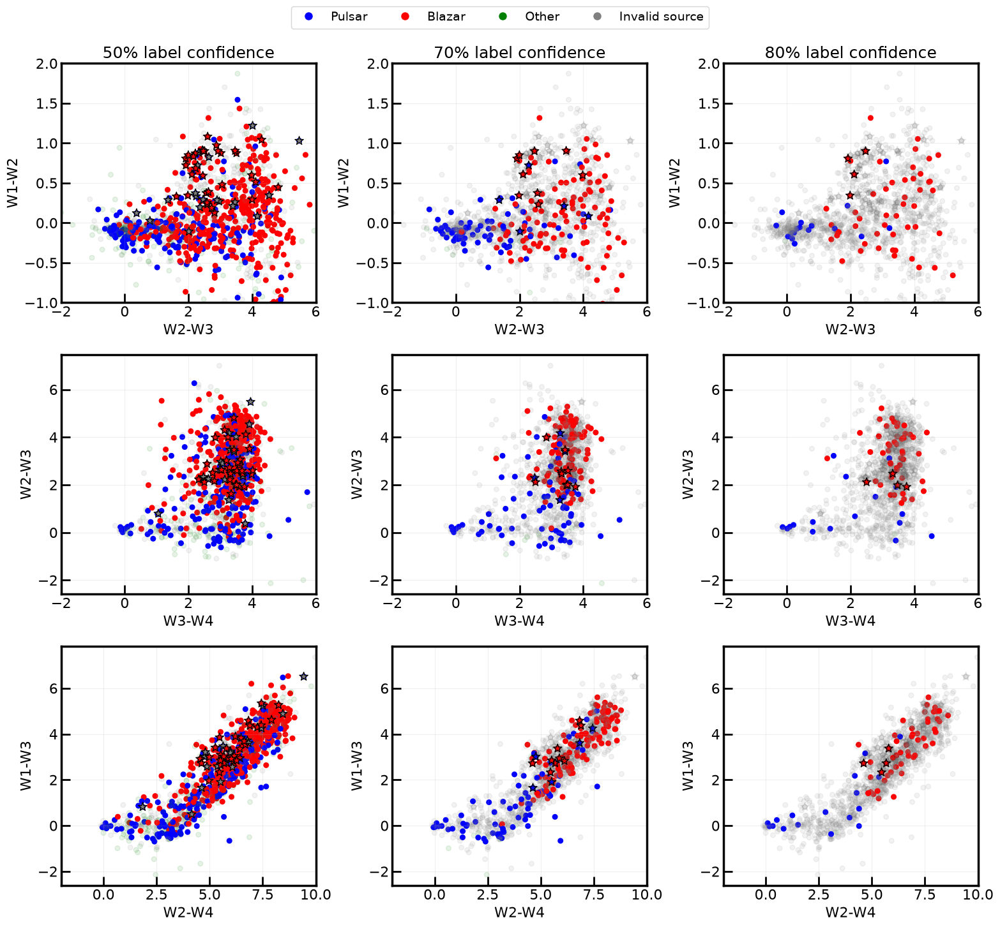

In [20]:
# HAVE TO REDO MY TOP MATCHES SINCE THEY COULDB E OVERLLAIPING ACROSS TOP PANY EVEN SHOULD BE THE TOP ONE PER FERMI ELLIPSE YOU DINGUS!

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


thresholds = [0.5, 0.7, 0.8]

# (x-axis, y-axis, x-limits, y-limits)
color_color_plots = [
    (
        'WISE_W2_W3_color',
        'WISE_W1_W2_color',
        (-2, 6),
        (-1, 2)
    ),
    (
        'WISE_W3_W4_color',
        'WISE_W2_W3_color',
        (-2, 6),
        None
    ),
    (
        'WISE_W2_W4_color',
        'WISE_W1_W3_color',
        (-2, 10),
        None
    )
]


# ============================================================
# CLASSIFICATION COLORS
# ============================================================

cmap = ['red', 'green', 'blue', 'gray']

color_map = {
    'blazar': 0,
    'other': 1,
    'pulsar': 2
}

my_continuous_cmap = LinearSegmentedColormap.from_list(
    "my_gradient",
    cmap)

colors_thresholds = []
alphas_thresholds = []

colors_thresholds2 = []
alphas_thresholds2 = []

predicted_classes = sources_names_top_p_i_matches[
    'labels_3_top_class_pred'
]

for threshold in thresholds:

    colors = []
    alphas = []


    for source_idx, color_key in enumerate(predicted_classes):

        probability_column = (
            'labels_3_' + color_key + '_prob'
        )

        # IMPORTANT:
        # Astropy Table does NOT use .iloc
        probability = sources_names_top_p_i_matches[
            probability_column
        ][source_idx]

        if probability >= threshold:

            colors.append(color_map[color_key])

            if color_key == 'blazar':
                alphas.append(1.0)
            elif color_key == 'pulsar':
                alphas.append(1.0)
            elif color_key == 'other':
                alphas.append(0.1)
        else:
            colors.append(3)
            alphas.append(0.1)

    colors_thresholds.append(
        np.array(colors))

    alphas_thresholds.append(
        np.array(alphas))


predicted_classes = top_match_unassociated_sources[
    'labels_3_top_class_pred'
]

for threshold in thresholds:

    colors = []
    alphas = []

    for source_idx, color_key in enumerate(predicted_classes):

        probability_column = (
            'labels_3_' + color_key + '_prob'
        )

        # IMPORTANT:
        # Astropy Table does NOT use .iloc
        probability = top_match_unassociated_sources[
            probability_column
        ][source_idx]

        if probability >= threshold:

            colors.append(color_map[color_key])

            if color_key == 'blazar':
                alphas.append(1.0)
            elif color_key == 'pulsar':
                alphas.append(1.0)
            elif color_key == 'other':
                alphas.append(0.1)
        else:
            colors.append(3)
            alphas.append(0.1)

    colors_thresholds2.append(
        np.array(colors))

    alphas_thresholds2.append(
        np.array(alphas))


fig, axs = plt.subplots(
    3,
    3,
    figsize=(16, 15)
)


# ============================================================
# LOOP THROUGH THE THREE COLOR-COLOR DIAGRAMS
# ============================================================

for row, (x_axis, y_axis, xlim, ylim) in enumerate(
    color_color_plots
):
    # split 
    first_color_y, second_color_y = y_axis.split('_')[1], y_axis.split('_')[2]

    first_color_x, second_color_x = x_axis.split('_')[1], x_axis.split('_')[2]

    # combine new label
    yaxis_title = first_color_y + '-' + second_color_y
    xaxis_title = first_color_x + '-' + second_color_x

    

    # Get data from Astropy Table
    x = np.asarray(
        sources_names_top_p_i_matches[x_axis],
        dtype=float)

    y = np.asarray(
        sources_names_top_p_i_matches[y_axis],
        dtype=float
    )
    source_names = np.array(sources_names_top_p_i_matches['Source_Name'])

 

    # Get data from Astropy Table
    x2 = np.asarray(
        top_match_unassociated_sources[x_axis],
        dtype=float)

    y2 = np.asarray(
        top_match_unassociated_sources[y_axis],
        dtype=float
    )


        
    for col, threshold in enumerate(thresholds):
        ax = axs[row, col]
        ax.scatter(
            x,
            y,
            c=colors_thresholds[col],
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds[col],
            s=30
        )
        ax.scatter(
            x2,
            y2,
            c=colors_thresholds2[col],
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds2[col],
            s=30
        )


        ax.set_xlim(
            xlim[0],
            xlim[1]
        )

        if ylim is not None:

            ax.set_ylim(
                ylim[0],
                ylim[1]
            )
        print(col)
        # for index, x_iter in enumerate(x) :
        #     if source_names[index] in sources_names_top_p_i_matches['Source_Name']:
        ax.scatter(
            x,
            y,
            c=colors_thresholds[col],
            edgecolor='black',
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds[col],
            s=100,
            marker='*')
        

        if row == 0:
            ax.set_title(
                f'{threshold * 100:.0f}% label confidence',
                fontsize=18)
        ax.set_xlabel(
            xaxis_title,
            fontsize=16)

        ax.set_ylabel(
            yaxis_title,
            fontsize=16)
        ax.grid(
            True,
            alpha=0.2)


# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='blue',
        markersize=10,
        label='Pulsar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='red',
        markersize=10,
        label='Blazar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='green',
        markersize=10,
        label='Other'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='gray',
        markersize=10,
        label='Invalid source')
]


fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.980),
    fontsize=14
)




plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


output_filename = (
    'WISE_color_color_3x3_classification_confidence.png'
)

# fig.savefig(
#     output_filename,
#     dpi=300,
#     bbox_inches='tight'
# )





plt.show()

0
1
2
0
1
2
0
1
2


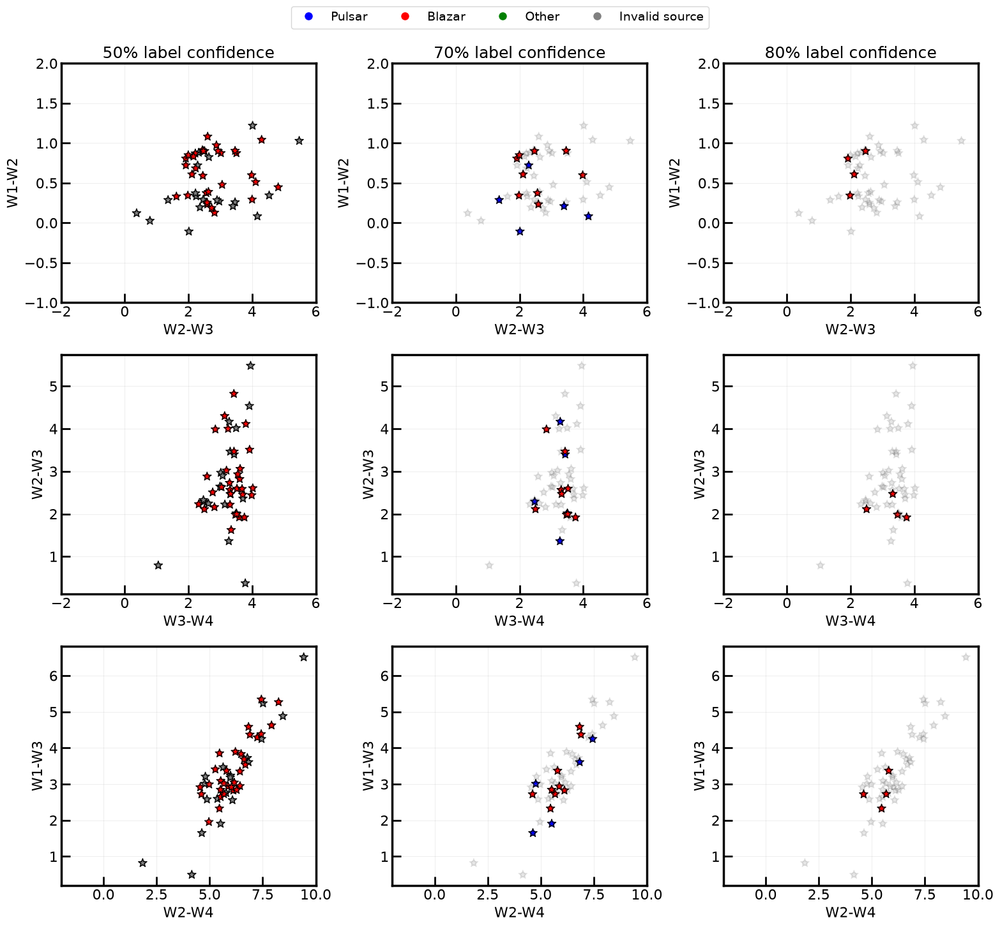

In [21]:
# HAVE TO REDO MY TOP MATCHES SINCE THEY COULDB E OVERLLAIPING ACROSS TOP PANY EVEN SHOULD BE THE TOP ONE PER FERMI ELLIPSE YOU DINGUS!

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D


thresholds = [0.5, 0.7, 0.8]

# (x-axis, y-axis, x-limits, y-limits)
color_color_plots = [
    (
        'WISE_W2_W3_color',
        'WISE_W1_W2_color',
        (-2, 6),
        (-1, 2)
    ),
    (
        'WISE_W3_W4_color',
        'WISE_W2_W3_color',
        (-2, 6),
        None
    ),
    (
        'WISE_W2_W4_color',
        'WISE_W1_W3_color',
        (-2, 10),
        None
    )
]


# ============================================================
# CLASSIFICATION COLORS
# ============================================================

cmap = ['red', 'green', 'blue', 'gray']

color_map = {
    'blazar': 0,
    'other': 1,
    'pulsar': 2
}

my_continuous_cmap = LinearSegmentedColormap.from_list(
    "my_gradient",
    cmap)

colors_thresholds = []
alphas_thresholds = []

colors_thresholds2 = []
alphas_thresholds2 = []

predicted_classes = sources_names_top_p_i_matches[
    'labels_3_top_class_pred'
]

for threshold in thresholds:

    colors = []
    alphas = []


    for source_idx, color_key in enumerate(predicted_classes):

        probability_column = (
            'labels_3_' + color_key + '_prob'
        )

        # IMPORTANT:
        # Astropy Table does NOT use .iloc
        probability = sources_names_top_p_i_matches[
            probability_column
        ][source_idx]

        if probability >= threshold:

            colors.append(color_map[color_key])

            if color_key == 'blazar':
                alphas.append(1.0)
            elif color_key == 'pulsar':
                alphas.append(1.0)
            elif color_key == 'other':
                alphas.append(0.1)
        else:
            colors.append(3)
            alphas.append(0.1)

    colors_thresholds.append(
        np.array(colors))

    alphas_thresholds.append(
        np.array(alphas))




fig, axs = plt.subplots(
    3,
    3,
    figsize=(16, 15)
)


# ============================================================
# LOOP THROUGH THE THREE COLOR-COLOR DIAGRAMS
# ============================================================

for row, (x_axis, y_axis, xlim, ylim) in enumerate(
    color_color_plots
):
    # split 
    first_color_y, second_color_y = y_axis.split('_')[1], y_axis.split('_')[2]

    first_color_x, second_color_x = x_axis.split('_')[1], x_axis.split('_')[2]

    # combine new label
    yaxis_title = first_color_y + '-' + second_color_y
    xaxis_title = first_color_x + '-' + second_color_x

    

    # Get data from Astropy Table
    x = np.asarray(
        sources_names_top_p_i_matches[x_axis],
        dtype=float)

    y = np.asarray(
        sources_names_top_p_i_matches[y_axis],
        dtype=float
    )
    source_names = np.array(sources_names_top_p_i_matches['Source_Name'])

 


        
    for col, threshold in enumerate(thresholds):
        ax = axs[row, col]
        ax.scatter(
            x,
            y,
            c=colors_thresholds[col],
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds[col],
            s=30
        )


        ax.set_xlim(
            xlim[0],
            xlim[1]
        )

        if ylim is not None:

            ax.set_ylim(
                ylim[0],
                ylim[1]
            )
        print(col)
        # for index, x_iter in enumerate(x) :
        #     if source_names[index] in sources_names_top_p_i_matches['Source_Name']:
        ax.scatter(
            x,
            y,
            c=colors_thresholds[col],
            edgecolor='black',
            cmap=my_continuous_cmap,
            alpha=alphas_thresholds[col],
            s=100,
            marker='*')
        

        if row == 0:
            ax.set_title(
                f'{threshold * 100:.0f}% label confidence',
                fontsize=18)
        ax.set_xlabel(
            xaxis_title,
            fontsize=16)

        ax.set_ylabel(
            yaxis_title,
            fontsize=16)
        ax.grid(
            True,
            alpha=0.2)


# ============================================================
# CUSTOM LEGEND
# ============================================================

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='blue',
        markersize=10,
        label='Pulsar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='red',
        markersize=10,
        label='Blazar'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='green',
        markersize=10,
        label='Other'),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='gray',
        markersize=10,
        label='Invalid source')
]


fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 0.980),
    fontsize=14
)




plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


output_filename = (
    'WISE_color_color_3x3_classification_confidence.png'
)

# fig.savefig(
#     output_filename,
#     dpi=300,
#     bbox_inches='tight'
# )





plt.show()

In [202]:
fermi_names = [
    b"4FGL J0041.3-0048",
    b"4FGL J0634.6-3046c",
    b"4FGL J1245.4-0701",
    b"4FGL J1334.8-3856",
    b"4FGL J0252.3-2707",
    b"4FGL J1959.8-1835",
    b"4FGL J0132.1-0956",
    b"4FGL J0443.3-5949",
    b"4FGL J0608.6-2305",
    b"4FGL J0821.0-0651",
    b"4FGL J0944.3-0911",
    b"4FGL J1322.0-4624",
    b"4FGL 1322.0-4624",
    b"4FGL J1620.9+0021",
    b"4FGL J2032.2-0545",
]

In [203]:
name_mask = np.isin(top_match_unassociated_sources['Source_Name'], fermi_names)

In [204]:
top_match_unassociated_sources[name_mask]

WISE,Separation_FERMI_WISE,Separation_max,ncat,dist_bayesfactor_uncorrected,dist_bayesfactor,dist_post,p_single,match_flag,prob_has_match,prob_this_match,Source_Name,DataRelease,RA,DEC,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FHL,TEVCAT_FLAG,CLASS1,ASSOC1,ASSOC_PROB_BAY,ASSOC_PROB_LR,Flags,Indexes,catalog_names,pos_err,ID,WISE_DataRelease,WISE_Conf_95_SemiMajor,WISE_Conf_95_SemiMinor,WISE_Conf_95_PosAng,WISE_ROI_num,WISE_Flags,WISE_Indexes,WISE_catalog_names,WISE_designation,WISE_RA,WISE_DEC,WISE_sigra,WISE_sigdec,WISE_sigradec,WISE_glon,WISE_glat,WISE_elon,WISE_elat,WISE_wx,WISE_wy,WISE_cntr,WISE_source_id,WISE_coadd_id,WISE_src,WISE_w1mpro,WISE_w1sigmpro,WISE_w1snr,WISE_w1rchi2,WISE_w2mpro,WISE_w2sigmpro,WISE_w2snr,WISE_w2rchi2,WISE_w3mpro,WISE_w3sigmpro,WISE_w3snr,WISE_w3rchi2,WISE_w4mpro,WISE_w4snr,WISE_w4rchi2,WISE_rchi2,WISE_nb,WISE_na,WISE_w1sat,WISE_w2sat,WISE_w3sat,WISE_w4sat,WISE_satnum,WISE_ra_pm,WISE_dec_pm,WISE_sigra_pm,WISE_sigdec_pm,WISE_sigradec_pm,WISE_pmra,WISE_sigpmra,WISE_pmdec,WISE_sigpmdec,WISE_w1rchi2_pm,WISE_w2rchi2_pm,WISE_w3rchi2_pm,WISE_w4rchi2_pm,WISE_rchi2_pm,WISE_pmcode,WISE_cc_flags,WISE_rel,WISE_ext_flg,WISE_ph_qual,WISE_det_bit,WISE_moon_lev,WISE_w1nm,WISE_w1m,WISE_w2nm,WISE_w2m,WISE_w3nm,WISE_w3m,WISE_w4nm,WISE_w4m,WISE_w1cov,WISE_w2cov,WISE_w3cov,WISE_w4cov,WISE_w1cc_map,WISE_w1cc_map_str,WISE_w2cc_map,WISE_w3cc_map,WISE_w4cc_map,WISE_use_src,WISE_best_use_cntr,WISE_ngrp,WISE_w1flux,WISE_w1sigflux,WISE_w1sky,WISE_w1sigsk,WISE_w1conf,WISE_w2flux,WISE_w2sigflux,WISE_w2sky,WISE_w2sigsk,WISE_w2conf,WISE_w3flux,WISE_w3sigflux,WISE_w3sky,WISE_w3sigsk,WISE_w3conf,WISE_w4flux,WISE_w4sigflux,WISE_w4sky,WISE_w4sigsk,WISE_w4conf,WISE_w1magp,WISE_w1sigp1,WISE_w1sigp2,WISE_w1k,WISE_w1ndf,WISE_w1mlq,WISE_w1mjdmin,WISE_w1mjdmax,WISE_w1mjdmean,WISE_w2magp,WISE_w2sigp1,WISE_w2sigp2,WISE_w2k,WISE_w2ndf,WISE_w2mlq,WISE_w2mjdmin,WISE_w2mjdmax,WISE_w2mjdmean,WISE_w3magp,WISE_w3sigp1,WISE_w3sigp2,WISE_w3k,WISE_w3ndf,WISE_w3mlq,WISE_w3mjdmin,WISE_w3mjdmax,WISE_w3mjdmean,WISE_w4magp,WISE_w4sigp1,WISE_w4sigp2,WISE_w4k,WISE_w4ndf,WISE_w4mlq,WISE_w4mjdmin,WISE_w4mjdmax,WISE_w4mjdmean,WISE_rho12,WISE_rho23,WISE_rho34,WISE_q12,WISE_q23,WISE_w4gflg,WISE_tmass_key,WISE_r_2mass,WISE_pa_2mass,WISE_n_2mass,WISE_j_m_2mass,WISE_j_msig_2mass,WISE_h_m_2mass,WISE_h_msig_2mass,WISE_k_m_2mass,WISE_k_msig_2mass,WISE_x,WISE_y,WISE_z,WISE_spt_ind,WISE_wise_ang_sep,WISE_WISE_flux,WISE_WISE_maj,WISE_radio_flux_name,WISE__catalog_base_name,WISE__ra_key,WISE__dec_key,WISE__maj_key,WISE__flux_key,WISE_pos_err,WISE_w4sigmpro,ASSOC_FGL,WISE_var_flg,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,RACS_low,VLASS,Separation_FERMI_RACS_low,Separation_FERMI_VLASS,Separation_RACS_low_WISE,Separation_RACS_low_VLASS,Separation_WISE_VLASS,bias_RACS_low_spectral_index,bias_RACS_low_FluxRatio,bias_RACS_low_total_flux,bias_VLASS_spectral_index,bias_VLASS_Ftot,bias_VLASS_FluxRatio,SBID,n_gauss,s_code,CompId,IslId,DupFlag,QualFlag,MainSample,RACS_low_src1_DataRelease,RACS_low_src1_RA,RACS_low_src1_DEC,RACS_low_src1_Conf_95_SemiMajor,RACS_low_src1_Conf_95_SemiMinor,RACS_low_src1_Conf_95_PosAng,RACS_low_src1_ROI_num,RACS_low_src1_Flags,RACS_low_src1_Indexes,RACS_low_src1_catalog_names,RACS_low_src1_source_name,RACS_low_src1_Source_ID,RACS_lo

### Err and Err adjaent 

#### distribution of the p_any matches 

#### prior_distribution

In [9]:
current_working_dir = os.getcwd()
current_working_dir = current_working_dir.removesuffix('code')


In [10]:

# current_working_dir = os.getcwd()
catalog_home_dir = current_working_dir + '/catalogs/'
catalog_reduced_dir = current_working_dir + '/reduced_catalogs/'
catalog_mals_all = current_working_dir + '/catalogs/mals_all_bands.fits'

In [11]:
# call the background sources
fermi_14yr_assoc_srcs_closest_path = catalog_reduced_dir+'14yr_associated_ellipses_all_srcs_gaia_wise.fits'
fermi_14yr_assoc_srcs_background_path = catalog_reduced_dir+'14yr_associated_ellipses_all_srcs_gaia_wise_background.fits'

fermi_14yr_assoc_srcs_closest_table = QTable.read(fermi_14yr_assoc_srcs_closest_path, format='fits')
fermi_14yr_assoc_srcs_background_table = Table.read(fermi_14yr_assoc_srcs_background_path, format='fits')

# all priors
radio_observables = ['RadioFluxRatio', 'FermiRadioFlux', 'RadioSpectralIndex']
wise_observable = ['ColorColor']



In [12]:
import numpy as np
from astropy.table import Table

# =====================================================================
# 1. LOAD FITS TABLES
# =====================================================================
# Load tables using Astropy's Table interface
hstack_table = fermi_14yr_assoc_srcs_closest_table
vstack_table = fermi_14yr_assoc_srcs_background_table

# Convert to Pandas DataFrames for flexible column filtering and row masks
hstack_df = hstack_table.to_pandas()
vstack_df = vstack_table.to_pandas()

# Identify Fermi positional/metadata columns at the beginning of the hstack
# (Adjust index slice 10 to match your exact number of Fermi metadata columns)
fermi_meta_cols = list(hstack_df.columns[:10]) 

# =====================================================================
# 2. SPLIT THE VSTACK FITS (BY CATALOG NAME)
# =====================================================================
print("--- Splitting VSTACK FITS (Match + Background Sources) ---")
vstack_splits = {}

# Decode bytes to strings if your FITS catalog columns loaded as byte types
if vstack_df['catalog_names'].dtype == object:
    vstack_df['catalog_names'] = vstack_df['catalog_names'].str.decode('utf-8').fillna(vstack_df['catalog_names'])

unique_catalogs = vstack_df['catalog_names'].dropna().unique()

for cat in unique_catalogs:
    # Filter rows belonging to this catalog
    cat_mask = vstack_df['catalog_names'] == cat
    filtered_df = vstack_df[cat_mask].copy()
    
    # Drop columns that are completely empty (all NaNs) for this catalog
    filtered_df = filtered_df.dropna(axis=1, how='all')
    
    # Convert back to a clean Astropy Table object
    vstack_splits[cat] = Table.from_pandas(filtered_df)
    print(f"Catalog [{cat}] VSTACK split: {len(vstack_splits[cat])} rows")


# =====================================================================
# 3. SPLIT THE HSTACK FITS (BY PROPERTY PREFIX/SUFFIX)
# =====================================================================
print("\n--- Splitting HSTACK FITS (True Matches Only) ---")
hstack_splits = {}

for cat in unique_catalogs:
    # Safely convert to string for text matching
    cat_str = str(cat)
    
    # Gather columns belonging to this catalog by matching string text
    cat_specific_cols = [col for col in hstack_df.columns if cat_str.lower() in col.lower()]
    
    if len(cat_specific_cols) == 0:
        print(f"Warning: No columns matched text '{cat_str}' in hstack columns. Skipping prefix split.")
        continue
        
    # Isolate Fermi base metadata plus specific instrument metrics
    keep_cols = fermi_meta_cols + cat_specific_cols
    filtered_df = hstack_df[keep_cols].copy()
    
    # Remove rows where this specific catalog did not yield data
    filtered_df = filtered_df.dropna(subset=cat_specific_cols, how='all')
    
    # Convert back to a clean Astropy Table object
    hstack_splits[cat] = Table.from_pandas(filtered_df)
    print(f"Catalog [{cat}] HSTACK split: {len(hstack_splits[cat])} rows")


--- Splitting VSTACK FITS (Match + Background Sources) ---
Catalog [FERMI] VSTACK split: 4635 rows
Catalog [MALS_L] VSTACK split: 6014 rows
Catalog [VLASS] VSTACK split: 2939 rows
Catalog [FIRST] VSTACK split: 2553 rows
Catalog [RACS_low] VSTACK split: 41 rows
Catalog [TGSS] VSTACK split: 6 rows
Catalog [NVSS] VSTACK split: 352 rows
Catalog [SUMSS] VSTACK split: 289 rows
Catalog [WISE] VSTACK split: 2608156 rows

--- Splitting HSTACK FITS (True Matches Only) ---
Catalog [MALS_L] HSTACK split: 268 rows
Catalog [VLASS] HSTACK split: 1146 rows
Catalog [FIRST] HSTACK split: 1146 rows
Catalog [RACS_low] HSTACK split: 34 rows
Catalog [TGSS] HSTACK split: 6 rows
Catalog [NVSS] HSTACK split: 1244 rows
Catalog [SUMSS] HSTACK split: 98 rows
Catalog [WISE] HSTACK split: 4557 rows


In [6]:
# mals: FluxTotal, FluxRadioRatio, SPXIDX, FermiRadioFluxRatio
columns = ['total_flux', 'FluxRatio', 'spectral_index']

# vlass:  FluxTotal, FluxRadioRatio, SPXIDX, FermiRadioFluxRatio
columns = ['Ftot', 'FluxRatio', 'spectral_index']

# first:  FluxTotal, FluxRadioRatio, SPXIDX, FermiRadioFluxRatio
columns = ['FINT', 'FluxRatio', 'spectral_index', ]

# nvss:  FluxTotal, FluxRadioRatio, SPXIDX, FermiRadioFluxRatio
columns = ['S1.4', 'spectral_index']

# tgss:  FluxTotal, FluxRadioRatio, SPXIDX, FermiRadioFluxRatio
columns = ['Total_flux', 'FluxRatio', 'spectral_index',]

# racs:  FluxTotal, FluxRadioRatio, SPXIDX, FermiRadioFluxRatio
columns = ['total_flux', 'FluxRatio', 'spectral_index',]

'/lustre/aoc/observers/nm-16041/antonio/USSCataloging/catalogs/'

In [ ]:
# point of thisis to show the souces align with the priors (and worst ones dont?)
# is this useful inmy paper?)=
# I should do p_low as the lowest match source not the worst of the best p_any like whats the point of that?

survey_columns = {
'MALS_L': ['total_flux', 'FluxRatio', 'spectral_index'],
'VLASS': ['Ftot', 'FluxRatio', 'spectral_index'],
'FIRST': ['FINT', 'FluxRatio', 'spectral_index'],
'RACS_low': ['S1.4', 'spectral_index'],
'TGSS': ['Total_flux', 'FluxRatio', 'spectral_index'],
'NVSS': ['total_flux', 'FluxRatio', 'spectral_index']}
# technically not correct? should it just be the actual matches? so vstack
def prior_plotter(prior, catalog_name):
    survey_columns = {
    'MALS_L': ['total_flux', 'FluxRatio', 'spectral_index'],
    'VLASS': ['Ftot', 'FluxRatio', 'spectral_index'],
    'FIRST': ['FINT', 'FluxRatio', 'spectral_index'],
    'RACS_low': ['S1.4', 'spectral_index'],
    'TGSS': ['Total_flux', 'FluxRatio', 'spectral_index'],
    'NVSS': ['total_flux', 'FluxRatio', 'spectral_index']}
    match prior:
        case 'FluxTotal':
            background = vstack_splits[catalog_name][survey_columns[catalog_name][0]]
            return background

        case 'FluxRadioRatio':
            background = vstack_splits[catalog_name][survey_columns[catalog_name][1]]
            return background

        case 'SPXIDX':
            try:
                background = vstack_splits[catalog_name][survey_columns[catalog_name][2]]
            except:
                pass
        case _:
            background = 'N/A'
            


fig, axs =plt.subplots(1,3, figsize=(11,6))
                  
# total_flux      
for name in survey_columns.keys():
    prior = 'Flux_total'

    background = prior_plotter(prior, name)
    print(background)
    if background == 'N/A':
        continue
    axs[0].hist(background, color ='gray', alpha=0.6)
p_low
# axs[0].hist(top_matches_unassoc_table['F)
# # p_high
# axs[0].hist(p_any_high_unassoc)


# flux_ratio
for name in catalogs:
    prior = 'FluxRadioRatio'
    background = prior_plotter(prior, name)
    if background == 'N/A':
        continue
    axs[1].hist(background, color ='gray', alpha=0.6)
# # p_low
# axs[1].hist(p_any_low_unassoc)
# # p_high
# axs[1].hist(p_any_high_unassoc)


# spx_idx
for name in catalogs:
    prior = 'SPXIDX'
    background = prior_plotter(prior, name)
    if background == 'N/A':
        continue
    axs[2].hist(background, color ='gray', alpha=0.6)
# # p_low
# axs[2].hist(p_any_low_unassoc)
# # p_high
# axs[2].hist(p_any_high_unassoc)


In [ ]:
top_matches_unassoc_table

In [ ]:
# plt the high and low probability matches as a distributiona their p_any values!
# this would be a bar chart instead?
fig = plt.figure(figsize=12, 6)
plt.hist(top_matches_unassoc_table['p_has_match'], color = ASTROCOLOR[0], label = 'top p_any matches')
plt.hist(top_matches_unassoc_table['p_has_match'], color = ASTROCOLOR[0], label = 'top p_any matches')



In [ ]:
# 
fig = plt.figure(figsize=12, 6)
plt.hist(top_matches_unassoc_table['p_has_match'], color = ASTROCOLOR[0], label = 'top p_any matches')
plt.hist(top_matches_unassoc_table['p_has_match'], color = ASTROCOLOR[0], label = 'top p_any matches')

In [ ]:
# full range of the complete selection of our catlaog that is stacked
fig = plt.figure(figsize=14, 6)
plt.hist(all_matches_unassoc_table['p_has_match'] , color= ASTROCOLOR[0], label = 'all unassoc sources')

In [ ]:
# remake the assoc training plot to be the ternary and then on the right have the hist of correct and incorrect matches? optional